In [1]:
#1 ── Ячейка 1: Импорты ─────────────────────────────────────────
import os, logging, importlib.util
import numpy as np
import pandas as pd
import databento as db

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)-8s  %(message)s',
    datefmt='%H:%M:%S')
log = logging.getLogger('amt')

PATH_NQ_ES = './data/GLBX-20260603-XBMUUNEJJQ 16yr nq es data/glbx-mdp3-20100606-20260602.ohlcv-1m.dbn'
CACHE_DIR  = './cache'
CLASSIFY   = './amt_classify.py'
os.makedirs(CACHE_DIR, exist_ok=True)
log.info('OK')

16:27:20  INFO      OK


In [2]:
#2 ── VIX загрузка ──────────────────────────────────────────
import databento as db

VIX_CACHE = os.path.join(CACHE_DIR, 'vix_daily.parquet')

if os.path.exists(VIX_CACHE):
    vix = pd.read_parquet(VIX_CACHE)
    log.info('VIX загружен из кеша: %d дней', len(vix))
else:
    from fredapi import Fred
    fred = Fred(api_key='YOUR_FRED_API_KEY')
    vix_series = fred.get_series('VIXCLS', 
                                  observation_start='2010-01-01',
                                  observation_end='2026-06-01')
    vix = vix_series.to_frame('vix_close')
    vix.index = pd.to_datetime(vix.index)
    vix = vix.dropna()
    
    def vix_regime(v):
        if v < 15:   return 'low'
        if v < 25:   return 'normal'
        return 'high'
    
    vix['vix_regime'] = vix['vix_close'].apply(vix_regime)
    vix.to_parquet(VIX_CACHE)
    log.info('VIX построен через FRED: %d дней', len(vix))

log.info('VIX режимы:\n%s', vix['vix_regime'].value_counts().to_string())

# Три режима
def vix_regime(v):
    if v < 15:   return 'low'
    if v < 25:   return 'normal'
    return 'high'

vix['vix_regime'] = vix['vix_close'].apply(vix_regime)
log.info('VIX режимы:\n%s', vix['vix_regime'].value_counts().to_string())

16:27:20  INFO      VIX загружен из кеша: 4157 дней
16:27:20  INFO      VIX режимы:
vix_regime
normal    2147
low       1449
high       561
16:27:20  INFO      VIX режимы:
vix_regime
normal    2147
low       1449
high       561


In [3]:
#3 ── Макро данные: ZT, ZN, CL, DX ─────────────────────────
MACRO_PATHS = {
    'zn': './data/GLBX-20260604-YY86KWTSMD 10yr/glbx-mdp3-20100606-20260605.ohlcv-1d.dbn',
    'zt': './data/GLBX-20260606-BTSF5RNAY9 zt 2yr/glbx-mdp3-20100606-20260605.ohlcv-1d.dbn',
    'cl': './data/GLBX-20260606-EWECGEANF7 cl/glbx-mdp3-20100606-20260605.ohlcv-1d.dbn',
    'dx': './data/IFUS-20260606-3B38JP5FG8 2 dx 2018/ifus-impact-20181223-20260605.ohlcv-1d.dbn',
}

def load_macro(name, path, symbol_filter=None, cache_dir=CACHE_DIR):
    cache = os.path.join(cache_dir, f'{name}_daily.parquet')
    if os.path.exists(cache):
        df = pd.read_parquet(cache)
        log.info('%s загружен из кеша: %d дней', name.upper(), len(df))
        return df
    store = db.DBNStore.from_file(path)
    df    = store.to_df()
    df.index = pd.to_datetime(df.index).tz_localize(None)

    # Фильтруем только чистые контракты без спредов
    if symbol_filter:
        df = df[df['symbol'].str.startswith(symbol_filter) &
                ~df['symbol'].str.contains('-')].copy()

    df['date'] = df.index.date
    if 'symbol' in df.columns and df['symbol'].nunique() > 1:
        daily_vol   = df.groupby(['date', 'symbol'])['volume'].sum()
        front       = daily_vol.groupby('date').idxmax().apply(lambda x: x[1])
        df['front'] = df['date'].map(front)
        df          = df[df['symbol'] == df['front']]

    daily = df.groupby('date').agg(
        open=('open', 'first'), high=('high', 'max'),
        low=('low', 'min'),     close=('close', 'last'),
        volume=('volume', 'sum')
    )
    daily.index = pd.to_datetime(daily.index)
    daily.to_parquet(cache)
    log.info('%s построен: %d дней', name.upper(), len(daily))
    return daily

zn = load_macro('zn', MACRO_PATHS['zn'], symbol_filter='ZN')
zt = load_macro('zt', MACRO_PATHS['zt'],        symbol_filter='ZT')
cl = load_macro('cl', MACRO_PATHS['cl'],        symbol_filter='CL')
dx = load_macro('dx', MACRO_PATHS['dx'])

# DX до 2018 добиваем через FRED
DX_FRED_CACHE = os.path.join(CACHE_DIR, 'dx_fred.parquet')
if not os.path.exists(DX_FRED_CACHE):
    from fredapi import Fred
    fred     = Fred(api_key='YOUR_FRED_API_KEY')
    dx_fred  = fred.get_series('DTWEXBGS', observation_start='2010-01-01',
                                observation_end='2018-12-22').to_frame('close')
    dx_fred.index = pd.to_datetime(dx_fred.index)
    dx_fred.to_parquet(DX_FRED_CACHE)
    log.info('DX FRED загружен: %d дней', len(dx_fred))
else:
    dx_fred = pd.read_parquet(DX_FRED_CACHE)

# Объединяем DX: FRED 2010-2018 + Databento 2018-2026
dx_full = pd.concat([
    dx_fred[['close']].rename(columns={'close': 'close'}),
    dx[['close']]
]).sort_index()
dx_full = dx_full[~dx_full.index.duplicated(keep='last')]

# Yield curve slope: ZN 10Y - ZT 2Y (в базисных пунктах)
zn_close = zn['close'].rename('zn_close')
zt_close = zt['close'].rename('zt_close')
cl_close = cl['close'].rename('cl_close')
dx_close = dx_full['close'].rename('dx_close')

macro = pd.concat([zn_close, zt_close, cl_close, dx_close], axis=1)
macro['yield_slope'] = macro['zn_close'] - macro['zt_close']
macro['cl_ret']      = macro['cl_close'].pct_change()
macro['dx_ret']      = macro['dx_close'].pct_change()

# Режимы
macro['yield_regime'] = pd.cut(macro['yield_slope'],
    bins=[-999, 0, 1.0, 999],
    labels=['inverted', 'flat', 'normal'])

macro['cl_regime'] = pd.cut(macro['cl_close'],
    bins=[0, 50, 80, 999],
    labels=['low', 'normal', 'high'])

macro['dx_regime'] = pd.cut(macro['dx_close'],
    bins=[0, 95, 105, 999],
    labels=['weak', 'neutral', 'strong'])

log.info('Macro готов: %d дней\n%s',
    len(macro),
    macro[['yield_slope','yield_regime','cl_regime','dx_regime']].tail(5).to_string())

16:27:21  INFO      ZN загружен из кеша: 4968 дней
16:27:21  INFO      ZT загружен из кеша: 4968 дней
16:27:21  INFO      CL загружен из кеша: 4967 дней
16:27:21  INFO      DX загружен из кеша: 2305 дней
/var/folders/3v/smgxjmwd4sd1yrfyqrw28s940000gp/T/ipykernel_13457/1149009046.py:74: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  macro['cl_ret']      = macro['cl_close'].pct_change()
/var/folders/3v/smgxjmwd4sd1yrfyqrw28s940000gp/T/ipykernel_13457/1149009046.py:75: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  macro['dx_ret']      = macro['dx_close'].pct_change()
16:27:21  INFO      Macro готов:

In [4]:
#4 ── Ячейка 2: Загрузка данных (с кешем) ───────────────────────
ES_CONT = os.path.join(CACHE_DIR, 'es_continuous.parquet')
NQ_CONT = os.path.join(CACHE_DIR, 'nq_continuous.parquet')

if os.path.exists(ES_CONT) and os.path.exists(NQ_CONT):
    es_continuous = pd.read_parquet(ES_CONT)
    nq_continuous = pd.read_parquet(NQ_CONT)
    log.info('Continuous загружены из кеша  ES %s  NQ %s баров',
             f'{len(es_continuous):,}', f'{len(nq_continuous):,}')
else:
    store = db.DBNStore.from_file(PATH_NQ_ES)
    df    = store.to_df()
    df.index = df.index.tz_localize(None)
    log.info('DBN загружен: %s строк', f'{len(df):,}')

    front_symbols = [s for s in df['symbol'].unique() if '-' not in s]
    df_clean = df[df['symbol'].isin(front_symbols)].copy()
    es = df_clean[df_clean['symbol'].str.startswith('ES')].copy()
    nq = df_clean[df_clean['symbol'].str.startswith('NQ')].copy()

    def get_front_contract(data):
        data = data.copy()
        data['date'] = data.index.date
        daily_vol    = data.groupby(['date', 'symbol'])['volume'].sum()
        return daily_vol.groupby('date').idxmax().apply(lambda x: x[1])

    def build_continuous(data, front_contracts):
        data          = data.copy()
        data['date']  = data.index.date
        data['front'] = data['date'].map(front_contracts)
        return data[data['symbol'] == data['front']].drop(
            columns=['date', 'front']).sort_index()

    es_continuous = build_continuous(es, get_front_contract(es))
    nq_continuous = build_continuous(nq, get_front_contract(nq))
    es_continuous.to_parquet(ES_CONT)
    nq_continuous.to_parquet(NQ_CONT)
    log.info('Continuous сохранены в кеш')

log.info('ES %s → %s  NQ %s → %s',
         es_continuous.index[0].date(), es_continuous.index[-1].date(),
         nq_continuous.index[0].date(), nq_continuous.index[-1].date())

16:27:21  INFO      Continuous загружены из кеша  ES 5,586,072  NQ 5,414,367 баров
16:27:21  INFO      ES 2010-06-06 → 2026-06-02  NQ 2010-06-06 → 2026-06-02


In [5]:
#5 ── Ячейка 3: RTH фильтр (14:30 - 21:00 UTC) ──────────────────
RTH_START = 14 * 60 + 30   # 870
RTH_END   = 21 * 60 + 0    # 1260

def get_rth(data):
    t = data.index.hour * 60 + data.index.minute
    return data[(t >= RTH_START) & (t < RTH_END)].copy()

es_rth = get_rth(es_continuous)
nq_rth = get_rth(nq_continuous)
log.info('ES RTH: %s баров  NQ RTH: %s баров',
         f'{len(es_rth):,}', f'{len(nq_rth):,}')

16:27:21  INFO      ES RTH: 1,544,264 баров  NQ RTH: 1,541,888 баров


In [6]:
#6 ── Ячейка 4: Загрузка amt_classify ───────────────────────────
spec = importlib.util.spec_from_file_location('amt_classify', CLASSIFY)
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
log.info('amt_classify загружен')

16:27:22  INFO      amt_classify загружен


amt_classify OK


In [7]:
#7 ── Ячейка 5: Value Area база (с кешем) ───────────────────────
ES_VA = os.path.join(CACHE_DIR, 'es_va.parquet')
NQ_VA = os.path.join(CACHE_DIR, 'nq_va.parquet')

if os.path.exists(ES_VA) and os.path.exists(NQ_VA):
    es_va = pd.read_parquet(ES_VA)
    nq_va = pd.read_parquet(NQ_VA)
    log.info('VA база загружена из кеша  ES %d  NQ %d дней',
             len(es_va), len(nq_va))
else:
    es_va = mod.build_va_database(es_rth)
    nq_va = mod.build_va_database(nq_rth)
    for va, path in [(es_va, ES_VA), (nq_va, NQ_VA)]:
        save = va.copy()
        save['hvn_levels'] = save['hvn_levels'].apply(str)
        save['lvn_levels'] = save['lvn_levels'].apply(str)
        save.to_parquet(path)
    log.info('VA база построена  ES %d  NQ %d дней',
             len(es_va), len(nq_va))

log.info('Пример ES VA:\n%s',
         es_va[['poc','vah','val','day_high','day_low']].head(3).to_string())

16:27:22  INFO      VA база загружена из кеша  ES 4106  NQ 4106 дней
16:27:22  INFO      Пример ES VA:
                poc      vah     val  day_high  day_low
date                                                   
2010-06-07  1060.50  1068.25  1054.5   1068.75  1047.00
2010-06-08  1052.00  1056.00  1044.0   1063.25  1041.25
2010-06-09  1054.75  1071.50  1052.0   1077.75  1051.25


In [8]:
#8
def prep_va(va_db):
    va = va_db.copy()
    for col in ['hvn_levels', 'lvn_levels']:
        if col not in va.columns:
            va[col] = [[] for _ in range(len(va))]
            continue
        va[col] = va[col].apply(
            lambda x: x if isinstance(x, list) else
            [] if str(x) in ('[]', 'nan', '') else
            [float(v) for v in str(x).strip('[]').split(',') if v.strip()])
    return va

In [9]:
#9 Считаем intraday_rv заранее и передаём в classify_days
irv_es = mod.calc_intraday_rv(es_rth, window=20)
irv_nq = mod.calc_intraday_rv(nq_rth, window=20)

# Строим словарь date -> irv для быстрого доступа
irv_es_dict = {d.date(): v for d, v in irv_es.items() if not np.isnan(v)}
irv_nq_dict = {d.date(): v for d, v in irv_nq.items() if not np.isnan(v)}
log.info('IRV ES: %.4f → %.4f', min(irv_es_dict.values()), max(irv_es_dict.values()))

# Затем classify
es_days = mod.classify_days(es_rth, prep_va(es_va), irv_dict=irv_es_dict)
nq_days = mod.classify_days(nq_rth, prep_va(nq_va), irv_dict=irv_nq_dict)



16:27:22  INFO      IRV ES: 0.0024 → 0.0364


In [ ]:
#10 ── Ячейка 6: Классификация дней (с кешем) ────────────────────
ES_DAYS = os.path.join(CACHE_DIR, 'es_days.parquet')
NQ_DAYS = os.path.join(CACHE_DIR, 'nq_days.parquet')

def prep_va(va_db):
    """Восстанавливает hvn/lvn списки из parquet (строки или уже списки)."""
    va = va_db.copy()
    for col in ['hvn_levels', 'lvn_levels']:
        if col not in va.columns:
            va[col] = [[] for _ in range(len(va))]
            continue
        va[col] = va[col].apply(
            lambda x: x if isinstance(x, list) else
            [] if str(x) in ('[]', 'nan', '') else
            [float(v) for v in str(x).strip('[]').split(',') if v.strip()])
    return va

REQUIRED_COLS = {'bimodality'}  # маркеры свежего классификатора
_cache_ok = os.path.exists(ES_DAYS) and os.path.exists(NQ_DAYS)
if _cache_ok:
    es_days = pd.read_parquet(ES_DAYS)
    nq_days = pd.read_parquet(NQ_DAYS)
    _missing = REQUIRED_COLS - set(es_days.columns)
    if _missing:
        _cache_ok = False
        log.info('Кеш устарел (нет %s) — пересчёт классификации', _missing)

if _cache_ok:
    log.info('Days загружены из кеша  ES %d  NQ %d', len(es_days), len(nq_days))
else:
    es_days = mod.classify_days(es_rth, prep_va(es_va), irv_dict=irv_es_dict)
    nq_days = mod.classify_days(nq_rth, prep_va(nq_va), irv_dict=irv_nq_dict)
    es_days.to_parquet(ES_DAYS)
    nq_days.to_parquet(NQ_DAYS)
    log.info('Days построены  ES %d  NQ %d', len(es_days), len(nq_days))

log.info('Колонки: %s', list(es_days.columns))

In [11]:
#11 ── Ячейка 7: RV-20 + Volume Z-score + IB/RV ratio ────────────
def add_normalizations(days_df, rth_data):
    rth         = rth_data.copy()
    rth['date'] = rth.index.date
    daily_close = rth.groupby('date')['close'].last()
    daily_vol   = rth.groupby('date')['volume'].sum()
    daily_close.index = pd.to_datetime(daily_close.index)
    daily_vol.index   = pd.to_datetime(daily_vol.index)

    log_ret  = np.log(daily_close / daily_close.shift(1))
    rv20     = log_ret.rolling(20).std() * np.sqrt(252)
    vol_mean = daily_vol.rolling(60).mean()
    vol_std  = daily_vol.rolling(60).std()
    vol_z    = (daily_vol - vol_mean) / vol_std.replace(0, np.nan)

    df = days_df.copy()
    df.index = pd.to_datetime(df.index)
    df['rv20']        = rv20.reindex(df.index)
    df['vol_zscore']  = vol_z.reindex(df.index)
    df['ib_pct']      = df['ib_range'] / df['open_px']
    df['ib_rv_ratio'] = df['ib_pct'] / (df['rv20'] / np.sqrt(252))
    df['ib_size']     = pd.qcut(
        df['ib_rv_ratio'].dropna(),
        q=3, labels=['narrow', 'normal', 'wide'], duplicates='drop')
    return df

es_days = add_normalizations(es_days, es_rth)
nq_days = add_normalizations(nq_days, nq_rth)

log.info('ES  RV20: %.3f → %.3f  Vol-Z: %.2f → %.2f',
         es_days['rv20'].min(), es_days['rv20'].max(),
         es_days['vol_zscore'].min(), es_days['vol_zscore'].max())

16:35:49  INFO      ES  RV20: 0.031 → 0.954  Vol-Z: -3.68 → 5.12


In [12]:
#12 ── Ячейка 8: Сохранение финального датасета ──────────────────
es_days.to_parquet(ES_DAYS)
nq_days.to_parquet(NQ_DAYS)
log.info('Сохранено: es_days  nq_days  (%d колонок)', len(es_days.columns))

16:35:49  INFO      Сохранено: es_days  nq_days  (53 колонок)


In [13]:
#13 ── Ячейка 9: Статистика ──────────────────────────────────────
df = es_days.dropna(subset=['rv20']).copy()

log.info('Условия открытия:\n%s',
    df['open_location'].value_counts(normalize=True)
      .mul(100).round(1).to_string())

log.info('Типы дня:\n%s',
    df['day_type'].value_counts(normalize=True)
      .mul(100).round(1).to_string())

log.info('Типы открытия:\n%s',
    df['open_type'].value_counts(normalize=True)
      .mul(100).round(1).to_string())

log.info('Activity:\n%s',
    df['activity'].value_counts(normalize=True)
      .mul(100).round(1).to_string())

log.info('Тип дня по условию открытия:\n%s',
    df.groupby('open_location')['day_type']
      .value_counts(normalize=True).mul(100).round(1)
      .unstack(fill_value=0).to_string())

log.info('Activity по условию открытия:\n%s',
    df.groupby('open_location')['activity']
      .value_counts(normalize=True).mul(100).round(1)
      .unstack(fill_value=0).to_string())

df['direction_correct'] = (
    ((df['direction'] == 'long')  & (df['close_px'] > df['open_px'])) |
    ((df['direction'] == 'short') & (df['close_px'] < df['open_px']))
)
log.info('Win rate направления:\n%s',
    df.groupby('open_location')['direction_correct']
      .agg(win_rate=lambda x: round(x.mean()*100, 1), count='count')
      .to_string())

log.info('POC acceptance rate:\n%s',
    df.groupby('open_location')['poc_accepted']
      .agg(acceptance_rate=lambda x: round(x.mean()*100, 1), count='count')
      .to_string())

log.info('IB size distribution:\n%s',
    df['ib_size'].value_counts().to_string())

log.info('Тип дня по IB size:\n%s',
    df.groupby('ib_size')['day_type']
      .value_counts(normalize=True).mul(100).round(1)
      .unstack(fill_value=0).to_string())

16:35:49  INFO      Условия открытия:
open_location
outside_range_above     25.8
inside_va_above_poc     18.7
outside_range_below     17.1
inside_va_below_poc     16.4
outside_va_below_poc    11.0
outside_va_above_poc    11.0
16:35:49  INFO      Типы дня:
day_type
normal_variation       41.8
double_distribution    39.8
neutral                14.9
normal                  1.8
trend                   1.3
nontrend                0.4
16:35:49  INFO      Типы открытия:
open_type
open_rejection_reverse    33.3
open_auction              28.6
open_test_drive           25.9
open_drive                12.2
16:35:49  INFO      Activity:
activity
initiative_buying     31.4
responsive_buying     23.6
initiative_selling    22.6
responsive_selling    22.4
16:35:49  INFO      Тип дня по условию открытия:
day_type              double_distribution  neutral  nontrend  normal  normal_variation  trend
open_location                                                                                
inside_va_abov

In [14]:
#14 Посмотреть реальные числа для нескольких известных дней
sample = es_days[['ib_range', 'day_range', 'ib_profile_ratio',
                   'ib_width_cat', 'profile_width_cat', 
                   'ib_profile_cat', 'day_type']].head(20)
print(sample.to_string())

# Распределение ib_profile_ratio
print(es_days['ib_profile_ratio'].describe())
print(es_days['ib_profile_ratio'].quantile([0.1, 0.25, 0.5, 0.75, 0.9]))

            ib_range  day_range  ib_profile_ratio ib_width_cat profile_width_cat ib_profile_cat             day_type
date                                                                                                                
2010-06-08     11.50      22.00             0.523         wide              wide         medium  double_distribution
2010-06-09     14.25      26.50             0.538         wide              wide         medium  double_distribution
2010-06-10      4.50      16.00             0.281        small            medium            low  double_distribution
2010-06-11      9.50      13.50             0.704         wide            medium           high  double_distribution
2010-06-14      7.75      17.50             0.443       medium            medium         medium  double_distribution
2010-06-15      4.00      16.50             0.242        small            medium            low  double_distribution
2010-06-16      8.25      12.25             0.673       medium  

In [15]:
#64 ── LSE Economic Calendar ─────────────────────────────────
import requests
import time

LSE_API_KEY = 'YOUR_LSE_API_KEY'# уже в ноутбуке
LSE_BASE    = 'https://api.londonstrategicedge.com/iso'

def lse_get(table, params):
    params['is_stale'] = 'is.false'
    r = requests.get(
        f'{LSE_BASE}/{table}',
        headers={'x-api-key': LSE_API_KEY},
        params=params,
        timeout=30
    )
    r.raise_for_status()
    return r.json()

# Тянем US high-impact события с 2010
HIGH_IMPACT_EVENTS = [
    '*nonfarm*', '*payroll*',
    '*cpi*', '*consumer price*',
    '*interest rate*', '*fed funds*', '*fomc*',
    '*gdp*', '*gross domestic*',
    '*pce*', '*personal consumption*',
    '*ppi*', '*producer price*',
    '*ism*', '*purchasing managers*',
    '*retail sales*',
    '*unemployment*', '*jobless*',
]

all_events = []
for pattern in HIGH_IMPACT_EVENTS:
    offset = 0
    while True:
        rows = lse_get('economic_calender', {
            'region_code': 'eq.US',
            'event':       f'ilike.{pattern}',
            'datetime':    'gte.2010-01-01',
            'actual':      'not.is.null',
            'select':      'datetime,event,actual,consensus,previous,period_hint',
            'order':       'datetime.asc',
            'limit':       '5000',
            'offset':      str(offset),
        })
        if not rows:
            break
        all_events.extend(rows)
        log.info('Pattern %s: +%d rows (total %d)', pattern, len(rows), len(all_events))
        if len(rows) < 5000:
            break
        offset += 5000
        time.sleep(0.3)

cal_df = pd.DataFrame(all_events)
cal_df['datetime'] = pd.to_datetime(cal_df['datetime'], utc=True).dt.tz_localize(None)
cal_df['date']     = cal_df['datetime'].dt.date
cal_df             = cal_df.drop_duplicates(subset=['datetime', 'event'])
log.info('Economic calendar: %d событий', len(cal_df))
log.info('Уникальные события:\n%s', cal_df['event'].value_counts().head(30).to_string())

16:35:50  INFO      Pattern *nonfarm*: +227 rows (total 227)
16:35:50  INFO      Pattern *payroll*: +546 rows (total 773)
16:35:51  INFO      Pattern *cpi*: +116 rows (total 889)
16:35:51  INFO      Pattern *interest rate*: +179 rows (total 1068)
16:35:52  INFO      Pattern *fomc*: +1 rows (total 1069)
16:35:52  INFO      Pattern *gdp*: +347 rows (total 1416)
16:35:53  INFO      Pattern *gross domestic*: +5 rows (total 1421)
16:35:53  INFO      Pattern *pce*: +818 rows (total 2239)
16:35:53  INFO      Pattern *ppi*: +625 rows (total 2864)
16:35:53  INFO      Pattern *producer price*: +15 rows (total 2879)
16:35:54  INFO      Pattern *ism*: +1616 rows (total 4495)
16:35:54  INFO      Pattern *retail sales*: +486 rows (total 4981)
16:35:55  INFO      Pattern *unemployment*: +171 rows (total 5152)
16:35:55  INFO      Pattern *jobless*: +1520 rows (total 6672)
16:35:55  INFO      Economic calendar: 6536 событий
16:35:55  INFO      Уникальные события:
event
Fed Interest Rate Decision       

In [16]:
#65 ── Surprise Factor + Флаги ───────────────────────────────
import re

def parse_numeric(val):
    if pd.isna(val) or val == '' or val is None:
        return np.nan
    try:
        return float(str(val).replace('%','').replace('K','e3')
                              .replace('M','e6').replace('B','e9')
                              .replace(',','').strip())
    except:
        return np.nan
    
KEY_EVENTS = ['NFP', 'CPI', 'FOMC', 'GDP', 'GDP_Deflator', 'PCE', 
              'Core_PCE', 'Retail_Sales', 'ISM_Mfg']

cal_df['actual_num']    = cal_df['actual'].apply(parse_numeric)
cal_df['consensus_num'] = cal_df['consensus'].apply(parse_numeric)
cal_df['previous_num']  = cal_df['previous'].apply(parse_numeric)

# Surprise = actual - consensus
cal_df['surprise'] = cal_df['actual_num'] - cal_df['consensus_num']

# Группируем по типу события для нормализации
def normalize_event_name(name):
    name = str(name).lower()
    # Сначала специфичные — потом общие
    if 'nonfarm payrolls private' in name:     return 'NFP_Private'
    if 'nonfarm payroll' in name or 'non farm payroll' in name:
        if 'manufacturing' not in name and 'government' not in name:
            return 'NFP'
    if 'core cpi' in name:                     return 'Core_CPI'
    if 'cpi' in name:                          return 'CPI'
    if 'core ppi' in name:                     return 'Core_PPI'
    if 'ppi' in name:                          return 'PPI'
    if 'interest rate decision' in name:       return 'FOMC'
    if 'gdp growth rate' in name:              return 'GDP'
    if 'gdp price index' in name:              return 'GDP_Deflator'
    if 'core pce' in name:                     return 'Core_PCE'
    if 'pce' in name:                          return 'PCE'
    if 'retail sales ex autos' in name:        return 'Retail_Sales_ExAuto'
    if 'retail sales' in name:                 return 'Retail_Sales'
    if 'initial jobless' in name:              return 'Jobless_Claims'
    if 'ism manufacturing' in name:            return 'ISM_Mfg'
    if 'ism services' in name or 'ism non-mfg' in name: return 'ISM_Services'
    return None

cal_df['event_type'] = cal_df['event'].apply(normalize_event_name)
cal_clean = cal_df[cal_df['event_type'].notna()].copy()

log.info('События по типам:\n%s',
         cal_clean['event_type'].value_counts().to_string())

# Нормализованный surprise по историческому std
surprise_stats = (cal_clean.groupby('event_type')['surprise']
                  .agg(['mean','std','count'])
                  .round(3))
log.info('Surprise статистика по типам:\n%s', surprise_stats.to_string())

cal_clean['surprise_z'] = cal_clean.groupby('event_type')['surprise'].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
)

# Направление surprise
cal_clean['surprise_dir'] = np.sign(cal_clean['surprise_z'])

# Дата события
cal_clean['event_date'] = pd.to_datetime(cal_clean['datetime'].dt.date)

# ── Добавляем флаги в es_days ─────────────────────────────
es_days['event_day']    = False
es_days['event_before'] = False
es_days['event_after']  = False
es_days['event_type']   = None
es_days['surprise_z']   = np.nan
es_days['surprise_dir'] = np.nan

for _, row in cal_clean.iterrows():
    ed = row['event_date']
    # День события
    if ed in es_days.index:
        es_days.loc[ed, 'event_day']    = True
        es_days.loc[ed, 'event_type']   = row['event_type']
        es_days.loc[ed, 'surprise_z']   = row['surprise_z']
        es_days.loc[ed, 'surprise_dir'] = row['surprise_dir']

    # День до
    idx = es_days.index.get_loc(ed) if ed in es_days.index else None
    if idx is not None and idx > 0:
        es_days.iloc[idx-1, es_days.columns.get_loc('event_before')] = True

    # День после
    if idx is not None and idx < len(es_days) - 1:
        es_days.iloc[idx+1, es_days.columns.get_loc('event_after')] = True

log.info('Event days:   %d', es_days['event_day'].sum())
log.info('Before days:  %d', es_days['event_before'].sum())
log.info('After days:   %d', es_days['event_after'].sum())

# ── Win rate по событиям × open_location × GMM ───────────
event_wr = (es_days[es_days['event_day']]
            .groupby(['event_type', 'open_location'])
            .apply(lambda x: pd.Series({
                'win_rate': (x['close_px'] > x['open_px']).mean() * 100,
                'count': len(x)
            }), include_groups=False)
            .query('count >= 10')
            .sort_values('win_rate', ascending=False))

log.info('Win rate в день события:\n%s', event_wr.head(20).to_string())

# Surprise direction × win rate
surp_wr = (es_days[es_days['event_day'] & es_days['surprise_z'].notna()]
           .groupby(['event_type', 'surprise_dir'])
           .apply(lambda x: pd.Series({
               'win_rate': (x['close_px'] > x['open_px']).mean() * 100,
               'count': len(x)
           }), include_groups=False)
           .query('count >= 5')
           .sort_values('win_rate', ascending=False))

log.info('Win rate по surprise direction:\n%s', surp_wr.to_string())

# До/после события
for flag, label in [('event_before', 'День ДО'), ('event_after', 'День ПОСЛЕ')]:
    wr = (es_days[es_days[flag]]
          .groupby('open_location')
          .apply(lambda x: pd.Series({
              'win_rate': (x['close_px'] > x['open_px']).mean() * 100,
              'count': len(x)
          }), include_groups=False)
          .sort_values('win_rate', ascending=False))
    log.info('%s:\n%s', label, wr.to_string())

# Приоритет событий — важные не перезаписываются менее важными
EVENT_PRIORITY = {
    'NFP': 1, 'CPI': 2, 'Core_CPI': 3, 'FOMC': 4,
    'GDP': 5, 'PCE': 6, 'Core_PCE': 7, 'PPI': 8,
    'Core_PPI': 9, 'Retail_Sales': 10, 'ISM_Mfg': 11,
    'ISM_Services': 12, 'GDP_Deflator': 13,
    'Jobless_Claims': 14, 'NFP_Private': 15,
    'Retail_Sales_ExAuto': 16,
}

# Берём одно событие в день — с наивысшим приоритетом
cal_daily = (cal_clean
    .assign(priority=cal_clean['event_type'].map(EVENT_PRIORITY))
    .dropna(subset=['priority'])
    .sort_values('priority')
    .groupby('event_date')
    .first()
    .reset_index())

log.info('Уникальных дней с событиями: %d', len(cal_daily))
log.info('Распределение:\n%s', cal_daily['event_type'].value_counts().to_string())

# Перезаписываем флаги
es_days['event_day']    = False
es_days['event_before'] = False
es_days['event_after']  = False
es_days['event_type']   = None
es_days['surprise_z']   = np.nan
es_days['surprise_dir'] = np.nan

for _, row in cal_daily.iterrows():
    ed = row['event_date']
    if ed in es_days.index:
        es_days.loc[ed, 'event_day']    = True
        es_days.loc[ed, 'event_type']   = row['event_type']
        es_days.loc[ed, 'surprise_z']   = row['surprise_z']
        es_days.loc[ed, 'surprise_dir'] = row['surprise_dir']

    idx = es_days.index.get_loc(ed) if ed in es_days.index else None
    if idx is not None and idx > 0:
        es_days.iloc[idx-1, es_days.columns.get_loc('event_before')] = True
    if idx is not None and idx < len(es_days) - 1:
        es_days.iloc[idx+1, es_days.columns.get_loc('event_after')] = True

# Пересчитываем macro features
es_days['surprise_z_filled'] = es_days['surprise_z'].fillna(0)
for col in ['event_day', 'event_before', 'event_after']:
    es_days[col] = es_days[col].astype(int)

for evt in KEY_EVENTS:
    col = f'event_{evt.lower()}'
    es_days[col] = (
        (es_days['event_day'] == 1) &
        (es_days['event_type'] == evt)
    ).astype(int)

log.info('Распределение по типам в es_days:\n%s',
         es_days[[f'event_{e.lower()}' for e in KEY_EVENTS]].sum().to_string())

16:35:55  INFO      События по типам:
event_type
Jobless_Claims         598
ISM_Mfg                547
Core_PCE               409
PCE                    409
PPI                    352
Retail_Sales           348
Core_PPI               273
ISM_Services           195
NFP                    138
Retail_Sales_ExAuto    138
NFP_Private            136
GDP_Deflator           136
GDP                    136
CPI                    113
FOMC                    93
Core_CPI                 3
16:35:55  INFO      Surprise статистика по типам:
                           mean         std  count
event_type                                        
CPI                       0.054       0.402    105
Core_CPI                    NaN         NaN      0
Core_PCE                 -0.002       0.161    390
Core_PPI                  0.003       0.294    271
FOMC                      0.000       0.037     91
GDP                       0.001       0.569    136
GDP_Deflator              0.022       0.477    134
ISM_Mfg   

In [17]:
#66
gdp_clean = cal_clean[cal_clean['event_type'] == 'GDP']
log.info('GDP даты: %s', gdp_clean['event_date'].head(10).tolist())
log.info('ES days index sample: %s', es_days.index[:5].tolist())
log.info('GDP dates in es_days: %d/%d',
         gdp_clean['event_date'].isin(es_days.index).sum(),
         len(gdp_clean))

16:35:56  INFO      GDP даты: [Timestamp('2015-01-30 00:00:00'), Timestamp('2015-02-27 00:00:00'), Timestamp('2015-03-27 00:00:00'), Timestamp('2015-04-29 00:00:00'), Timestamp('2015-05-29 00:00:00'), Timestamp('2015-06-24 00:00:00'), Timestamp('2015-07-30 00:00:00'), Timestamp('2015-08-27 00:00:00'), Timestamp('2015-09-25 00:00:00'), Timestamp('2015-10-29 00:00:00')]
16:35:56  INFO      ES days index sample: [Timestamp('2010-06-08 00:00:00'), Timestamp('2010-06-09 00:00:00'), Timestamp('2010-06-10 00:00:00'), Timestamp('2010-06-11 00:00:00'), Timestamp('2010-06-14 00:00:00')]
16:35:56  INFO      GDP dates in es_days: 135/136


In [18]:
#67 ── Подготовка macro features для GMM ────────────────────

# surprise_z заполняем нулём в не-событийные дни
# (нет события = нет сюрприза = нейтрально)
es_days['surprise_z_filled'] = es_days['surprise_z'].fillna(0)

# Добавляем бинарные флаги по типам событий
KEY_EVENTS = ['NFP', 'CPI', 'FOMC', 'GDP', 'GDP_Deflator', 'PCE', 
              'Core_PCE', 'Retail_Sales', 'ISM_Mfg']

for evt in KEY_EVENTS:
    col = f'event_{evt.lower()}'
    es_days[col] = (
        es_days['event_day'] & 
        (es_days['event_type'] == evt)
    ).astype(int)

# Новые macro features
MACRO_FEATURES = [
    'surprise_z_filled',
    'event_day',
    'event_before', 
    'event_after',
] + [f'event_{e.lower()}' for e in KEY_EVENTS]

# Конвертируем bool в int
for col in ['event_day', 'event_before', 'event_after']:
    es_days[col] = es_days[col].astype(int)

# Проверяем
log.info('Macro features добавлены:')
log.info('event_day: %d дней', es_days['event_day'].sum())
log.info('surprise_z_filled: mean=%.3f std=%.3f nonzero=%d',
         es_days['surprise_z_filled'].mean(),
         es_days['surprise_z_filled'].std(),
         (es_days['surprise_z_filled'] != 0).sum())
log.info('Распределение по типам событий:\n%s',
         es_days[[f'event_{e.lower()}' for e in KEY_EVENTS]].sum().to_string())

16:35:56  INFO      Macro features добавлены:
16:35:56  INFO      event_day: 1280 дней
16:35:56  INFO      surprise_z_filled: mean=0.007 std=0.515 nonzero=1186
16:35:56  INFO      Распределение по типам событий:
event_nfp             133
event_cpi              67
event_fomc             90
event_gdp             130
event_gdp_deflator      0
event_pce             119
event_core_pce          0
event_retail_sales    100
event_ism_mfg         107


In [19]:
#17 ── GMM: кластеризация дней ────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

# Пересчитываем ib_norm и prof_norm
irv_series = pd.Series(irv_es_dict)
irv_series.index = pd.to_datetime(irv_series.index)
es_days['irv']       = irv_series.reindex(es_days.index)
es_days['ib_norm']   = es_days['ib_range']  / (es_days['irv'] * es_days['open_px'])
es_days['prof_norm'] = es_days['day_range'] / (es_days['irv'] * es_days['open_px'])

# Джойним VIX и macro к es_days
es_days = es_days.drop(columns=['vix_close', 'vix_regime',
                                 'yield_slope', 'yield_regime',
                                 'cl_close', 'cl_regime',
                                 'dx_close', 'dx_regime'], errors='ignore')

es_days = es_days.join(vix[['vix_close', 'vix_regime']], how='left')
es_days = es_days.join(
    macro[['yield_slope', 'yield_regime', 'cl_close', 'cl_regime', 
           'dx_close', 'dx_regime']], how='left')

# Выравниваем индекс es_days
es_days.index = pd.to_datetime(es_days.index).astype('datetime64[ns]')

# ES log returns
es_close = es_rth.groupby(es_rth.index.date)['close'].last()
es_close.index = pd.to_datetime(es_close.index).astype('datetime64[ns]')
es_close.index.name = None
log_ret = np.log(es_close / es_close.shift(1))

es_days['vix_close']    = es_days['vix_close'].ffill()
es_days['vix_regime']   = es_days['vix_regime'].fillna('low')
es_days['yield_slope']  = es_days['yield_slope'].ffill()
es_days['yield_regime'] = es_days['yield_regime'].fillna('normal')
es_days['cl_regime']    = es_days['cl_regime'].fillna('normal')
es_days['dx_regime']    = es_days['dx_regime'].fillna('neutral')

# Garman-Klass volatility (заменяет Parkinson)
es_high  = es_rth.groupby(es_rth.index.date)['high'].max()
es_low   = es_rth.groupby(es_rth.index.date)['low'].min()
es_open  = es_rth.groupby(es_rth.index.date)['open'].first()
es_close_daily = es_rth.groupby(es_rth.index.date)['close'].last()

for s in [es_high, es_low, es_open, es_close_daily]:
    s.index = pd.to_datetime(s.index).astype('datetime64[ns]')

gk = (0.5 * np.log(es_high / es_low)**2 -
      (2*np.log(2) - 1) * np.log(es_close_daily / es_open)**2)

gk_vol_20 = np.sqrt(gk.rolling(20).mean() * 252)
gk_vol_5  = np.sqrt(gk.rolling(5).mean()  * 252)

# Hurst exponent (rolling 100 дней)
def rolling_hurst(series, window=100, max_lag=20):
    def calc_hurst(data):
        if np.isnan(data).any():
            return np.nan
        lags = range(2, max_lag)
        tau = [np.std(np.subtract(data[lag:], data[:-lag])) for lag in lags]
        if any(t == 0 for t in tau):
            return np.nan
        try:
            poly = np.polyfit(np.log(list(lags)), np.log(tau), 1)
            return poly[0]
        except:
            return np.nan
    return series.rolling(window).apply(calc_hurst, raw=True)

es_days['hurst_100d'] = rolling_hurst(
    es_close.reindex(es_days.index), window=100)

# Efficiency Ratio (ER)
def efficiency_ratio(series, window=20):
    direction = abs(series - series.shift(window))
    volatility = series.diff().abs().rolling(window).sum()
    return direction / volatility.replace(0, np.nan)

es_days['er_20d'] = efficiency_ratio(es_close.reindex(es_days.index), 20)
es_days['er_10d'] = efficiency_ratio(es_close.reindex(es_days.index), 10)

# R² линейного тренда
def rolling_r2(series, window=20):
    def calc_r2(y):
        if len(y) < window or np.isnan(y).any():
            return np.nan
        x = np.arange(len(y))
        corr = np.corrcoef(x, y)[0, 1]
        return corr ** 2
    return series.rolling(window).apply(calc_r2, raw=True)

es_days['trend_r2_20d'] = rolling_r2(es_close.reindex(es_days.index), 20)

# Lag-1 автокорреляция (mean-reversion vs momentum)
es_days['autocorr_lag1_20d'] = log_ret.rolling(20).apply(
    lambda x: pd.Series(x).autocorr(lag=1), raw=False
).reindex(es_days.index)

# Price-Volume корреляция
es_vol = es_rth.groupby(es_rth.index.date)['volume'].sum()
es_vol.index = pd.to_datetime(es_vol.index).astype('datetime64[ns]')
es_vol.index.name = None
vol_ret = es_vol.pct_change()

vol_aligned, log_ret_aligned_pv = vol_ret.align(log_ret, join='inner')
es_days['pv_corr_20d'] = vol_aligned.rolling(20).corr(
    log_ret_aligned_pv).reindex(es_days.index)

# Calendar features
idx = pd.to_datetime(es_days.index)
es_days['day_of_week']    = idx.dayofweek
es_days['month']          = idx.month
es_days['quarter']        = idx.quarter
es_days['is_month_end']   = idx.is_month_end.astype(int)
es_days['is_quarter_end'] = idx.is_quarter_end.astype(int)

# GK Volatility
es_days['gk_vol_20d']     = gk_vol_20.reindex(es_days.index)
es_days['vol_ratio_5_20'] = (gk_vol_5 / gk_vol_20).reindex(es_days.index)
es_days['vol_of_vol_20d'] = gk_vol_20.rolling(20).std().reindex(es_days.index)

# Regime change
es_days['vix_change_5d']          = vix['vix_close'].pct_change(5).reindex(es_days.index)
es_days['vix_percentile_252d']    = vix['vix_close'].rolling(252).rank(pct=True).reindex(es_days.index)
es_days['yield_slope_change_10d'] = macro['yield_slope'].diff(10).reindex(es_days.index)

# ZN momentum
es_days['zn_mom_10d'] = zn['close'].pct_change(10).reindex(es_days.index)
es_days['zn_mom_20d'] = zn['close'].pct_change(20).reindex(es_days.index)

# ES range percentile
daily_range = es_days['day_range'] / es_days['open_px']
es_days['range_pct_20d'] = np.log(daily_range.rolling(20).rank(pct=True).clip(0.01, 0.99))

# NQ log returns
nq_close = nq_rth.groupby(nq_rth.index.date)['close'].last()
nq_close.index = pd.to_datetime(nq_close.index).astype('datetime64[ns]')
nq_close.index.name = None
nq_ret = np.log(nq_close / nq_close.shift(1))

# ZN/CL log returns
zn_ret = np.log(zn['close'] / zn['close'].shift(1))
zn_ret.index = pd.to_datetime(zn_ret.index).astype('datetime64[ns]')
zn_ret.index.name = None

cl_ret = np.log(cl['close'] / cl['close'].shift(1))
cl_ret.index = pd.to_datetime(cl_ret.index).astype('datetime64[ns]')
cl_ret.index.name = None

# Align по общим датам
zn_aligned, es_aligned_zn = zn_ret.align(log_ret, join='inner')
cl_aligned, es_aligned_cl = cl_ret.align(log_ret, join='inner')
nq_aligned, es_aligned_nq = nq_ret.align(log_ret, join='inner')

es_days['zn_es_corr_20d'] = zn_aligned.rolling(20).corr(es_aligned_zn).reindex(es_days.index)
es_days['cl_es_corr_20d'] = cl_aligned.rolling(20).corr(es_aligned_cl).reindex(es_days.index)
es_days['es_nq_corr_20d'] = nq_aligned.rolling(20).corr(es_aligned_nq).reindex(es_days.index)

# Skewness и kurtosis
es_days['ret_skew_20d'] = log_ret.rolling(20).skew().reindex(es_days.index)
es_days['ret_kurt_20d'] = log_ret.rolling(20).kurt().reindex(es_days.index)

# Features с VIX
GMM_FEATURES = [
    'ib_norm', 'prof_norm', 'ib_profile_ratio',
    'poc_bias', 'open_poc_dist',
    'vix_close', 'vix_percentile_252d', 'vix_change_5d',
    'yield_slope', 'yield_slope_change_10d',
    'cl_close', 'dx_close',
    'zn_mom_10d', 'zn_mom_20d',
    'range_pct_20d',
    'day_of_week', 'month',
    'cl_es_corr_20d', 'es_nq_corr_20d',
    'zn_es_corr_20d', 'gk_vol_20d',
    'vol_ratio_5_20', 'vol_of_vol_20d',
    'ret_skew_20d', 'ret_kurt_20d',
    'hurst_100d', 'autocorr_lag1_20d',
    'pv_corr_20d'
]

gmm_df = es_days[GMM_FEATURES].dropna().copy()
log.info('GMM: %d дней, %d features', len(gmm_df), len(GMM_FEATURES))

# Стандартизация
scaler = RobustScaler()
X_scaled = scaler.fit_transform(gmm_df)

# Подбор n_components по BIC
bic_scores = []
n_range    = range(3, 15)
for n in n_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full',
                      random_state=42, n_init=5,
                      reg_covar=1e-6)
    gmm.fit(X_scaled)
    bic_scores.append((n, gmm.bic(X_scaled)))
    log.info('GMM n=%d  BIC=%.1f', n, bic_scores[-1][1])

# Оптимальное n
best_n = 13
log.info('Оптимальное n_components: %d', best_n)

# Финальная модель
gmm_final = GaussianMixture(n_components=best_n, covariance_type='full',
                             random_state=42, n_init=10,
                             reg_covar=1e-6)
gmm_final.fit(X_scaled)

# Присваиваем кластеры и posterior probabilities
gmm_df['gmm_cluster']  = gmm_final.predict(X_scaled)
proba = gmm_final.predict_proba(X_scaled)
for k in range(best_n):
    gmm_df[f'gmm_prob_{k}'] = proba[:, k]

# Удаляем старые GMM колонки если есть
old_cols = [c for c in es_days.columns if c.startswith('gmm_')]
es_days  = es_days.drop(columns=old_cols, errors='ignore')

# Добавляем новые
es_days = es_days.join(
    gmm_df[['gmm_cluster'] + [f'gmm_prob_{k}' for k in range(best_n)]],
    how='left')

# Смотрим как кластеры соотносятся с AMT классификацией
log.info('Кластеры vs day_type:\n%s',
    es_days.groupby('gmm_cluster')['day_type']
           .value_counts(normalize=True).mul(100).round(1)
           .unstack(fill_value=0).to_string())

log.info('Средние features по кластерам:\n%s',
    es_days.groupby('gmm_cluster')[GMM_FEATURES].mean().round(3).to_string())

log.info('Средние features по кластерам:\n%s',
    es_days.groupby('gmm_cluster')[GMM_FEATURES]
           .mean().round(3).T.to_string())



16:35:58  INFO      GMM: 3849 дней, 28 features
16:35:59  INFO      GMM n=3  BIC=183676.4
16:35:59  INFO      GMM n=4  BIC=179492.7
16:35:59  INFO      GMM n=5  BIC=176875.1
16:36:00  INFO      GMM n=6  BIC=176519.4
16:36:00  INFO      GMM n=7  BIC=175969.7
16:36:01  INFO      GMM n=8  BIC=175891.3
16:36:01  INFO      GMM n=9  BIC=176673.3
16:36:02  INFO      GMM n=10  BIC=176493.0
16:36:03  INFO      GMM n=11  BIC=176692.0
16:36:04  INFO      GMM n=12  BIC=177130.2
16:36:05  INFO      GMM n=13  BIC=178983.6
16:36:06  INFO      GMM n=14  BIC=178618.0
16:36:06  INFO      Оптимальное n_components: 13
16:36:09  INFO      Кластеры vs day_type:
day_type     double_distribution  neutral  nontrend  normal  normal_variation  trend
gmm_cluster                                                                         
0.0                         32.2     17.3       1.0     2.5              45.0    2.0
1.0                         40.5     15.7       0.9     0.9              41.2    0.7
2.0         

In [73]:
# ═══════════════════════════════════════════════════════════════════════
# НОВАЯ АРХИТЕКТУРА · L0 — Causal stationary feature set (regime engine)
# ═══════════════════════════════════════════════════════════════════════
# Анализ старого #17: сырые уровни cl_close/dx_close/vix_close нестационарны
# (кластеры кодируют эпоху, а не состояние рынка); day_of_week/month как
# непрерывные фичи некорректны; er_10d/trend_r2 считались зря; best_n=13 был
# захардкожен мимо BIC. Здесь — только стационарные, декоррелированные фичи.

# Стационарные замены уровням (импульсы вместо цен)
es_days['cl_mom_20d'] = macro['cl_close'].pct_change(20, fill_method=None).reindex(es_days.index)
es_days['dx_mom_20d'] = macro['dx_close'].pct_change(20, fill_method=None).reindex(es_days.index)

REGIME_FEATURES = [
    # — Market profile (нормированные на IRV, стационарные)
    'ib_norm', 'prof_norm', 'ib_profile_ratio', 'poc_bias', 'open_poc_dist',
    # — Волатильность (относительная, не абсолютный уровень)
    'vix_percentile_252d', 'vix_change_5d', 'vol_ratio_5_20',
    # — Ставки / интермаркет (спред, изменение, импульсы)
    'yield_slope', 'yield_slope_change_10d',
    'zn_mom_10d', 'cl_mom_20d', 'dx_mom_20d',
    # — Структура: тренд vs mean-reversion
    'er_20d', 'autocorr_lag1_20d',
    # — Кросс-корреляции с интермаркетом
    'cl_es_corr_20d', 'zn_es_corr_20d',
    # — Распределение доходностей + диапазон
    'ret_skew_20d', 'range_pct_20d',
]
# Исключены vs старый набор: cl_close, dx_close, vix_close (уровни),
# day_of_week, month (календарь), zn_mom_20d/es_nq_corr/ret_kurt/hurst/
# trend_r2/gk_vol_20d/vol_of_vol (дубли/шум). Список — правится под тезис.

_complete = es_days[REGIME_FEATURES].dropna()
log.info('L0: %d признаков, полных строк %d из %d (%.0f%%)',
         len(REGIME_FEATURES), len(_complete), len(es_days),
         100*len(_complete)/len(es_days))

17:47:58  INFO      L0: 19 признаков, полных строк 3349 из 4105 (82%)


In [74]:
# ═══════════════════════════════════════════════════════════════════════
# НОВАЯ АРХИТЕКТУРА · L1 — Regime engine (expanding, без lookahead)
# ═══════════════════════════════════════════════════════════════════════
# Чистые функции: fit на train-окне → predict на test; каноникализация
# компонент к эталонным центроидам (Hungarian), чтобы «смысл» режима был
# стабилен между окнами. diag-ковариация = меньше параметров, устойчивее.
from scipy.optimize import linear_sum_assignment
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler

N_REGIMES     = 7            # было 13; стабильно на expanding-окне с diag-cov
COV_TYPE      = 'diag'
DISCOVERY_END = '2019-01-01' # граница discovery/holdout

def fit_regime_model(train_df, features=REGIME_FEATURES, k=N_REGIMES, seed=42, n_init=10):
    """RobustScaler + GMM на train-окне (только прошлое)."""
    X = train_df[features].dropna()
    scaler = RobustScaler().fit(X)
    gmm = GaussianMixture(n_components=k, covariance_type=COV_TYPE,
                          random_state=seed, n_init=n_init, reg_covar=1e-6)
    gmm.fit(scaler.transform(X))
    return scaler, gmm

def _centroids(scaler, gmm):
    """Центроиды компонент обратно в исходном фич-пространстве (для матчинга)."""
    return scaler.inverse_transform(gmm.means_)

def build_reference(discovery_df, features=REGIME_FEATURES, k=N_REGIMES):
    """Эталонные центроиды режимов — фиксируем смысл один раз на discovery."""
    scaler, gmm = fit_regime_model(discovery_df, features, k)
    return _centroids(scaler, gmm)

def canonical_map(scaler, gmm, ref_centroids):
    """comp_id -> canonical regime: венгерский матчинг по расстоянию центроидов."""
    C   = _centroids(scaler, gmm)
    std = ref_centroids.std(axis=0) + 1e-9
    D   = np.linalg.norm((C[:, None, :] - ref_centroids[None, :, :]) / std, axis=2)
    rows, cols = linear_sum_assignment(D)
    return {int(r): int(c) for r, c in zip(rows, cols)}

def assign_regimes(df, scaler, gmm, cmap, features=REGIME_FEATURES):
    """Возвращает (regime, confidence) по строкам df с полными фичами."""
    X     = df[features]
    valid = X.dropna().index
    Z     = scaler.transform(X.loc[valid])
    comp  = gmm.predict(Z)
    regime = pd.Series(np.nan, index=df.index, name='regime')
    conf   = pd.Series(np.nan, index=df.index, name='regime_confidence')
    regime.loc[valid] = [cmap[int(c)] for c in comp]
    conf.loc[valid]   = gmm.predict_proba(Z).max(axis=1)
    return regime, conf

# Эталонные центроиды на discovery (<2019) — единое каноническое label-space
REF_CENTROIDS = build_reference(es_days[es_days.index < DISCOVERY_END])
log.info('L1: эталон %d режимов на discovery (<%s), cov=%s',
         N_REGIMES, DISCOVERY_END, COV_TYPE)

17:48:01  INFO      L1: эталон 7 режимов на discovery (<2019-01-01), cov=diag


In [75]:
# ═══════════════════════════════════════════════════════════════════════
# НОВАЯ АРХИТЕКТУРА · L1b — Session-shape слой (форма завершённой сессии)
# ═══════════════════════════════════════════════════════════════════════
# Заменяет хэндмейд day_type/fuzzy: форма дня m открывается через GMM-кластер.
# Все фичи — на ЗАВЕРШЁННОМ дне m (при next-day входе lookahead нет), лаг на m+1
# делается в L2. Тот же движок L1 (expanding fit + каноникализация).

def causal_pctrank(s, w=30):
    """Перцентиль-ранг последнего значения в трейлинг-окне (causal, [0..1])."""
    return s.rolling(w).apply(lambda a: (a[-1] >= a).mean(), raw=True)

# x1,x2 — causal 30d перцентиль ширины IB и профиля (нормированных на IRV)
es_days['x1_ibw'] = causal_pctrank(es_days['ib_norm'],   30)
es_days['x2_prw'] = causal_pctrank(es_days['prof_norm'], 30)
# x5 — позиция POC в диапазоне дня (0=low, 1=high)
_rng = (es_days['day_high'] - es_days['day_low']).replace(0, np.nan)
es_days['poc_position'] = ((es_days['curr_poc'] - es_days['day_low']) / _rng).clip(0, 1)
# signed conviction: смещение close от open в единицах ожидаемого дневного хода
es_days['session_thrust'] = (es_days['close_px'] - es_days['open_px']) / (es_days['irv'] * es_days['open_px'])

SHAPE_FEATURES = [
    'x1_ibw',            # ширина IB (30d causal перцентиль)
    'x2_prw',            # ширина профиля (30d causal перцентиль)
    'ib_profile_ratio',  # x3: IB / day range
    'open_poc_dist',     # x4: |open - POC| / range
    'poc_position',      # x5: положение POC в диапазоне
    'bimodality',        # x6: бимодальность профиля (из amt_classify)
    'session_thrust',    # signed conviction (close-open)/(irv*open)
]
N_SHAPES = 6   # discovered формы сессии (вместо 6 хэндмейд day_type)

_sh = es_days[SHAPE_FEATURES].dropna()
log.info('L1b: %d shape-фич, полных строк %d из %d (%.0f%%)',
         len(SHAPE_FEATURES), len(_sh), len(es_days), 100*len(_sh)/len(es_days))

# Эталонные центроиды форм на discovery (<2019) — стабильное label-space форм
REF_CENTROIDS_SHAPE = build_reference(
    es_days[es_days.index < DISCOVERY_END], features=SHAPE_FEATURES, k=N_SHAPES)
log.info('L1b: эталон %d форм сессии на discovery (<%s)', N_SHAPES, DISCOVERY_END)

17:48:04  INFO      L1b: 7 shape-фич, полных строк 4058 из 4105 (99%)
17:48:04  INFO      L1b: эталон 6 форм сессии на discovery (<2019-01-01)


In [76]:
# ═══════════════════════════════════════════════════════════════════════
# НОВАЯ АРХИТЕКТУРА · L2 — Expanding walk-forward → OOS-леджер
# ═══════════════════════════════════════════════════════════════════════
# По месяцам: fit regime+shape на [start…m-1] → assign m (только прошлое).
# next-day: дескрипторы дня t-1 → торгуем день t; таргет = open(t)→close(t).
# Весь период становится OOS по построению.
WARMUP_MONTHS = 24
WF_NINIT      = 4    # n_init в WF (refit каждый месяц) — компромисс скорость/стабильность

_months     = pd.period_range(es_days.index.min(), es_days.index.max(), freq='M')
_first_test = es_days.index.min() + pd.DateOffset(months=WARMUP_MONTHS)
_blocks = []
for per in _months:
    m0 = per.to_timestamp(); m1 = (per + 1).to_timestamp()
    if m0 < _first_test:
        continue
    train = es_days[es_days.index < m0]
    test  = es_days[(es_days.index >= m0) & (es_days.index < m1)]
    if len(test) == 0 or len(train) < 252:
        continue
    # regime
    sc_r, gmm_r = fit_regime_model(train, REGIME_FEATURES, N_REGIMES, n_init=WF_NINIT)
    reg, regc = assign_regimes(test, sc_r, gmm_r,
                    canonical_map(sc_r, gmm_r, REF_CENTROIDS), REGIME_FEATURES)
    # shape
    sc_s, gmm_s = fit_regime_model(train, SHAPE_FEATURES, N_SHAPES, n_init=WF_NINIT)
    shp, shpc = assign_regimes(test, sc_s, gmm_s,
                    canonical_map(sc_s, gmm_s, REF_CENTROIDS_SHAPE), SHAPE_FEATURES)
    _blocks.append(pd.DataFrame(
        {'regime': reg, 'regime_conf': regc, 'shape': shp, 'shape_conf': shpc},
        index=test.index))

wf = pd.concat(_blocks).sort_index()
wf = wf.join(es_days[['open_px', 'close_px', 'open_location', 'direction']])

# next-day лаг: торгуем день t по дескрипторам завершённого дня t-1
wf['regime_prev']      = wf['regime'].shift(1)
wf['shape_prev']       = wf['shape'].shift(1)
wf['regime_conf_prev'] = wf['regime_conf'].shift(1)
wf['shape_conf_prev']  = wf['shape_conf'].shift(1)
# таргет дня t (open→close); open_location(t) — open-known, остаётся текущим
wf['fwd_ret'] = (wf['close_px'] - wf['open_px']) / wf['open_px']
wf['win']     = wf['fwd_ret'] > 0
wf = wf.dropna(subset=['regime_prev', 'shape_prev', 'fwd_ret'])

log.info('L2 OOS-леджер: %d дней  %s … %s', len(wf),
         wf.index.min().date(), wf.index.max().date())
log.info('Режимы (prev) распределение:\n%s',
         wf['regime_prev'].astype(int).value_counts().sort_index().to_string())
log.info('Формы (prev) распределение:\n%s',
         wf['shape_prev'].astype(int).value_counts().sort_index().to_string())
log.info('Overall: WR=%.1f%%  avg_ret=%.3f%%  n=%d',
         wf['win'].mean()*100, wf['fwd_ret'].mean()*100, len(wf))

17:48:24  INFO      L2 OOS-леджер: 3068 дней  2012-07-03 … 2026-06-02
17:48:24  INFO      Режимы (prev) распределение:
regime_prev
0    432
1    677
2    581
3    492
4    224
5    412
6    250
17:48:24  INFO      Формы (prev) распределение:
shape_prev
0    341
1    677
2    345
3    859
4    466
5    380
17:48:24  INFO      Overall: WR=55.6%  avg_ret=0.020%  n=3068


In [80]:
# ═══════════════════════════════════════════════════════════════════════
# НОВАЯ АРХИТЕКТУРА · L3 — Оценка эджа (выборка-первична)
# ═══════════════════════════════════════════════════════════════════════
# Три теста ячейки ПРОТИВ остального пула, FDR по каждому:
#   p_t  — Welch t-test (среднее; чувствителен к хвостам)
#   p_mw — Mann-Whitney (ранговый; робастен к хвостам → больше мощности)
#   p_wr — two-proportion z (направленный WR vs baseline)
# Ранжируем по p_mw. min_n отсекает микровыборки.
from scipy import stats
from scipy.stats import norm

def wilson_lb(k, n, z=1.96):
    if n == 0: return 0.0
    p = k / n
    denom = 1 + z*z/n
    centre = p + z*z/(2*n)
    margin = z * np.sqrt(p*(1-p)/n + z*z/(4*n*n))
    return (centre - margin) / denom

def bh_fdr(pvals):
    p = np.asarray(pvals, float); n = len(p)
    order = np.argsort(p); q = np.empty(n); prev = 1.0
    for rank, idx in enumerate(order[::-1]):
        r = n - rank
        prev = min(prev, p[idx] * n / r); q[idx] = prev
    return q

def two_prop_p(k1, n1, k2, n2):
    if n1 == 0 or n2 == 0: return 1.0
    pp = (k1 + k2) / (n1 + n2)
    se = np.sqrt(pp*(1-pp)*(1/n1 + 1/n2))
    if se == 0: return 1.0
    return 2 * (1 - norm.cdf(abs((k1/n1 - k2/n2) / se)))

MIN_N = 40
Q_THRESH = 0.10
POOL_MEAN = wf['fwd_ret'].mean()
POOL_WR   = wf['win'].mean()
POOL_WINS = int(wf['win'].sum())
POOL_N    = len(wf)

def _cell_rows(by):
    rows = []
    for key, g in wf.groupby(by):
        n = len(g)
        if n < MIN_N: continue
        k    = int(g['win'].sum())
        rest = wf['fwd_ret'].drop(g.index)
        _, p_t  = stats.ttest_ind(g['fwd_ret'], rest, equal_var=False)
        _, p_mw = stats.mannwhitneyu(g['fwd_ret'], rest, alternative='two-sided')
        p_wr    = two_prop_p(k, n, POOL_WINS - k, POOL_N - n)
        rows.append({
            'level':    '×'.join(by),
            'cell':     key if isinstance(key, tuple) else (key,),
            'n':        n,
            'wr':       round(g['win'].mean()*100, 1),
            'wr_lb':    round(wilson_lb(k, n)*100, 1),
            'ret':      round(g['fwd_ret'].mean()*100, 3),
            'lift_ret': round((g['fwd_ret'].mean()-POOL_MEAN)*100, 3),
            'p_t':      p_t, 'p_mw': p_mw, 'p_wr': p_wr,
        })
    return rows

LEVELS = [
    ['regime_prev'], ['shape_prev'], ['open_location'],
    ['regime_prev','shape_prev'], ['regime_prev','open_location'],
    ['shape_prev','open_location'], ['regime_prev','shape_prev','open_location'],
]
allrows = []
for by in LEVELS:
    allrows += _cell_rows(by)
edge = pd.DataFrame(allrows)
for col in ['p_t', 'p_mw', 'p_wr']:
    edge['q' + col[1:]] = bh_fdr(edge[col].values)
edge['sig']  = (edge[['q_t','q_mw','q_wr']] < Q_THRESH).any(axis=1)
edge['side'] = np.where(edge['lift_ret'] >= 0, 'long', 'short')
edge['p']    = edge['p_mw']   # алиас для диагностики
edge = edge.sort_values('p_mw').reset_index(drop=True)

log.info('L3: baseline WR=%.1f%%  mean_ret=%.3f%%  (ячеек %d, min_n=%d)',
         POOL_WR*100, POOL_MEAN*100, len(edge), MIN_N)
log.info('L3 значимых q<%.2f:  t=%d  MW=%d  WR=%d',
         Q_THRESH, int((edge['q_t']<Q_THRESH).sum()),
         int((edge['q_mw']<Q_THRESH).sum()), int((edge['q_wr']<Q_THRESH).sum()))
log.info('Топ-15 по p_mw:\n%s',
         edge[['level','cell','n','wr','wr_lb','lift_ret','p_t','p_mw','p_wr','q_mw','side']]
             .head(15).to_string(index=False))

18:23:14  INFO      L3: baseline WR=55.6%  mean_ret=0.020%  (ячеек 120, min_n=40)
18:23:14  INFO      L3 значимых q<0.10:  t=0  MW=0  WR=0
18:23:14  INFO      Топ-15 по p_mw:
                               level                            cell   n   wr  wr_lb  lift_ret      p_t     p_mw     p_wr     q_mw  side
                         regime_prev                          (4.0,) 224 58.5   51.9     0.125 0.025043 0.009827 0.368238 0.919438  long
                         regime_prev                          (1.0,) 677 52.9   49.1    -0.019 0.359603 0.022021 0.105870 0.919438 short
              regime_prev×shape_prev                      (0.0, 0.0) 108 65.7   56.4     0.233 0.045010 0.023742 0.030920 0.919438  long
regime_prev×shape_prev×open_location (1.0, 3.0, inside_va_below_poc)  48 43.8   30.7    -0.142 0.048936 0.034617 0.095641 0.919438 short
              regime_prev×shape_prev                      (1.0, 3.0) 460 52.8   48.3    -0.020 0.456119 0.042969 0.193028 0.919438 short
   

In [81]:
edge.sort_values('p').head(15)

,level,cell,n,wr,wr_lb,ret,lift_ret,p_t,p_mw,p_wr,q_t,q_mw,q_wr,sig,side,p
0,regime_prev,"(4.0,)",224,58.5,51.9,0.145,0.125,0.025043,0.009827,0.368238,0.838903,0.919438,0.958655,False,long,0.009827
1,regime_prev,"(1.0,)",677,52.9,49.1,0.000,-0.019,0.359603,0.022021,0.105870,0.952917,0.919438,0.958655,False,short,0.022021
2,regime_prev×shape_prev,"(0.0, 0.0)",108,65.7,56.4,0.253,0.233,0.045010,0.023742,0.030920,0.838903,0.919438,0.958655,False,long,0.023742
3,regime_prev×shape_prev×open_location,"(1.0, 3.0, inside_va_below_poc)",48,43.8,30.7,-0.122,-0.142,0.048936,0.034617,0.095641,0.838903,0.919438,0.958655,False,short,0.034617
4,regime_prev×shape_prev,"(1.0, 3.0)",460,52.8,48.3,0.000,-0.020,0.456119,0.042969,0.193028,0.952917,0.919438,0.958655,False,short,0.042969
5,shape_prev,"(0.0,)",341,59.2,53.9,0.120,0.101,0.038600,0.045972,0.152280,0.838903,0.919438,0.958655,False,long,0.045972
6,regime_prev×open_location,"(1.0, inside_va_above_poc)",109,50.5,41.2,-0.050,-0.070,0.133109,0.065693,0.270722,0.952917,0.933112,0.958655,False,short,0.065693
7,shape_prev×open_location,"(4.0, outside_range_above)",129,48.1,39.6,-0.125,-0.144,0.029625,0.074779,0.078063,0.838903,0.933112,0.958655,False,short,0.074779
8,shape_prev×open_location,"(0.0, inside_va_above_poc)",85,61.2,50.5,0.279,0.259,0.044279,0.077733,0.294529,0.838903,0.933112,0.958655,False,long,0.077733
9,regime_prev×open_location,"(0.0, inside_va_above_poc)",98,64.3,54.4,0.158,0.138,0.258072,0.077759,0.078807,0.952917,0.933112,0.958655,False,long,0.077759


In [83]:
# ═══════════════════════════════════════════════════════════════════════
# НОВАЯ АРХИТЕКТУРА · L3-vol — Магнитудный таргет |fwd_ret| (волатильность)
# ═══════════════════════════════════════════════════════════════════════
# Волатильность кластеризуется и автокоррелирована → предсказуемость выше,
# чем у направления. Монетизация: сайзинг, "торговать при экспансии", straddle.
# Тест: Mann-Whitney на |fwd_ret| ячейки vs пул (робастно), + t-test.
wf['abs_ret'] = wf['fwd_ret'].abs()
POOL_ABS = wf['abs_ret'].mean()

def _vol_rows(by):
    rows = []
    for key, g in wf.groupby(by):
        n = len(g)
        if n < MIN_N: continue
        rest = wf['abs_ret'].drop(g.index)
        _, p_t  = stats.ttest_ind(g['abs_ret'], rest, equal_var=False)
        _, p_mw = stats.mannwhitneyu(g['abs_ret'], rest, alternative='two-sided')
        rows.append({
            'level':   '×'.join(by),
            'cell':    key if isinstance(key, tuple) else (key,),
            'n':       n,
            'abs_ret': round(g['abs_ret'].mean()*100, 3),
            'lift':    round((g['abs_ret'].mean()-POOL_ABS)*100, 3),
            'p_mw':    p_mw, 'p_t': p_t,
        })
    return rows

volrows = []
for by in LEVELS:
    volrows += _vol_rows(by)
vol = pd.DataFrame(volrows)
vol['q_mw'] = bh_fdr(vol['p_mw'].values)
vol['q_t']  = bh_fdr(vol['p_t'].values)
vol['sig']  = vol['q_mw'] < Q_THRESH
vol = vol.sort_values('p_mw').reset_index(drop=True)

log.info('L3-vol: baseline |ret|=%.3f%%  значимых q_mw<%.2f: %d из %d',
         POOL_ABS*100, Q_THRESH, int(vol['sig'].sum()), len(vol))
log.info('Топ-20 по магнитуде (p_mw):\n%s',
         vol[['level','cell','n','abs_ret','lift','p_mw','q_mw']].head(20).to_string(index=False))

18:38:18  INFO      L3-vol: baseline |ret|=0.493%  значимых q_mw<0.10: 37 из 120
18:38:18  INFO      Топ-20 по магнитуде (p_mw):
                               level                            cell   n  abs_ret   lift         p_mw         q_mw
                         regime_prev                          (1.0,) 677    0.385 -0.108 1.960736e-09 1.361851e-07
                         regime_prev                          (6.0,) 250    0.710  0.217 2.269751e-09 1.361851e-07
                         regime_prev                          (4.0,) 224    0.654  0.161 3.579837e-09 1.431935e-07
                       open_location          (outside_range_below,) 522    0.610  0.117 1.780122e-08 5.340367e-07
           regime_prev×open_location      (0.0, outside_range_below)  69    0.866  0.373 1.295135e-07 3.108325e-06
regime_prev×shape_prev×open_location (1.0, 3.0, inside_va_above_poc)  72    0.301 -0.192 5.449981e-04 9.561219e-03
                       open_location          (outside_range_above

In [84]:
# ═══════════════════════════════════════════════════════════════════════
# НОВАЯ АРХИТЕКТУРА · L3-inc — Инкрементальность: нужен ли Далтон (MP)?
# ═══════════════════════════════════════════════════════════════════════
# Вложенные WF-регрессии предсказания vol |fwd_ret(t)| (Ridge, expanding):
#   M0 = наивная vol-персистентность (EWMA|ret|)
#   M1 = M0 + не-MP блок (intermarket / macro / vol)
#   M2 = M1 + MP/Dalton блок (IB/profile/POC/bimodality/open_location)
# ΔR²(M1-M0)=вклад intermarket/macro;  ΔR²(M2-M1)=ЧИСТЫЙ вклад Далтона.
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

MP_FEATURES = ['ib_norm','prof_norm','ib_profile_ratio','poc_bias','open_poc_dist',
               'x1_ibw','x2_prw','poc_position','bimodality','session_thrust']
NONMP_FEATURES = ['vix_percentile_252d','vix_change_5d','vol_ratio_5_20',
                  'yield_slope','yield_slope_change_10d','zn_mom_10d','cl_mom_20d','dx_mom_20d',
                  'er_20d','autocorr_lag1_20d','cl_es_corr_20d','zn_es_corr_20d',
                  'ret_skew_20d','range_pct_20d']

y     = wf['abs_ret']
naive = wf['abs_ret'].ewm(halflife=10).mean().shift(1).rename('ewma_abs').to_frame()
mp    = es_days[MP_FEATURES].shift(1).reindex(wf.index)              # завершённый день t-1
nmp   = es_days[NONMP_FEATURES].shift(1).reindex(wf.index)
oloc  = pd.get_dummies(wf['open_location'], prefix='ol').astype(float)  # open-known t (MP-контекст)

MODELS = {
    'M0_naive':            [naive],
    'M1_+intermkt_macro':  [naive, nmp],
    'M2_+MP_Dalton':       [naive, nmp, mp, oloc],
}
Xs = {k: pd.concat(v, axis=1) for k, v in MODELS.items()}

valid = y.dropna().index
for X in Xs.values():
    valid = valid.intersection(X.dropna().index)
_months = pd.period_range(valid.min(), valid.max(), freq='M')

def _wf_oos(X):
    Xv, yv = X.loc[valid], y.loc[valid]
    pred = pd.Series(np.nan, index=valid)
    for per in _months:
        m0 = per.to_timestamp(); m1 = (per + 1).to_timestamp()
        tr = Xv.index[Xv.index < m0]
        te = Xv.index[(Xv.index >= m0) & (Xv.index < m1)]
        if len(tr) < 252 or len(te) == 0:
            continue
        sc = StandardScaler().fit(Xv.loc[tr])
        rg = Ridge(alpha=1.0).fit(sc.transform(Xv.loc[tr]), yv.loc[tr])
        pred.loc[te] = rg.predict(sc.transform(Xv.loc[te]))
    return pred

res = {}
for k, X in Xs.items():
    pr = _wf_oos(X); m = pr.dropna().index
    yt, pp = y.loc[m], pr.loc[m]
    sse = ((yt - pp)**2).sum(); sst = ((yt - yt.mean())**2).sum()
    res[k] = {'OOS_R2': 1 - sse/sst,
              'Spearman': spearmanr(pp, yt).correlation,
              'MAE_%': (yt - pp).abs().mean()*100, 'n': len(m)}

rdf = pd.DataFrame(res).T
log.info('L3-inc · OOS-предсказание vol |fwd_ret|:\n%s', rdf.round(4).to_string())
d_macro = res['M1_+intermkt_macro']['OOS_R2'] - res['M0_naive']['OOS_R2']
d_mp    = res['M2_+MP_Dalton']['OOS_R2']      - res['M1_+intermkt_macro']['OOS_R2']
log.info('ΔR² intermarket/macro (M1-M0): %+.4f', d_macro)
log.info('ΔR² MP/DALTON       (M2-M1): %+.4f   <-- решение: держать теорию или дропнуть', d_mp)
log.info('Δ Spearman MP/Dalton: %+.4f',
         res['M2_+MP_Dalton']['Spearman'] - res['M1_+intermkt_macro']['Spearman'])

18:38:28  INFO      L3-inc · OOS-предсказание vol |fwd_ret|:
                    OOS_R2  Spearman   MAE_%       n
M0_naive            0.1340    0.3296  0.3438  2812.0
M1_+intermkt_macro  0.2003    0.3832  0.3324  2812.0
M2_+MP_Dalton       0.2007    0.3897  0.3315  2812.0
18:38:28  INFO      ΔR² intermarket/macro (M1-M0): +0.0663
18:38:28  INFO      ΔR² MP/DALTON       (M2-M1): +0.0004   <-- решение: держать теорию или дропнуть
18:38:28  INFO      Δ Spearman MP/Dalton: +0.0065


In [86]:
# ═══════════════════════════════════════════════════════════════════════
# НОВАЯ АРХИТЕКТУРА · #4a — Intraday post-IB леджер (домашнее поле Далтона)
# ═══════════════════════════════════════════════════════════════════════
# Вход ПОСЛЕ IB (60 мин) дня t → exit на close t. Все фичи известны на закрытии
# IB (open-known): структура IB + open_location + activity/open_type из classify
# (они считаются по первым 60 мин → causal). Таргет = post-IB ход.
_es = es_rth.copy()
_es['_d'] = _es.index.normalize()
ib_end = _es.groupby('_d').apply(lambda g: g['open'].iloc[60] if len(g) > 60 else np.nan)
es_days['ib_end_px']      = ib_end.reindex(es_days.index)
es_days['post_ib_ret']    = (es_days['close_px'] - es_days['ib_end_px']) / es_days['ib_end_px']
es_days['open_pos_in_ib'] = ((es_days['open_px'] - es_days['ib_low']) /
                             (es_days['ib_high'] - es_days['ib_low']).replace(0, np.nan)).clip(0, 1)
es_days['ib_thrust']      = (es_days['ib_end_px'] - es_days['open_px']) / (es_days['irv'] * es_days['open_px'])

_pi = es_days['post_ib_ret'].dropna()
log.info('#4a post-IB: %d дней  baseline WR=%.1f%%  avg=%.3f%%  |move|=%.3f%%',
         len(_pi), (_pi > 0).mean()*100, _pi.mean()*100, _pi.abs().mean()*100)

/var/folders/3v/smgxjmwd4sd1yrfyqrw28s940000gp/T/ipykernel_13457/1571207387.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ib_end = _es.groupby('_d').apply(lambda g: g['open'].iloc[60] if len(g) > 60 else np.nan)
18:51:05  INFO      #4a post-IB: 4097 дней  baseline WR=55.8%  avg=0.019%  |move|=0.437%


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# НОВАЯ АРХИТЕКТУРА · #4b — РЕШАЮЩИЙ тест Далтона (intraday post-IB)
# ═══════════════════════════════════════════════════════════════════════
# (1) Инкрементальность MP vs non-MP для post-IB НАПРАВЛЕНИЯ и VOL (Ridge WF).
# (2) Edge-скан направления по MP-факторам (open_location/activity/open_type), FDR.
# MP-блок известен на закрытии IB (causal); non-MP лагируется на t-1.

# ── блоки фич ──
mp_cont = es_days[['ib_norm', 'open_pos_in_ib', 'ib_thrust']]
mp_dum  = pd.concat([pd.get_dummies(es_days['open_location'], prefix='ol'),
                     pd.get_dummies(es_days['activity'],      prefix='act'),
                     pd.get_dummies(es_days['open_type'],     prefix='ot')], axis=1).astype(float)
MP_BLK  = pd.concat([mp_cont, mp_dum], axis=1)
NMP_BLK = es_days[NONMP_FEATURES].shift(1)   # intermarket/macro дня t-1

def _nested_oos(blocks, y):
    idx = y.dropna().index
    for _, X in blocks: idx = idx.intersection(X.dropna().index)
    months = pd.period_range(idx.min(), idx.max(), freq='M')
    out = {}
    for name, X in blocks:
        Xv, yv = X.loc[idx], y.loc[idx]
        pred = pd.Series(np.nan, index=idx)
        for per in months:
            m0 = per.to_timestamp(); m1 = (per + 1).to_timestamp()
            tr = Xv.index[Xv.index < m0]; te = Xv.index[(Xv.index >= m0) & (Xv.index < m1)]
            if len(tr) < 252 or len(te) == 0: continue
            sc = StandardScaler().fit(Xv.loc[tr])
            rg = Ridge(alpha=1.0).fit(sc.transform(Xv.loc[tr]), yv.loc[tr])
            pred.loc[te] = rg.predict(sc.transform(Xv.loc[te]))
        m = pred.dropna().index; yt, pp = yv.loc[m], pred.loc[m]
        sse = ((yt - pp)**2).sum(); sst = ((yt - yt.mean())**2).sum()
        out[name] = {'R2': 1 - sse/sst, 'Spearman': spearmanr(pp, yt).correlation, 'n': len(m)}
    return out

# (1a) НАПРАВЛЕНИЕ
y_dir   = es_days['post_ib_ret']
nv_dir  = y_dir.shift(1).rename('mom').to_frame()
rd = _nested_oos([('M0_naive', nv_dir),
                  ('M1_+nonMP', pd.concat([nv_dir, NMP_BLK], axis=1)),
                  ('M2_+MP_Dalton', pd.concat([nv_dir, NMP_BLK, MP_BLK], axis=1))], y_dir)
# (1b) VOL
y_vol   = es_days['post_ib_ret'].abs()
nv_vol  = y_vol.ewm(halflife=10).mean().shift(1).rename('ewma').to_frame()
rv = _nested_oos([('M0_naive', nv_vol),
                  ('M1_+nonMP', pd.concat([nv_vol, NMP_BLK], axis=1)),
                  ('M2_+MP_Dalton', pd.concat([nv_vol, NMP_BLK, MP_BLK], axis=1))], y_vol)

log.info('#4b НАПРАВЛЕНИЕ post-IB:\n%s', pd.DataFrame(rd).T.round(4).to_string())
log.info('  ΔR² MP/Dalton (направление): %+.4f', rd['M2_+MP_Dalton']['R2'] - rd['M1_+nonMP']['R2'])
log.info('#4b VOL post-IB:\n%s', pd.DataFrame(rv).T.round(4).to_string())
log.info('  ΔR² MP/Dalton (vol): %+.4f', rv['M2_+MP_Dalton']['R2'] - rv['M1_+nonMP']['R2'])

# (2) Edge-скан направления по MP-факторам
pir = es_days.dropna(subset=['post_ib_ret']).copy()
pir['w'] = pir['post_ib_ret'] > 0
base_wr  = pir['w'].mean(); tot_w = int(pir['w'].sum()); tot_n = len(pir)
rows = []
for col in ['open_location', 'activity', 'open_type']:
    for k, g in pir.groupby(col):
        n = len(g)
        if n < MIN_N: continue
        kk = int(g['w'].sum())
        rows.append({'factor': col, 'cell': k, 'n': n,
                     'wr': round(g['w'].mean()*100, 1),
                     'wr_lb': round(wilson_lb(kk, n)*100, 1),
                     'ret': round(g['post_ib_ret'].mean()*100, 3),
                     'p': two_prop_p(kk, n, tot_w - kk, tot_n - n)})
ed = pd.DataFrame(rows)
ed['q'] = bh_fdr(ed['p'].values)
ed['sig'] = ed['q'] < Q_THRESH
ed = ed.sort_values('p').reset_index(drop=True)
log.info('post-IB direction edge по MP-факторам (baseline WR=%.1f%%), значимых q<%.2f: %d',
         base_wr*100, Q_THRESH, int(ed['sig'].sum()))
log.info('\n%s', ed.head(15).to_string(index=False))

In [ ]:
#26 ── HMM: режимы и переходы ────────────────────────────────
from hmmlearn.hmm import GaussianHMM
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Берём те же features в хронологическом порядке
hmm_df = es_days[GMM_FEATURES + ['day_type', 'gmm_cluster']].dropna().copy()
hmm_df = hmm_df.sort_index()

X_hmm = scaler.transform(hmm_df[GMM_FEATURES].values)

# Обучаем HMM с тем же числом состояний что и GMM
N_STATES = 13
hmm_model = GaussianHMM(
    n_components=N_STATES,
    covariance_type='full',
    n_iter=500,
    random_state=42,
    verbose=False,
    tol=1e-4
)
hmm_model.fit(X_hmm)
log.info('HMM score: %.2f', hmm_model.score(X_hmm))

# Предсказываем скрытые состояния
hmm_states = hmm_model.predict(X_hmm)
hmm_df['hmm_state'] = hmm_states

# Transition matrix
trans_mat = pd.DataFrame(
    hmm_model.transmat_,
    index=[f'from_{i}' for i in range(N_STATES)],
    columns=[f'to_{i}' for i in range(N_STATES)]
).round(3)
log.info('Transition matrix:\n%s', trans_mat.to_string())

# HMM состояния vs AMT классификация
log.info('HMM states vs day_type:\n%s',
    hmm_df.groupby('hmm_state')['day_type']
          .value_counts(normalize=True).mul(100).round(1)
          .unstack(fill_value=0).to_string())

# HMM состояния vs GMM кластеры
log.info('HMM states vs GMM clusters:\n%s',
    pd.crosstab(hmm_df['hmm_state'], hmm_df['gmm_cluster'],
                normalize='index').mul(100).round(1).to_string())

# Добавляем в es_days
old_hmm = [c for c in es_days.columns if c.startswith('hmm_')]
es_days  = es_days.drop(columns=old_hmm, errors='ignore')
es_days.loc[hmm_df.index, 'hmm_state'] = hmm_states
log.info('HMM готов — %d состояний', N_STATES)

common = es_days.dropna(subset=['gmm_cluster', 'hmm_state'])
ari = adjusted_rand_score(common['gmm_cluster'], common['hmm_state'])
nmi = normalized_mutual_info_score(common['gmm_cluster'], common['hmm_state'])
log.info('GMM vs HMM — ARI: %.3f  NMI: %.3f', ari, nmi)

./vbt-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(
15:37:15  WARNING   Model is not converging.  Current: -62295.39182731348 is not greater than -62295.391581237076. Delta is -0.0002460764007992111
15:37:15  INFO      HMM score: -62295.39
15:37:15  INFO      Transition matrix:
          to_0   to_1   to_2   to_3   to_4   to_5   to_6   to_7   to_8   to_9  to_10  to_11  to_12
from_0   0.286  0.000  0.179  0.000  0.036  0.036  0.000  0.000  0.429  0.000  0.036  0.000  0.000
from_1   0.008  0.936  0.000  0.000  0.000  0.004  0.000  0.011  0.029  0.012  0.000  0.000  0.000
from_2   0.000  0.015  0.934  0.007  0.000  0.022  0.000  0.015  0.007  0.000  0.000  0.000  0.000
from_3   0.000  0.006  0.000  0.906  0.000  0.023  0.012  0.024  0.018  0.000  0.000  0.006  0.006
from_4   0.000  0.000  0.000  0.000  0.911  0.000  0.000  0.000  0.000  0.000  0.000  0.089

In [ ]:
#27 ── Walk-Forward OOS валидация ────────────────────────────
from sklearn.preprocessing import RobustScaler
from sklearn.mixture import GaussianMixture

TRAIN_YEARS  = 4
TEST_YEARS   = 1
N_COMPONENTS = 13
MIN_WINDOWS  = 3
MIN_COUNT    = 30

wf_df = es_days.dropna(subset=GMM_FEATURES + ['direction', 'open_location']).copy()
wf_df['direction_correct'] = (
    ((wf_df['direction'] == 'long')  & (wf_df['close_px'] > wf_df['open_px'])) |
    ((wf_df['direction'] == 'short') & (wf_df['close_px'] < wf_df['open_px']))
)

results  = []
windows  = []
start_year = wf_df.index.year.min()
end_year   = wf_df.index.year.max()

year = start_year + TRAIN_YEARS
while year <= end_year:
    train_start = pd.Timestamp(f'{year - TRAIN_YEARS}-01-01')
    train_end   = pd.Timestamp(f'{year}-01-01')
    test_start  = pd.Timestamp(f'{year}-01-01')
    test_end    = pd.Timestamp(f'{year + TEST_YEARS}-01-01')

    train = wf_df[(wf_df.index >= train_start) & (wf_df.index < train_end)]
    test  = wf_df[(wf_df.index >= test_start)  & (wf_df.index < test_end)]

    if len(train) < 200 or len(test) < 50:
        year += TEST_YEARS
        continue

    scaler_wf = RobustScaler()
    X_train   = scaler_wf.fit_transform(train[GMM_FEATURES])
    X_test    = scaler_wf.transform(test[GMM_FEATURES])

    gmm_wf = GaussianMixture(n_components=N_COMPONENTS, covariance_type='full',
                              random_state=42, n_init=5)
    gmm_wf.fit(X_train)

    test = test.copy()
    test['gmm_cluster_wf'] = gmm_wf.predict(X_test)

    wr = (test.groupby(['open_location', 'gmm_cluster_wf'])['direction_correct']
              .agg(win_rate=lambda x: round(x.mean()*100, 1), count='count')
              .query('count >= 10')
              .reset_index())
    wr['test_period'] = f'{year}-{year+TEST_YEARS}'
    results.append(wr)

    windows.append({
        'test_period': f'{year}-{year+TEST_YEARS}',
        'n_train': len(train),
        'n_test':  len(test),
        'overall_wr': round(test['direction_correct'].mean()*100, 1)
    })
    year += TEST_YEARS

wf_results = pd.concat(results, ignore_index=True)
wf_windows = pd.DataFrame(windows)

log.info('Walk-forward окна:\n%s', wf_windows.to_string())

top_combos = (wf_results.groupby(['open_location', 'gmm_cluster_wf'])
                         .agg(
                             mean_wr=('win_rate', 'mean'),
                             min_wr =('win_rate', 'min'),
                             max_wr =('win_rate', 'max'),
                             n_windows=('win_rate', 'count'),
                             total_count=('count', 'sum')
                         )
                         .query(f'n_windows >= {MIN_WINDOWS} and total_count >= {MIN_COUNT}')
                         .sort_values('mean_wr', ascending=False))

log.info('Стабильные топ комбинации (≥3 окна, ≥50 дней):\n%s',
         top_combos.head(20).to_string())

log.info('Стабильные антисигналы:\n%s',
         top_combos[top_combos['mean_wr'] < 45].to_string())


15:37:17  INFO      Walk-forward окна:
   test_period  n_train  n_test  overall_wr
0    2015-2016      975     248        52.8
1    2016-2017      975     244        49.6
2    2017-2018      972     247        49.8
3    2018-2019      972     246        53.3
4    2019-2020      985     252        52.0
5    2020-2021      989     250        48.4
6    2021-2022      995     252        51.2
7    2022-2023     1000     256        56.2
8    2023-2024     1010     257        49.4
9    2024-2025     1015     259        49.0
10   2025-2026     1024     257        50.6
11   2026-2027     1029     106        48.1
15:37:17  INFO      Стабильные топ комбинации (≥3 окна, ≥50 дней):
                                      mean_wr  min_wr  max_wr  n_windows  total_count
open_location       gmm_cluster_wf                                                   
outside_range_above 9               66.100000    58.3    80.0          3           52
                    4               64.533333    50.0    80.0   

In [ ]:
#28 ── True OOS тест (train 2010-2020, test 2020-2026) ───────
from sklearn.preprocessing import RobustScaler
from sklearn.mixture import GaussianMixture

TRAIN_END = '2020-01-01'
TEST_START = '2020-01-01'

oos_df = es_days.dropna(subset=GMM_FEATURES + ['direction', 'open_location']).copy()
oos_df['direction_correct'] = (
    ((oos_df['direction'] == 'long')  & (oos_df['close_px'] > oos_df['open_px'])) |
    ((oos_df['direction'] == 'short') & (oos_df['close_px'] < oos_df['open_px']))
)

train_oos = oos_df[oos_df.index < TRAIN_END]
test_oos  = oos_df[oos_df.index >= TEST_START]

log.info('OOS split: train %d дней (%s→%s), test %d дней (%s→%s)',
         len(train_oos), train_oos.index.min().date(), train_oos.index.max().date(),
         len(test_oos),  test_oos.index.min().date(),  test_oos.index.max().date())

# Обучаем один раз на train — модель не видит test
scaler_oos = RobustScaler()
X_train_oos = scaler_oos.fit_transform(train_oos[GMM_FEATURES])
X_test_oos  = scaler_oos.transform(test_oos[GMM_FEATURES])

gmm_oos = GaussianMixture(n_components=N_COMPONENTS, covariance_type='full',
                           random_state=42, n_init=10)
gmm_oos.fit(X_train_oos)

test_oos = test_oos.copy()
test_oos['gmm_oos'] = gmm_oos.predict(X_test_oos)

# Overall win rate на test
log.info('OOS overall win rate: %.1f%% (%d дней)',
         test_oos['direction_correct'].mean()*100, len(test_oos))

# Win rate по open_location × кластер
oos_wr = (test_oos.groupby(['open_location', 'gmm_oos'])['direction_correct']
              .agg(win_rate=lambda x: round(x.mean()*100, 1), count='count')
              .query('count >= 20')
              .sort_values('win_rate', ascending=False))

log.info('OOS win rate по open_location × кластер:\n%s', oos_wr.to_string())

# Топ сигналы
log.info('OOS топ сигналы (≥30 дней):\n%s',
         oos_wr.query('count >= 30').head(15).to_string())

# Антисигналы
log.info('OOS антисигналы (≥30 дней):\n%s',
         oos_wr.query('count >= 30').tail(10).to_string())

# Средние features по OOS кластерам — для идентификации
log.info('OOS средние features:\n%s',
         test_oos.groupby('gmm_oos')[GMM_FEATURES].mean().round(3).T.to_string())

15:37:17  INFO      OOS split: train 2212 дней (2011-01-03→2019-12-31), test 1637 дней (2020-01-02→2026-06-01)
15:37:18  INFO      OOS overall win rate: 50.6% (1637 дней)
15:37:18  INFO      OOS win rate по open_location × кластер:
                              win_rate  count
open_location        gmm_oos                 
outside_range_above  9            69.6     79
                     8            68.6     35
                     3            64.2     67
outside_range_below  3            61.5     39
outside_va_above_poc 3            60.7     28
                     9            58.6     29
outside_range_above  12           56.5     85
inside_va_above_poc  12           55.2     58
inside_va_below_poc  11           52.7    110
inside_va_above_poc  3            51.7     29
                     11           51.2    123
outside_va_above_poc 11           51.1     88
inside_va_above_poc  9            48.8     41
outside_range_below  9            47.1     34
outside_va_above_poc 12         

In [ ]:
#29 ── Win rate по GMM кластерам ─────────────────────────────
df_gmm = es_days.dropna(subset=['gmm_cluster']).copy()

df_gmm['direction_correct'] = (
    ((df_gmm['direction'] == 'long')  & (df_gmm['close_px'] > df_gmm['open_px'])) |
    ((df_gmm['direction'] == 'short') & (df_gmm['close_px'] < df_gmm['open_px']))
)

# Только дни с реальным VIX
df_gmm_vix = df_gmm[df_gmm.index >= '2013-04-01'].copy()
log.info('Win rate GMM × VIX (только с реальным VIX):\n%s',
    df_gmm_vix.dropna(subset=['gmm_cluster','vix_regime'])
              .groupby(['gmm_cluster','vix_regime'])['direction_correct']
              .agg(win_rate=lambda x: round(x.mean()*100,1), count='count')
              .to_string())

log.info('Win rate по GMM кластерам:\n%s',
    df_gmm.groupby('gmm_cluster')['direction_correct']
          .agg(win_rate=lambda x: round(x.mean()*100, 1), count='count')
          .to_string())

# Win rate по кластеру × VIX режим
log.info('Win rate GMM × VIX:\n%s',
    df_gmm.dropna(subset=['gmm_cluster','vix_regime'])
          .groupby(['gmm_cluster','vix_regime'])['direction_correct']
          .agg(win_rate=lambda x: round(x.mean()*100,1), count='count')
          .to_string())

log.info('POC acceptance по GMM кластерам:\n%s',
    df_gmm.groupby('gmm_cluster')['poc_accepted']
          .agg(acceptance_rate=lambda x: round(x.mean()*100, 1), count='count')
          .to_string())

log.info('Open location × GMM × VIX win rate:\n%s',
    df_gmm[df_gmm.index >= '2013-04-01']
          .groupby(['open_location','gmm_cluster','vix_regime'])['direction_correct']
          .agg(win_rate=lambda x: round(x.mean()*100,1), count='count')
          .query('count >= 20')
          .to_string())

# Persistence — продолжается ли тренд на следующий день
df_gmm['next_direction'] = df_gmm['direction'].shift(-1)
df_gmm['trend_continues'] = (df_gmm['direction'] == df_gmm['next_direction'])

log.info('Trend persistence по GMM кластерам:\n%s',
    df_gmm.groupby('gmm_cluster')['trend_continues']
          .agg(persistence=lambda x: round(x.mean()*100, 1), count='count')
          .to_string())

log.info('Win rate по HMM state:\n%s',
    df_gmm.dropna(subset=['hmm_state'])
          .groupby('hmm_state')['direction_correct']
          .agg(win_rate=lambda x: round(x.mean()*100, 1), count='count')
          .to_string())

log.info('Средние features по кластерам:\n%s',
    es_days.groupby('gmm_cluster')[GMM_FEATURES]
           .mean().round(3).T.to_string())

15:37:18  INFO      Win rate GMM × VIX (только с реальным VIX):
                        win_rate  count
gmm_cluster vix_regime                 
0.0         high            66.7      9
            low             46.0     50
            normal          46.1    141
1.0         high            36.8     19
            low             46.1    219
            normal          53.2    201
2.0         low             57.1     35
            normal         100.0      2
3.0         low             49.8    221
            normal          50.3    173
4.0         high            55.1     78
            low            100.0      3
            normal          56.9    195
5.0         high            47.2     36
            normal          53.3     15
6.0         low             48.4    347
            normal          42.9     35
7.0         high            65.8     38
8.0         high            52.1     96
            low             57.1     21
            normal          56.3    142
9.0         low 

In [ ]:
#30 ── XGBoost поверх GMM кластеров ─────────────────────────
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
import shap

# Готовим данные
xgb_features = GMM_FEATURES + ['gmm_cluster', 'hmm_state',
                                 'day_of_week', 'month',
                                 'high_slot', 'low_slot']

# Кодируем open_location
loc_map = {
    'outside_range_above': 0, 'outside_range_below': 1,
    'outside_va_above_poc': 2, 'outside_va_below_poc': 3,
    'inside_va_above_poc': 4, 'inside_va_below_poc': 5
}

xgb_df = es_days.copy()
xgb_df['direction_correct'] = (
    ((xgb_df['direction'] == 'long')  & (xgb_df['close_px'] > xgb_df['open_px'])) |
    ((xgb_df['direction'] == 'short') & (xgb_df['close_px'] < xgb_df['open_px']))
)
xgb_df = xgb_df.dropna(subset=GMM_FEATURES + ['open_location', 'gmm_cluster',
                                                 'hmm_state'])

xgb_df['open_location_enc'] = xgb_df['open_location'].map(loc_map)

# Убираем lookahead features
all_features = GMM_FEATURES + ['gmm_cluster', 'hmm_state', 'open_location_enc']

X = xgb_df[all_features].values
y = xgb_df['direction_correct'].astype(int).values

# TimeSeriesSplit — строгий OOS
tscv = TimeSeriesSplit(n_splits=5)

params = {
    'n_estimators': 300,
    'max_depth': 4,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 20,
    'gamma': 1.0,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42,
    'eval_metric': 'logloss'
}

fold_aucs = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model = xgb.XGBClassifier(**params)
    model.fit(X_tr, y_tr,
              eval_set=[(X_te, y_te)],
              verbose=False)

    proba = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, proba)
    wr  = (model.predict(X_te) == y_te).mean() * 100
    fold_aucs.append(auc)
    log.info('Fold %d: AUC=%.3f  WR=%.1f%%  n=%d',
             fold+1, auc, wr, len(y_te))

log.info('Mean AUC: %.3f ± %.3f', np.mean(fold_aucs), np.std(fold_aucs))

# Финальная модель на train 2010-2020
train_mask = xgb_df.index < '2020-01-01'
test_mask  = xgb_df.index >= '2020-01-01'

X_train_xgb = xgb_df[train_mask][all_features].values
y_train_xgb = xgb_df[train_mask]['direction_correct'].astype(int).values
X_test_xgb  = xgb_df[test_mask][all_features].values
y_test_xgb  = xgb_df[test_mask]['direction_correct'].astype(int).values

final_model = xgb.XGBClassifier(**params)
final_model.fit(X_train_xgb, y_train_xgb, verbose=False)

# OOS предсказания
xgb_df.loc[test_mask, 'xgb_proba'] = final_model.predict_proba(X_test_xgb)[:, 1]
xgb_df.loc[test_mask, 'xgb_pred']  = final_model.predict(X_test_xgb)

oos_xgb = xgb_df[test_mask].copy()
oos_auc = roc_auc_score(y_test_xgb, oos_xgb['xgb_proba'])
oos_wr  = (oos_xgb['xgb_pred'] == oos_xgb['direction_correct']).mean() * 100
log.info('OOS XGBoost: AUC=%.3f  WR=%.1f%%  n=%d', oos_auc, oos_wr, len(oos_xgb))

# Win rate по порогу уверенности
for thresh in [0.55, 0.60, 0.65, 0.70]:
    subset = oos_xgb[oos_xgb['xgb_proba'] >= thresh]
    if len(subset) > 10:
        wr_t = (subset['xgb_pred'] == subset['direction_correct']).mean() * 100
        log.info('Threshold %.2f: WR=%.1f%%  n=%d', thresh, wr_t, len(subset))

# Feature importance
fi = pd.Series(final_model.feature_importances_,
               index=all_features).sort_values(ascending=False)
log.info('Feature importance top-15:\n%s', fi.head(15).to_string())

# SHAP values
explainer  = shap.TreeExplainer(final_model)
shap_vals  = explainer.shap_values(X_test_xgb[:500])
mean_shap  = pd.Series(np.abs(shap_vals).mean(axis=0),
                        index=all_features).sort_values(ascending=False)
log.info('SHAP top-15:\n%s', mean_shap.head(15).to_string())

15:37:19  INFO      Fold 1: AUC=0.505  WR=48.5%  n=641
15:37:19  INFO      Fold 2: AUC=0.568  WR=55.1%  n=641
15:37:20  INFO      Fold 3: AUC=0.579  WR=53.5%  n=641
15:37:20  INFO      Fold 4: AUC=0.566  WR=56.2%  n=641
15:37:20  INFO      Fold 5: AUC=0.597  WR=56.8%  n=641
15:37:20  INFO      Mean AUC: 0.563 ± 0.031
15:37:20  INFO      OOS XGBoost: AUC=0.588  WR=56.2%  n=1637
15:37:20  INFO      Threshold 0.55: WR=60.3%  n=479
15:37:20  INFO      Threshold 0.60: WR=63.2%  n=307
15:37:20  INFO      Threshold 0.65: WR=66.5%  n=173
15:37:20  INFO      Threshold 0.70: WR=70.1%  n=77
15:37:20  INFO      Feature importance top-15:
open_location_enc      0.043665
day_of_week            0.039677
prof_norm              0.035939
vix_percentile_252d    0.035605
vix_change_5d          0.035493
cl_es_corr_20d         0.035464
es_nq_corr_20d         0.034009
vol_of_vol_20d         0.033955
ib_norm                0.033564
ib_profile_ratio       0.033335
open_poc_dist          0.033095
poc_bias      

In [ ]:
#31 ── Macro-Aware XGBoost ───────────────────────────────────
from sklearn.calibration import CalibratedClassifierCV

MACRO_XGB_FEATURES = GMM_FEATURES + [
    'gmm_cluster', 'hmm_state', 'open_location_enc',
    'surprise_z_filled', 'event_day', 'event_before', 'event_after',
    'event_nfp', 'event_cpi', 'event_fomc', 'event_gdp',
    'event_pce', 'event_retail_sales', 'event_ism_mfg',
]

# Подготовка
macro_df = es_days.copy()
macro_df['direction_correct'] = (
    ((macro_df['direction'] == 'long')  & (macro_df['close_px'] > macro_df['open_px'])) |
    ((macro_df['direction'] == 'short') & (macro_df['close_px'] < macro_df['open_px']))
)
macro_df['open_location_enc'] = macro_df['open_location'].map({
    'outside_range_above': 0, 'outside_range_below': 1,
    'outside_va_above_poc': 2, 'outside_va_below_poc': 3,
    'inside_va_above_poc': 4, 'inside_va_below_poc': 5
})

macro_df = macro_df.dropna(subset=MACRO_XGB_FEATURES + ['direction_correct'])

train_mask = macro_df.index < '2020-01-01'
test_mask  = macro_df.index >= '2020-01-01'

X_train = macro_df[train_mask][MACRO_XGB_FEATURES].values
y_train = macro_df[train_mask]['direction_correct'].astype(int).values
X_test  = macro_df[test_mask][MACRO_XGB_FEATURES].values
y_test  = macro_df[test_mask]['direction_correct'].astype(int).values

# Обучаем с калибровкой
params = {
    'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'min_child_weight': 20, 'gamma': 1.0,
    'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'random_state': 42, 'eval_metric': 'logloss'
}

macro_xgb = xgb.XGBClassifier(**params)
macro_xgb.fit(X_train, y_train, verbose=False)

# Калибровка на отдельном validation set
val_size = int(len(X_train) * 0.2)
X_cal, y_cal = X_train[-val_size:], y_train[-val_size:]
X_tr,  y_tr  = X_train[:-val_size], y_train[:-val_size]

macro_xgb.fit(X_tr, y_tr, verbose=False)

calibrated = CalibratedClassifierCV(macro_xgb, cv=5, method='isotonic')
calibrated.fit(X_train, y_train)

# OOS предсказания
proba_cal = calibrated.predict_proba(X_test)[:, 1]
auc_cal   = roc_auc_score(y_test, proba_cal)
wr_cal    = (proba_cal >= 0.5).mean() * 100

log.info('Macro XGBoost calibrated: AUC=%.3f', auc_cal)

# Win rate по порогу
for thresh in [0.55, 0.60, 0.65, 0.70]:
    subset = proba_cal >= thresh
    if subset.sum() > 10:
        wr_t = y_test[subset].mean() * 100
        log.info('Threshold %.2f: WR=%.1f%%  n=%d', thresh, wr_t, subset.sum())

# SHAP
explainer_macro = shap.TreeExplainer(macro_xgb)
shap_macro = explainer_macro.shap_values(X_test[:500])
mean_shap_macro = pd.Series(
    np.abs(shap_macro).mean(axis=0),
    index=MACRO_XGB_FEATURES
).sort_values(ascending=False)
log.info('SHAP macro top-15:\n%s', mean_shap_macro.head(15).to_string())

# Сравнение с базовым XGBoost
log.info('Базовый XGBoost AUC: 0.591')
log.info('Macro XGBoost AUC:   %.3f', auc_cal)
log.info('Улучшение: %+.3f', auc_cal - 0.591)

# Добавляем calibrated proba в es_days для ensemble
macro_df.loc[test_mask, 'macro_xgb_proba'] = proba_cal
es_days = es_days.join(
    macro_df[test_mask][['macro_xgb_proba']], how='left')

15:37:22  INFO      Macro XGBoost calibrated: AUC=0.579
15:37:22  INFO      Threshold 0.55: WR=57.4%  n=434
15:37:22  INFO      Threshold 0.60: WR=77.1%  n=35
15:37:22  INFO      SHAP macro top-15:
vol_ratio_5_20         0.202191
ret_kurt_20d           0.163427
ret_skew_20d           0.140435
open_poc_dist          0.135110
vix_percentile_252d    0.121825
zn_es_corr_20d         0.120290
month                  0.116176
vix_change_5d          0.115288
prof_norm              0.113038
es_nq_corr_20d         0.104047
ib_norm                0.100388
ib_profile_ratio       0.090036
poc_bias               0.088702
open_location_enc      0.088436
vix_close              0.077165
15:37:22  INFO      Базовый XGBoost AUC: 0.591
15:37:22  INFO      Macro XGBoost AUC:   0.579
15:37:22  INFO      Улучшение: -0.012


In [ ]:
#32 ── Event-Day XGBoost (только дни событий) ───────────────
event_df = es_days[es_days['event_day'] == 1].copy()
event_df = event_df[event_df.index >= '2015-01-01']  # только где есть данные
event_df['direction_correct'] = (
    ((event_df['direction'] == 'long')  & (event_df['close_px'] > event_df['open_px'])) |
    ((event_df['direction'] == 'short') & (event_df['close_px'] < event_df['open_px']))
)
event_df['open_location_enc'] = event_df['open_location'].map({
    'outside_range_above': 0, 'outside_range_below': 1,
    'outside_va_above_poc': 2, 'outside_va_below_poc': 3,
    'inside_va_above_poc': 4, 'inside_va_below_poc': 5
})
event_df['surprise_dir'] = event_df['surprise_dir'].fillna(0)

EVENT_FEATURES = GMM_FEATURES + [
    'gmm_cluster', 'hmm_state', 'open_location_enc',
    'surprise_z_filled', 'surprise_dir',
    'event_nfp', 'event_cpi', 'event_fomc', 'event_gdp',
    'event_pce', 'event_retail_sales', 'event_ism_mfg',
]

event_df = event_df.dropna(subset=EVENT_FEATURES + ['direction_correct'])

train_mask = event_df.index < '2020-01-01'
test_mask  = event_df.index >= '2020-01-01'

X_ev_train = event_df[train_mask][EVENT_FEATURES].values
y_ev_train = event_df[train_mask]['direction_correct'].astype(int).values
X_ev_test  = event_df[test_mask][EVENT_FEATURES].values
y_ev_test  = event_df[test_mask]['direction_correct'].astype(int).values

log.info('Event XGBoost: train=%d  test=%d', len(X_ev_train), len(X_ev_test))

# TimeSeriesSplit на event днях
tscv_ev = TimeSeriesSplit(n_splits=5)
fold_aucs_ev = []
for fold, (tr_idx, te_idx) in enumerate(tscv_ev.split(X_ev_train)):
    m = xgb.XGBClassifier(**params)
    m.fit(X_ev_train[tr_idx], y_ev_train[tr_idx], verbose=False)
    p = m.predict_proba(X_ev_train[te_idx])[:, 1]
    auc = roc_auc_score(y_ev_train[te_idx], p)
    fold_aucs_ev.append(auc)
    log.info('Fold %d: AUC=%.3f  n=%d', fold+1, auc, len(te_idx))

log.info('Mean AUC: %.3f ± %.3f', np.mean(fold_aucs_ev), np.std(fold_aucs_ev))

# Финальная модель
event_model = xgb.XGBClassifier(**params)
event_model.fit(X_ev_train, y_ev_train, verbose=False)

# Калибровка
ev_calibrated = CalibratedClassifierCV(event_model, cv=5, method='isotonic')
ev_calibrated.fit(X_ev_train, y_ev_train)

# OOS
ev_proba = ev_calibrated.predict_proba(X_ev_test)[:, 1]
ev_auc   = roc_auc_score(y_ev_test, ev_proba)
log.info('Event XGBoost OOS AUC=%.3f  n=%d', ev_auc, len(y_ev_test))

for thresh in [0.55, 0.60, 0.65, 0.70]:
    subset = ev_proba >= thresh
    if subset.sum() > 5:
        wr_t = y_ev_test[subset].mean() * 100
        log.info('Threshold %.2f: WR=%.1f%%  n=%d', thresh, wr_t, subset.sum())

# SHAP
ev_explainer = shap.TreeExplainer(event_model)
ev_shap = ev_explainer.shap_values(X_ev_test)
ev_mean_shap = pd.Series(
    np.abs(ev_shap).mean(axis=0),
    index=EVENT_FEATURES
).sort_values(ascending=False)
log.info('Event SHAP top-15:\n%s', ev_mean_shap.head(15).to_string())

# Разбивка по типу события
event_df.loc[test_mask, 'ev_proba'] = ev_proba
for evt in ['NFP', 'CPI', 'FOMC', 'GDP', 'PCE', 'Retail_Sales', 'ISM_Mfg']:
    sub = event_df[test_mask & (event_df['event_type'] == evt)]
    if len(sub) > 5:
        wr = sub['direction_correct'].mean() * 100
        ev_p = event_df.loc[sub.index, 'ev_proba']
        high = (ev_p >= 0.60).sum()
        log.info('%s: WR=%.1f%%  n=%d  high_conf=%d',
                 evt, wr, len(sub), high)

15:37:22  INFO      Event XGBoost: train=539  test=738
15:37:22  INFO      Fold 1: AUC=0.500  n=89
15:37:22  INFO      Fold 2: AUC=0.500  n=89
15:37:23  INFO      Fold 3: AUC=0.589  n=89
15:37:23  INFO      Fold 4: AUC=0.450  n=89
15:37:23  INFO      Fold 5: AUC=0.450  n=89
15:37:23  INFO      Mean AUC: 0.498 ± 0.051
15:37:24  INFO      Event XGBoost OOS AUC=0.555  n=738
15:37:24  INFO      Threshold 0.55: WR=53.2%  n=462
15:37:24  INFO      Threshold 0.60: WR=56.2%  n=73
15:37:24  INFO      Threshold 0.65: WR=57.9%  n=19
15:37:24  INFO      Threshold 0.70: WR=85.7%  n=7
15:37:24  INFO      Event SHAP top-15:
ib_profile_ratio     0.292639
vix_change_5d        0.203577
vol_ratio_5_20       0.178114
yield_slope          0.163781
hurst_100d           0.158021
range_pct_20d        0.153713
open_location_enc    0.145685
poc_bias             0.141728
zn_es_corr_20d       0.124670
ib_norm              0.121013
prof_norm            0.109011
vol_of_vol_20d       0.106520
pv_corr_20d          0.

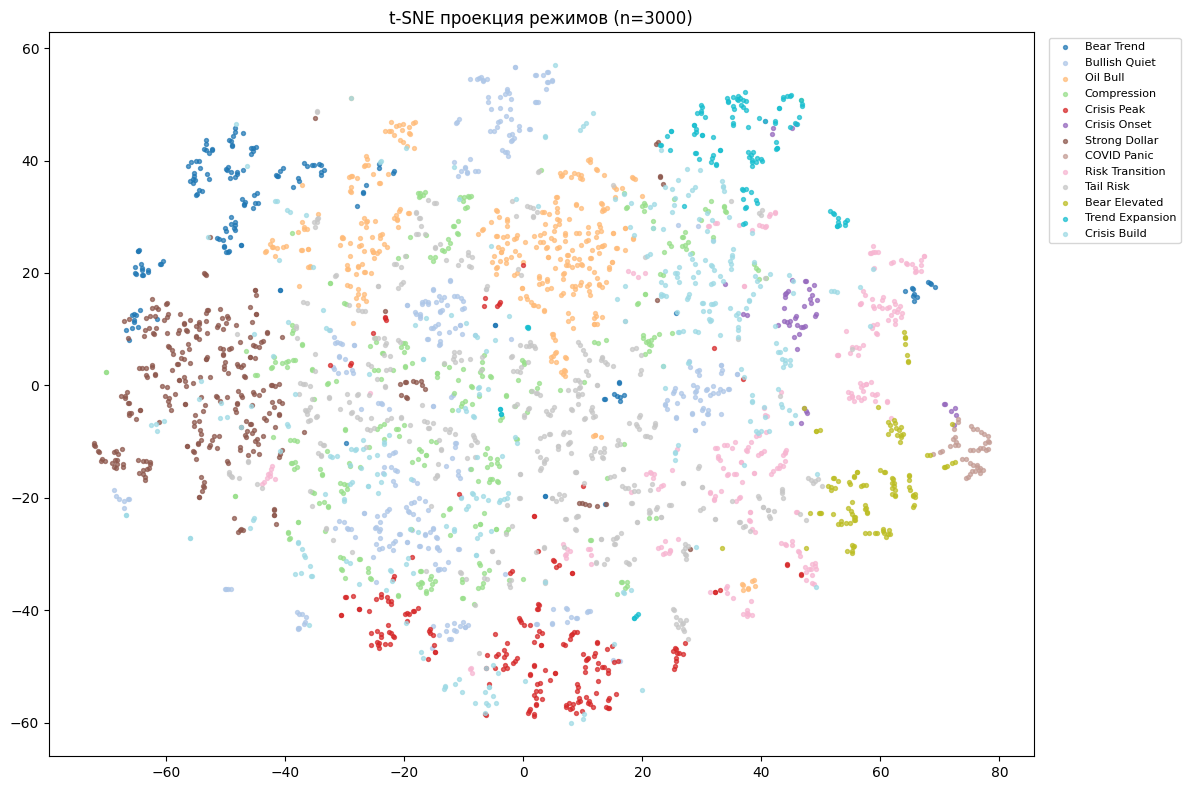

15:37:28  INFO      t-SNE сохранён: /tmp/tsne_regimes.png
15:37:28  INFO      Режимы:
regime_label
Tail Risk          558
Bullish Quiet      439
Crisis Build       438
Oil Bull           418
Compression        410
Strong Dollar      382
Risk Transition    300
Crisis Peak        277
Bear Trend         202
Bear Elevated      161
Trend Expansion    155
Crisis Onset        57
COVID Panic         52
15:37:28  INFO      Confidence stats:
count    3849.000
mean        0.990
std         0.046
min         0.510
25%         1.000
50%         1.000
75%         1.000
max         1.000
15:37:28  INFO      Entropy stats:
count    4105.000
mean        0.028
std         0.098
min        -0.000
25%         0.000
50%         0.000
75%         0.002
max         0.906
15:37:28  INFO      Дней с высокой уверенностью (>70%): 3817 (93.0%)
15:37:28  INFO      Win rate при высокой уверенности:
                                      win_rate  count
open_location        regime_label                    
inside_va_

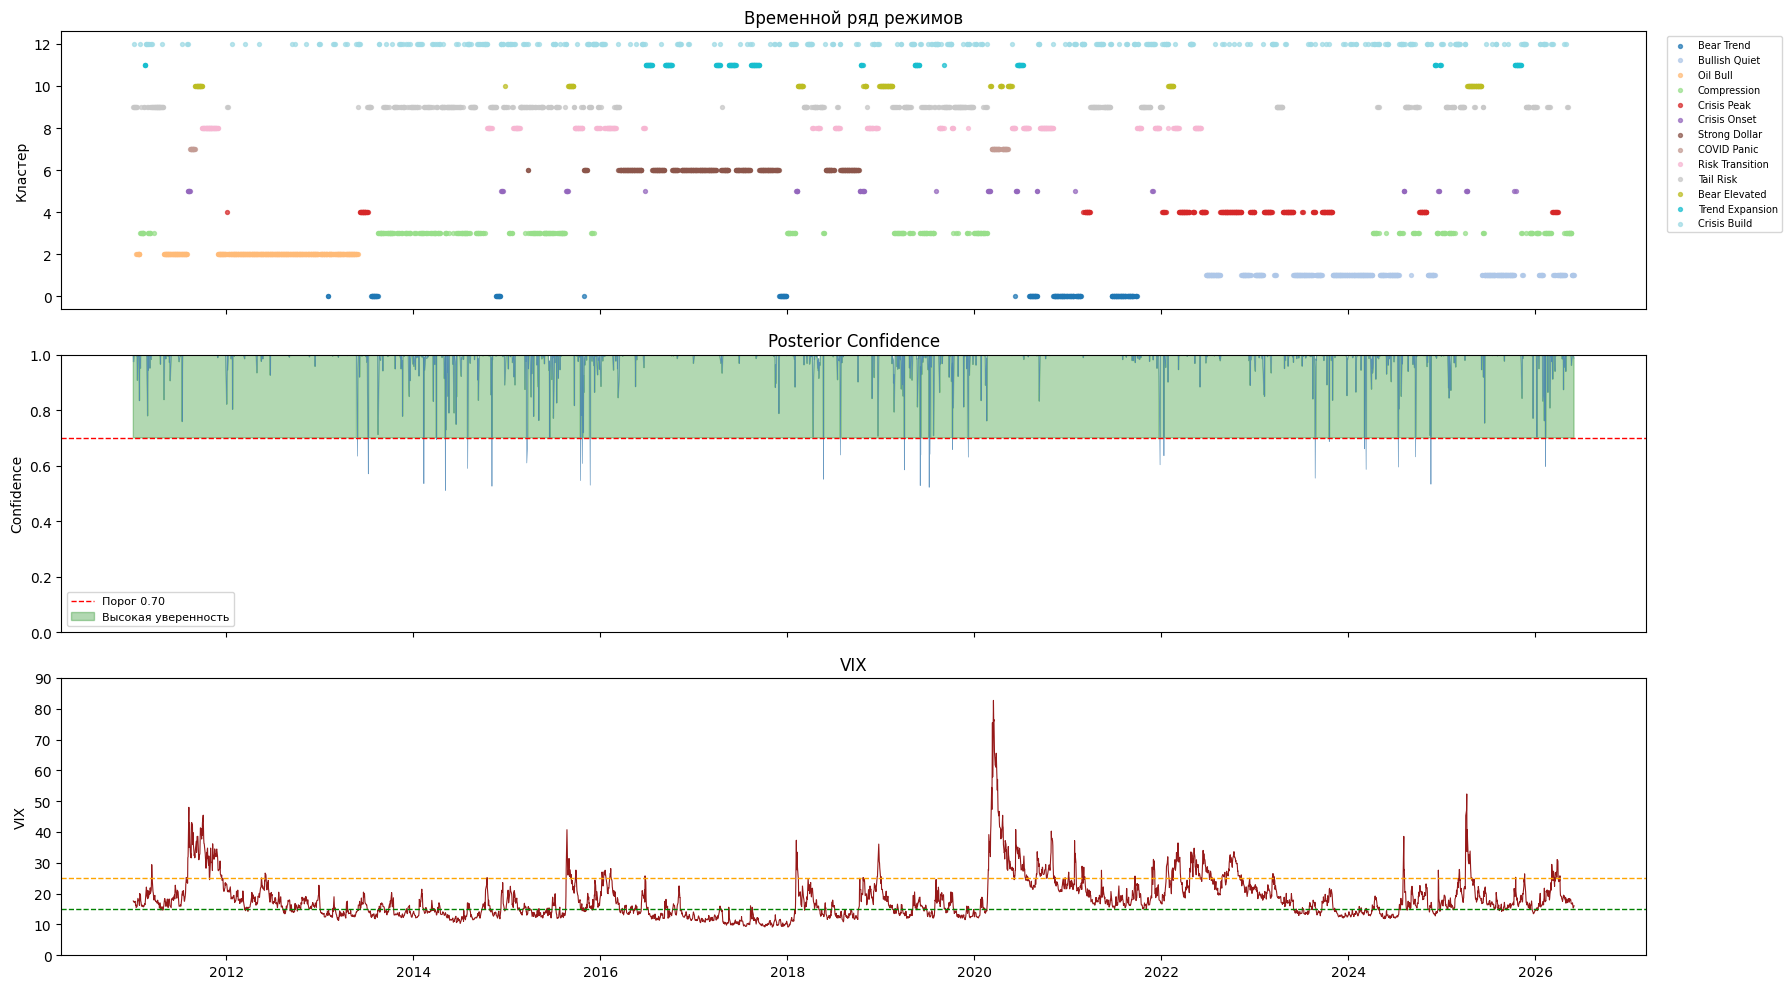

15:37:28  INFO      График сохранён: /tmp/regime_timeline.png
15:37:29  INFO      Transition matrix (labels):
                 Bear Trend  Bullish Quiet  Oil Bull  Compression  Crisis Peak  Crisis Onset  Strong Dollar  COVID Panic  Risk Transition  Tail Risk  Bear Elevated  Trend Expansion  Crisis Build
Bear Trend            0.901          0.000     0.005        0.010        0.000         0.015          0.005        0.000            0.005      0.000          0.000            0.000         0.059
Bullish Quiet         0.000          0.888     0.000        0.007        0.025         0.002          0.000        0.000            0.000      0.005          0.000            0.002         0.071
Oil Bull              0.002          0.000     0.947        0.000        0.000         0.000          0.000        0.000            0.000      0.010          0.000            0.000         0.041
Compression           0.000          0.015     0.000        0.561        0.002         0.005          0.000   

In [ ]:
#33 ── Regime Labeling + Визуализация ───────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# ── t-SNE визуализация кластеров ─────────────────────────
from sklearn.manifold import TSNE

# Метки на основе доминирующих характеристик
REGIME_LABELS = {
    0:  'Bear Trend',        # высокий DX 94, нефть 63, yield 23
    1:  'Bullish Quiet',     # нефть 77, DX 102, низкий VIX 16
    2:  'Oil Bull',          # нефть 95, DX 91, yield 21
    3:  'Compression',       # range_pct -1.6, vol_ratio 0.81, низкий VIX
    4:  'Crisis Peak',       # VIX 46, gk_vol 0.354, vol_of_vol 0.102
    5:  'Crisis Onset',      # vix_change +0.714, VIX percentile 0.955
    6:  'Strong Dollar',     # DX 113, нефть 52, низкий VIX 12
    7:  'COVID Panic',       # VIX 46, Hurst 0.558, autocorr -0.423
    8:  'Risk Transition',   # VIX 24, vol_of_vol 0.017, yield 21
    9:  'Tail Risk',         # ret_kurt 5.0, ret_skew -1.5, range_pct -1.6
    10: 'Bear Elevated',     # VIX 25, vol_of_vol 0.047, yield 16
    11: 'Trend Expansion',   # vol_ratio 1.22, prof_norm 2.8, ib_norm 1.09
    12: 'Crisis Build',      # vix_change +0.139, VIX percentile 0.635
}

plot_df_tsne = es_days.dropna(subset=GMM_FEATURES + ['gmm_cluster']).copy()
sample_size  = min(3000, len(plot_df_tsne))
sample_df    = plot_df_tsne.sample(sample_size, random_state=42).sort_index()

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
coords = tsne.fit_transform(scaler.transform(sample_df[GMM_FEATURES]))

fig, ax = plt.subplots(figsize=(12, 8))
colors   = plt.cm.tab20(np.linspace(0, 1, 13))

for cid in range(13):
    mask = sample_df['gmm_cluster'].values == cid
    label = REGIME_LABELS.get(cid, str(cid))
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[colors[cid]], s=8, alpha=0.7, label=label)

ax.set_title('t-SNE проекция режимов (n=3000)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('/tmp/tsne_regimes.png', dpi=150, bbox_inches='tight')
plt.show()
log.info('t-SNE сохранён: /tmp/tsne_regimes.png')

# ── 1. Идентификация режимов по средним features ─────────
regime_means = es_days.groupby('gmm_cluster')[GMM_FEATURES].mean()

es_days['regime_label'] = es_days['gmm_cluster'].map(REGIME_LABELS)
log.info('Режимы:\n%s', es_days['regime_label'].value_counts().to_string())

# ── 2. Posterior confidence ───────────────────────────────
prob_cols = [f'gmm_prob_{k}' for k in range(13)]
es_days['regime_confidence'] = es_days[prob_cols].max(axis=1)
es_days['regime_entropy']    = -(es_days[prob_cols] * 
    np.log(es_days[prob_cols].clip(1e-10))).sum(axis=1)

log.info('Confidence stats:\n%s',
         es_days['regime_confidence'].describe().round(3).to_string())
log.info('Entropy stats:\n%s',
         es_days['regime_entropy'].describe().round(3).to_string())

# Win rate только на высокой уверенности
es_days['direction_correct'] = (
    ((es_days['direction'] == 'long')  & (es_days['close_px'] > es_days['open_px'])) |
    ((es_days['direction'] == 'short') & (es_days['close_px'] < es_days['open_px']))
)

# Высокая уверенность = confidence > 0.7
high_conf = es_days[es_days['regime_confidence'] > 0.70]
log.info('Дней с высокой уверенностью (>70%%): %d (%.1f%%)',
         len(high_conf), len(high_conf)/len(es_days)*100)

wr_high_conf = (high_conf.groupby(['open_location', 'regime_label'])
                ['direction_correct']
                .agg(win_rate=lambda x: round(x.mean()*100, 1), count='count')
                .query('count >= 20')
                .sort_values('win_rate', ascending=False))

log.info('Win rate при высокой уверенности:\n%s',
         wr_high_conf.head(20).to_string())

# ── 3. Временной ряд режимов ──────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

# Цвета для режимов
colors = plt.cm.tab20(np.linspace(0, 1, 13))
cluster_colors = {i: colors[i] for i in range(13)}

plot_df = es_days.dropna(subset=['gmm_cluster', 'regime_confidence']).copy()
plot_df = plot_df.sort_index()

# Panel 1: Режимы во времени
ax1 = axes[0]
for cluster_id, label in REGIME_LABELS.items():
    mask = plot_df['gmm_cluster'] == cluster_id
    ax1.scatter(plot_df[mask].index, 
                plot_df[mask]['gmm_cluster'],
                c=[cluster_colors[cluster_id]], 
                s=8, label=label, alpha=0.7)
ax1.set_ylabel('Кластер')
ax1.set_title('Временной ряд режимов')
ax1.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7, ncol=1)

# Panel 2: Confidence
ax2 = axes[1]
ax2.plot(plot_df.index, plot_df['regime_confidence'], 
         linewidth=0.5, color='steelblue', alpha=0.8)
ax2.axhline(0.70, color='red', linestyle='--', linewidth=1, label='Порог 0.70')
ax2.fill_between(plot_df.index, plot_df['regime_confidence'], 
                  0.70, where=plot_df['regime_confidence'] > 0.70,
                  alpha=0.3, color='green', label='Высокая уверенность')
ax2.set_ylabel('Confidence')
ax2.set_title('Posterior Confidence')
ax2.legend(fontsize=8)
ax2.set_ylim(0, 1)

# Panel 3: VIX overlay
ax3 = axes[2]
ax3.plot(plot_df.index, plot_df['vix_close'], 
         linewidth=0.8, color='darkred', alpha=0.9)
ax3.axhline(25, color='orange', linestyle='--', linewidth=1)
ax3.axhline(15, color='green', linestyle='--', linewidth=1)
ax3.set_ylabel('VIX')
ax3.set_title('VIX')
ax3.set_ylim(0, 90)

plt.tight_layout()
plt.savefig('/tmp/regime_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
log.info('График сохранён: /tmp/regime_timeline.png')

# ── 4. Transition heatmap ─────────────────────────────────
transition_counts = pd.DataFrame(0, 
    index=list(REGIME_LABELS.values()),
    columns=list(REGIME_LABELS.values()))

labels_series = es_days['regime_label'].dropna()
for i in range(len(labels_series)-1):
    fr = labels_series.iloc[i]
    to = labels_series.iloc[i+1]
    transition_counts.loc[fr, to] += 1

transition_pct = transition_counts.div(transition_counts.sum(axis=1), axis=0).round(3)
log.info('Transition matrix (labels):\n%s', transition_pct.to_string())

# ── 5. Средняя продолжительность режимов ─────────────────
durations = []
current = None
count = 0
for label in labels_series:
    if label == current:
        count += 1
    else:
        if current is not None:
            durations.append({'regime': current, 'duration': count})
        current = label
        count = 1

dur_df = pd.DataFrame(durations)
avg_dur = dur_df.groupby('regime')['duration'].agg(['mean', 'median', 'max']).round(1)
log.info('Средняя продолжительность режимов (дни):\n%s', avg_dur.to_string())



# ── Backtest setup (восстановлено) ────────────────────────
# Порог уверенности GMM для фильтрации сделок (high-conf режимы)
CONFIDENCE_THRESHOLD = 0.70

# es_days + OOS-кластер для бэктеста субкластеров (#37) и walk-forward (#51/#52)
es_days_bt = es_days.join(test_oos[['gmm_oos']], how='left')
log.info('es_days_bt готов: %d строк, gmm_oos заполнен на %d',
         len(es_days_bt), es_days_bt['gmm_oos'].notna().sum())


15:37:29  INFO      Субкластеризация Tail Risk (кластер 9): 558 дней
15:37:29  INFO        n=2 BIC=21959.1
15:37:29  INFO        n=3 BIC=22798.7
15:37:29  INFO        n=4 BIC=23807.5
15:37:29  INFO        Оптимальное n=2
15:37:29  INFO        Средние features:
sub_cluster               0        1
vix_close            14.590   16.028
vix_percentile_252d   0.245    0.480
vix_change_5d        -0.036   -0.093
range_pct_20d        -1.435   -1.730
vol_ratio_5_20        0.870    0.749
gk_vol_20d            0.077    0.112
vol_of_vol_20d        0.010    0.014
ret_skew_20d         -0.214   -0.356
ret_kurt_20d          0.342    0.146
hurst_100d            0.368    0.381
yield_slope          17.552   13.726
dx_close             95.247  102.150
15:37:29  INFO        Win rate по субкластерам:
                                   win_rate  count  dir_correct
sub_cluster open_location                                      
0           outside_va_below_poc  79.166667   24.0    20.833333
            outsid

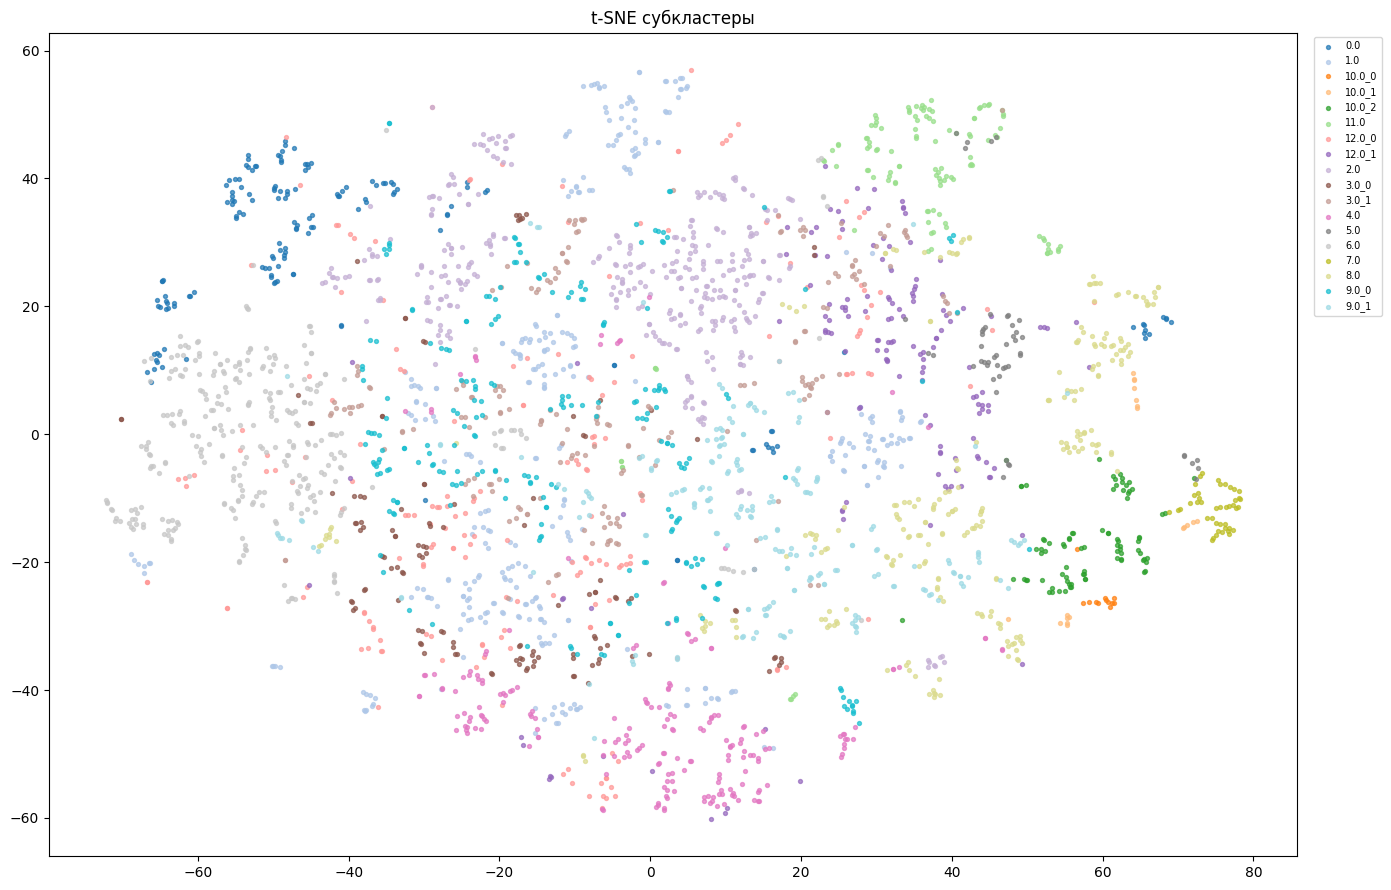

In [ ]:
#34 ── Субкластеризация Tail Risk и Compression ──────────────
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler
from sklearn.manifold import TSNE

SUB_CONFIG = {
    9:  {'name': 'Tail Risk',   'n': 3},
    3:  {'name': 'Compression', 'n': 3},
    10: {'name': 'Bear Elevated', 'n': 2},
    12: {'name': 'Crisis Build',  'n': 2},
}

sub_results = {}

for cluster_id, config in SUB_CONFIG.items():
    mask = es_days['gmm_cluster'] == cluster_id
    sub_df = es_days[mask].dropna(subset=GMM_FEATURES).copy()

    log.info('Субкластеризация %s (кластер %d): %d дней',
             config['name'], cluster_id, len(sub_df))

    if len(sub_df) < 50:
        log.info('  Пропускаем — мало данных')
        continue

    # Масштабируем — используем тот же scaler что и основной GMM
    X_sub = scaler.transform(sub_df[GMM_FEATURES])

    # BIC для выбора n
    bic_scores = []
    for n in range(2, config['n'] + 2):
        gmm_s = GaussianMixture(n_components=n, covariance_type='full',
                                random_state=42, n_init=10, reg_covar=1e-6)
        gmm_s.fit(X_sub)
        bic_scores.append((n, gmm_s.bic(X_sub)))
        log.info('  n=%d BIC=%.1f', n, bic_scores[-1][1])

    best_n = min(bic_scores, key=lambda x: x[1])[0]
    log.info('  Оптимальное n=%d', best_n)

    # Финальная субмодель
    gmm_sub = GaussianMixture(n_components=best_n, covariance_type='full',
                               random_state=42, n_init=20, reg_covar=1e-6)
    gmm_sub.fit(X_sub)

    sub_df['sub_cluster'] = gmm_sub.predict(X_sub)
    sub_proba = gmm_sub.predict_proba(X_sub)

    # Средние features по субкластерам
    key_features = ['vix_close', 'vix_percentile_252d', 'vix_change_5d',
                    'range_pct_20d', 'vol_ratio_5_20', 'gk_vol_20d',
                    'vol_of_vol_20d', 'ret_skew_20d', 'ret_kurt_20d',
                    'hurst_100d', 'yield_slope', 'dx_close']

    means = sub_df.groupby('sub_cluster')[key_features].mean().round(3)
    log.info('  Средние features:\n%s', means.T.to_string())

    # Win rate по субкластерам
    sub_df['direction_correct'] = (
        ((sub_df['direction'] == 'long')  & (sub_df['close_px'] > sub_df['open_px'])) |
        ((sub_df['direction'] == 'short') & (sub_df['close_px'] < sub_df['open_px']))
    )

    wr_sub = sub_df.groupby(['sub_cluster', 'open_location']).apply(
        lambda x: pd.Series({
            'win_rate': (x['close_px'] > x['open_px']).mean() * 100,
            'count': len(x),
            'dir_correct': x['direction_correct'].mean() * 100
        }), include_groups=False
    ).query('count >= 15').sort_values('win_rate', ascending=False)

    log.info('  Win rate по субкластерам:\n%s', wr_sub.head(15).to_string())

    # Длительность субкластеров
    dur_sub = []
    current = None
    count = 0
    for sc in sub_df['sub_cluster']:
        if sc == current:
            count += 1
        else:
            if current is not None:
                dur_sub.append({'sub': current, 'dur': count})
            current = sc
            count = 1
    dur_df = pd.DataFrame(dur_sub)
    if len(dur_df) > 0:
        log.info('  Средняя длительность субкластеров:\n%s',
                 dur_df.groupby('sub')['dur'].agg(['mean','median','max'])
                       .round(1).to_string())

    # Сохраняем в es_days
    col_name = f'sub_{cluster_id}'
    es_days.loc[mask, col_name] = np.nan
    es_days.loc[sub_df.index, col_name] = sub_df['sub_cluster'].values

    sub_results[cluster_id] = {
        'model': gmm_sub,
        'best_n': best_n,
        'df': sub_df
    }

log.info('\nСубкластеры добавлены в es_days: %s',
         [f'sub_{k}' for k in SUB_CONFIG.keys()])

# ── Transition matrix субкластеров ───────────────────────
# Создаём unified sub_cluster колонку
es_days['sub_cluster_full'] = es_days['gmm_cluster'].astype(str)

for cluster_id in SUB_CONFIG.keys():
    col = f'sub_{cluster_id}'
    mask = es_days[col].notna()
    es_days.loc[mask, 'sub_cluster_full'] = (
        es_days.loc[mask, 'gmm_cluster'].astype(str) + '_' +
        es_days.loc[mask, col].astype(int).astype(str)
    )

log.info('Уникальные субкластеры:\n%s',
         es_days['sub_cluster_full'].value_counts().to_string())

# Transition matrix
labels = es_days['sub_cluster_full'].dropna()
trans = pd.crosstab(labels.shift(1), labels, normalize='index').round(3)
log.info('Transition matrix субкластеров:\n%s', trans.to_string())

# t-SNE субкластеров
plot_sub = es_days.dropna(subset=GMM_FEATURES + ['sub_cluster_full']).copy()
sample_sub = plot_sub.sample(min(3000, len(plot_sub)), random_state=42).sort_index()

tsne_sub = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
coords_sub = tsne_sub.fit_transform(scaler.transform(sample_sub[GMM_FEATURES]))

# Уникальные метки
unique_labels = sorted(sample_sub['sub_cluster_full'].unique())
colors_sub = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
color_map = {label: colors_sub[i] for i, label in enumerate(unique_labels)}

fig, ax = plt.subplots(figsize=(14, 9))
for label in unique_labels:
    mask = sample_sub['sub_cluster_full'].values == label
    ax.scatter(coords_sub[mask, 0], coords_sub[mask, 1],
               c=[color_map[label]], s=8, alpha=0.7, label=label)

ax.set_title('t-SNE субкластеры')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7, ncol=1)
plt.tight_layout()
plt.savefig('/tmp/tsne_subclusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#36 ── Базовый бэктест (Base, восстановлено) ─────────────────
# Базовая стратегия для сравнения "Base vs Sub":
# топ OOS-сигналы (open_location × gmm_oos кластер) с фильтром по confidence,
# вход на open → выход на close того же дня, без SL/TP.
OOS_START = '2020-01-01'

BASE_SIGNALS = {
    'long': [
        ('outside_range_above', 9),
        ('outside_range_above', 3),
        ('outside_range_above', 8),
    ],
    'short': [
        ('inside_va_below_poc', 3),
        ('outside_range_below', 12),
    ],
}

bt_df = es_days_bt[es_days_bt.index >= OOS_START].copy()
bt_df = bt_df.dropna(subset=['gmm_oos', 'regime_confidence',
                             'open_px', 'close_px', 'direction'])

base_hc = bt_df['regime_confidence'] >= CONFIDENCE_THRESHOLD
long_e  = pd.Series(False, index=bt_df.index)
short_e = pd.Series(False, index=bt_df.index)
for loc, clu in BASE_SIGNALS['long']:
    long_e  |= (bt_df['open_location'] == loc) & (bt_df['gmm_oos'] == clu) & base_hc
for loc, clu in BASE_SIGNALS['short']:
    short_e |= (bt_df['open_location'] == loc) & (bt_df['gmm_oos'] == clu) & base_hc

long_pnl  = (bt_df['close_px'] - bt_df['open_px']) / bt_df['open_px']
short_pnl = (bt_df['open_px']  - bt_df['close_px']) / bt_df['open_px']

bt_df['strat_ret'] = 0.0
bt_df.loc[long_e,  'strat_ret'] = long_pnl[long_e]
bt_df.loc[short_e, 'strat_ret'] = short_pnl[short_e]

cum_base = (1 + bt_df['strat_ret']).cumprod() * 100_000
c_tot = (cum_base.iloc[-1] / 100_000 - 1) * 100
_act  = bt_df['strat_ret'][bt_df['strat_ret'] != 0]
c_sh  = bt_df['strat_ret'].mean() / bt_df['strat_ret'].std() * np.sqrt(252) if bt_df['strat_ret'].std() > 0 else 0.0
c_dd  = ((cum_base / cum_base.cummax()) - 1).min() * 100

log.info('=== BASE (восстановлено) === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%  сделок:%d',
         c_tot, c_sh, c_dd, int((bt_df['strat_ret'] != 0).sum()))

# ── Совместимость с downstream-ячейками (восстановлено) ───
SIGNALS       = BASE_SIGNALS               # алиас для #51/#52/#53
long_entries  = long_e                     # базовые лонг-входы
short_entries = short_e                    # базовые шорт-входы
cum_comb      = cum_base                   # комбо long+short без event filter (#50)


15:37:34  INFO      Распределение по группам:
cluster_group
Stable_Bull       857
Risk_Long         842
Tradeable_Risk    600
Pre_Crisis        438
Compression       410
Crisis            386
Unknown           256
Bear_Elevated     161
Expansion         155


15:37:34  INFO      Win rate по группам × open_location:
                                      win_rate   short_wr   avg_ret  count
cluster_group  open_location                                              
Bear_Elevated  inside_va_below_poc   62.962963  37.037037  0.546319   27.0
               outside_range_above   60.465116  37.209302  0.090116   43.0
               inside_va_above_poc   51.724138  48.275862  0.375550   29.0
               outside_range_below   48.148148  51.851852  0.168843   27.0
               outside_va_below_poc  47.619048  52.380952 -0.338078   21.0
Compression    outside_va_above_poc  60.465116  39.534884  0.067494   43.0
               outside_range_below   58.333333  41.666667  0.110749   84.0
               inside_va_below_poc   57.894737  40.350877  0.078511   57.0
               outside_range_above   56.000000  44.000000  0.039010  100.0
               outside_va_below_poc  53.061224  46.938776  0.002382   49.0
               inside_va_above_poc   51.948

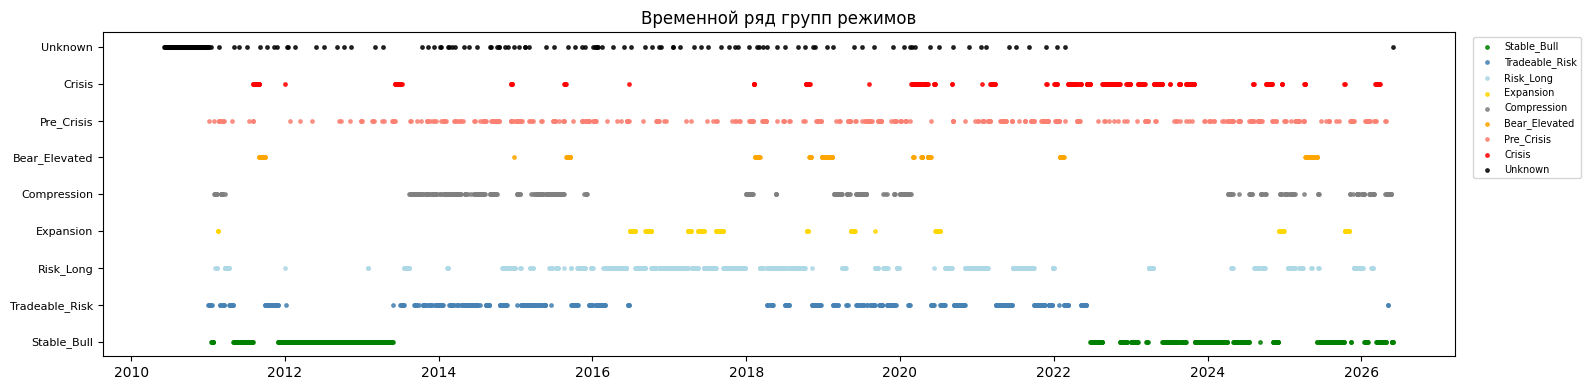

15:37:34  INFO      Дней после Transition: 438
15:37:34  INFO      После Transition — следующий режим:
cluster_group
Transition          168
Compression          75
Tradeable_Risk       54
Risk_Long            51
Stable_Bull          46
Crisis               31
Commodity_Driven     10
Expansion             2
Bear_Elevated         1
15:37:34  INFO      После Transition — Win rate по open_location:
15:37:34  INFO      
                                      win_rate  count
cluster_group  open_location                         
Compression    outside_range_above   76.923077   13.0
Risk_Long      outside_range_above   72.222222   18.0
Tradeable_Risk outside_range_above   72.222222   18.0
Compression    inside_va_above_poc   66.666667   21.0
Risk_Long      outside_va_above_poc  66.666667   12.0
Compression    inside_va_below_poc   56.250000   16.0
Tradeable_Risk outside_va_above_poc  54.545455   11.0
Risk_Long      inside_va_above_poc   54.545455   11.0
Transition     outside_va_above_poc  50.

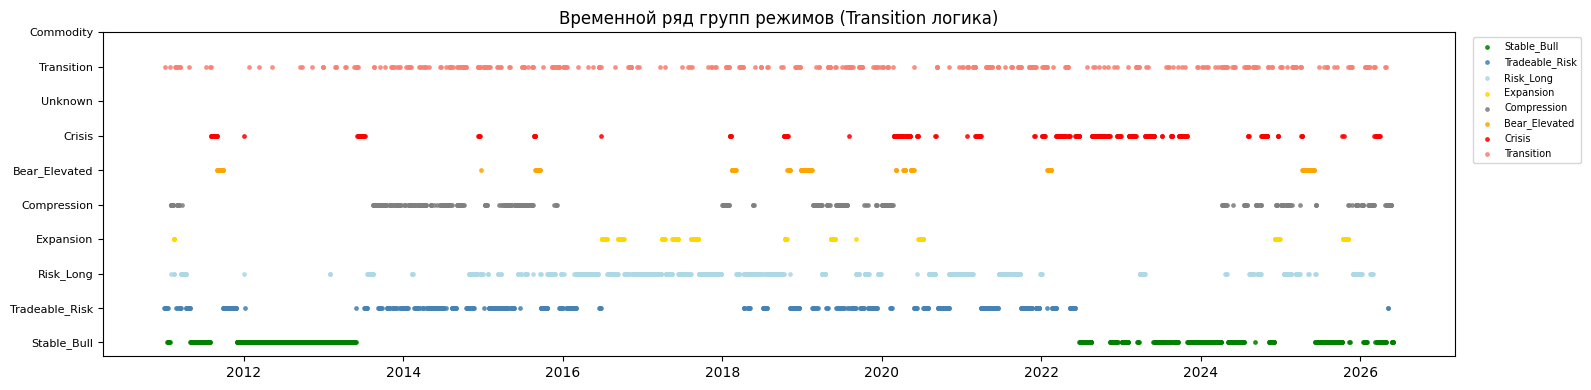

In [ ]:
#41 ── Группировка кластеров ─────────────────────────────────

CLUSTER_GROUPS = {
    # Стабильные бычьи — торгуем лонг агрессивно
    'Stable_Bull': {
        'clusters': ['1.0', '2.0'],
        'sub': [],
        'strategy': 'long',
        'size': 1.0,
        'description': 'Bullish Quiet + Oil Bull — низкий VIX, стабильный тренд'
    },

    # Торгуемый риск — лонг с нормальным размером
    'Tradeable_Risk': {
        'clusters': ['9.0_0', '8.0'],
        'sub': [],
        'strategy': 'long',
        'size': 1.0,
        'description': 'Tail Risk sub_0 + Risk Transition — скрытый риск, торгуемый'
    },

    # Высокий риск лонг — уменьшенный размер
    'Risk_Long': {
        'clusters': ['9.0_1', '0.0', '6.0'],
        'sub': [],
        'strategy': 'long',
        'size': 0.75,
        'description': 'Tail Risk sub_1 + Bear Trend + Strong Dollar'
    },

    # Expansion — momentum лонг
    'Expansion': {
        'clusters': ['11.0'],
        'sub': [],
        'strategy': 'long',
        'size': 1.25,
        'description': 'Trend Expansion — лучший WR, momentum'
    },

    # Compression — переходный, малый размер
    'Compression': {
        'clusters': ['3.0_0', '3.0_1'],
        'sub': [],
        'strategy': 'long',
        'size': 0.5,
        'description': 'Compression — переходный режим, ждём подтверждения'
    },

    # Bear Elevated — осторожно
    'Bear_Elevated': {
        'clusters': ['10.0_0', '10.0_1', '10.0_2'],
        'sub': [],
        'strategy': 'selective',
        'size': 0.5,
        'description': 'Bear Elevated — затяжной повышенный риск'
    },

    # Предкризисный — пропускаем лонг, шортим
    'Pre_Crisis': {
        'clusters': ['12.0_0', '12.0_1'],
        'sub': [],
        'strategy': 'short',
        'size': 0.75,
        'description': 'Crisis Build — нарастающий риск, антисигнал'
    },

    # Острый кризис — шортим
    'Crisis': {
        'clusters': ['4.0', '5.0', '7.0'],
        'sub': [],
        'strategy': 'short',
        'size': 1.0,
        'description': 'Crisis Peak + Onset + COVID Panic'
    },
}

# Добавляем group в es_days
es_days['cluster_group'] = 'Unknown'
for group_name, config in CLUSTER_GROUPS.items():
    for cluster in config['clusters']:
        mask = es_days['sub_cluster_full'] == cluster
        es_days.loc[mask, 'cluster_group'] = group_name

log.info('Распределение по группам:\n%s',
         es_days['cluster_group'].value_counts().to_string())

# Win rate по группам × open_location
group_wr = (es_days.groupby(['cluster_group', 'open_location'])
    .apply(lambda x: pd.Series({
        'win_rate':  (x['close_px'] > x['open_px']).mean() * 100,
        'short_wr':  (x['close_px'] < x['open_px']).mean() * 100,
        'avg_ret':   ((x['close_px'] - x['open_px']) / x['open_px']).mean() * 100,
        'count':     len(x),
    }), include_groups=False)
    .query('count >= 20')
    .sort_values(['cluster_group', 'win_rate'], ascending=[True, False]))

log.info('Win rate по группам × open_location:\n%s', group_wr.to_string())

# Transition matrix групп
group_labels = es_days['cluster_group'].dropna()
group_trans = pd.crosstab(
    group_labels.shift(1), group_labels, normalize='index').round(3)
log.info('Transition matrix групп:\n%s', group_trans.to_string())

# Средняя продолжительность групп
dur_group = []
current = None
count = 0
for g in group_labels:
    if g == current:
        count += 1
    else:
        if current is not None:
            dur_group.append({'group': current, 'dur': count})
        current = g
        count = 1
dur_group_df = pd.DataFrame(dur_group)
log.info('Средняя продолжительность групп:\n%s',
         dur_group_df.groupby('group')['dur']
                     .agg(['mean', 'median', 'max'])
                     .round(1).to_string())

# OOS win rate по группам
oos_group = es_days[es_days.index >= '2020-01-01'].copy()
oos_group_wr = (oos_group.groupby(['cluster_group', 'open_location'])
    .apply(lambda x: pd.Series({
        'win_rate': (x['close_px'] > x['open_px']).mean() * 100,
        'count':    len(x),
    }), include_groups=False)
    .query('count >= 10')
    .sort_values(['cluster_group', 'win_rate'], ascending=[True, False]))

log.info('OOS Win rate по группам:\n%s', oos_group_wr.to_string())

# Визуализация — временной ряд групп
fig, ax = plt.subplots(figsize=(16, 4))
group_colors = {
    'Stable_Bull':    'green',
    'Tradeable_Risk': 'steelblue',
    'Risk_Long':      'lightblue',
    'Expansion':      'gold',
    'Compression':    'gray',
    'Bear_Elevated':  'orange',
    'Pre_Crisis':     'salmon',
    'Crisis':         'red',
    'Unknown':        'black',
}

plot_groups = es_days['cluster_group'].dropna()
for group, color in group_colors.items():
    mask = plot_groups == group
    ax.scatter(plot_groups[mask].index,
               [list(group_colors.keys()).index(group)] * mask.sum(),
               c=color, s=6, alpha=0.8, label=group)

ax.set_title('Временной ряд групп режимов')
ax.set_yticks(range(len(group_colors)))
ax.set_yticklabels(list(group_colors.keys()), fontsize=8)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig('/tmp/group_timeline.png', dpi=170, bbox_inches='tight')
plt.show()


CLUSTER_GROUPS['Transition'] = CLUSTER_GROUPS.pop('Pre_Crisis')
CLUSTER_GROUPS['Transition']['description'] = 'Transition — переходный буфер, ждём следующий режим'
CLUSTER_GROUPS['Transition']['strategy'] = 'wait'

# Commodity_Driven добавляем как новую группу
CLUSTER_GROUPS['Commodity_Driven'] = {
    'clusters': [],
    'sub': [],
    'strategy': 'selective',
    'size': 0.5,
    'description': 'Commodity Driven — высокая корреляция нефть/ES, слабый доллар, 2010-2011'
}

# Обновляем в es_days
es_days['cluster_group'] = es_days['cluster_group'].replace('Pre_Crisis', 'Transition')
es_days['cluster_group'] = es_days['cluster_group'].replace('Unknown', 'Commodity_Driven')

# Добавляем флаг — день после Transition
es_days['after_transition'] = (
    es_days['cluster_group'].shift(1) == 'Transition'
).astype(int)

log.info('Дней после Transition: %d', es_days['after_transition'].sum())

# Что происходит после Transition
after_trans = es_days[es_days['after_transition'] == 1].copy()
after_trans['direction_correct'] = (
    ((after_trans['direction'] == 'long')  & (after_trans['close_px'] > after_trans['open_px'])) |
    ((after_trans['direction'] == 'short') & (after_trans['close_px'] < after_trans['open_px']))
)

log.info('После Transition — следующий режим:\n%s',
         after_trans['cluster_group'].value_counts().to_string())

log.info('После Transition — Win rate по open_location:')
after_wr = (after_trans.groupby(['cluster_group', 'open_location'])
    .apply(lambda x: pd.Series({
        'win_rate': (x['close_px'] > x['open_px']).mean() * 100,
        'count':    len(x),
    }), include_groups=False)
    .query('count >= 10')
    .sort_values('win_rate', ascending=False))

log.info('\n%s', after_wr.head(20).to_string())

# Повышенное внимание — торгуем после Transition с фильтром
# Если после Transition идёт Stable_Bull или Risk_Long → лонг сигнал усиливается
# Если после Transition идёт Crisis → пропускаем

after_bull = after_trans[
    after_trans['cluster_group'].isin(['Stable_Bull', 'Risk_Long', 'Tradeable_Risk'])
]
after_crisis = after_trans[
    after_trans['cluster_group'].isin(['Crisis'])
]

log.info('После Transition → бычьи группы: n=%d  WR=%.1f%%',
         len(after_bull),
         (after_bull['close_px'] > after_bull['open_px']).mean() * 100)

log.info('После Transition → Crisis: n=%d  WR=%.1f%%',
         len(after_crisis),
         (after_crisis['close_px'] > after_crisis['open_px']).mean() * 100)

# Добавляем after_transition как feature в bt_df
bt_df['after_transition'] = es_days['after_transition'].reindex(bt_df.index, fill_value=0)

# OOS статистика
after_oos = after_trans[after_trans.index >= '2020-01-01']
log.info('\nOOS после Transition — следующий режим:\n%s',
         after_oos['cluster_group'].value_counts().to_string())

wr_after_oos = (after_oos.groupby('open_location')
    .apply(lambda x: pd.Series({
        'win_rate': (x['close_px'] > x['open_px']).mean() * 100,
        'count':    len(x),
    }), include_groups=False)
    .sort_values('win_rate', ascending=False))

log.info('OOS WR после Transition по open_location:\n%s', wr_after_oos.to_string())

# Визуализация обновлённого временного ряда
group_colors['Transition'] = 'salmon'
group_colors['Commodity'] = 'Black'
group_colors.pop('Pre_Crisis', None)

fig, ax = plt.subplots(figsize=(16, 4))
plot_groups = es_days['cluster_group'].dropna()
group_list = list(group_colors.keys())

for group, color in group_colors.items():
    mask = plot_groups == group
    if mask.sum() == 0:
        continue
    ax.scatter(plot_groups[mask].index,
               [group_list.index(group)] * mask.sum(),
               c=color, s=6, alpha=0.8, label=group)

ax.set_title('Временной ряд групп режимов (Transition логика)')
ax.set_yticks(range(len(group_list)))
ax.set_yticklabels(group_list, fontsize=8)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig('/tmp/group_timeline_v2.png', dpi=150, bbox_inches='tight')
plt.show()


15:37:34  INFO      Transition streak распределение:
transition_streak
0     3667
1      270
2       78
3       38
4       19
5       11
6        7
7        5
8        4
9        2
10       1
11       1
12       1
13       1
15:37:34  INFO      WR после streak >= 3:
                       win_rate  count
open_location                         
outside_va_above_poc  71.428571    7.0
inside_va_above_poc   64.285714   14.0
outside_va_below_poc  53.333333   15.0
inside_va_below_poc   48.000000   25.0
outside_range_below   40.000000   15.0
outside_range_above   28.571429   14.0
15:37:34  INFO      Compression streak распределение:
compression_streak
0     3695
1      184
2       96
3       52
4       24
5       14
6       11
7       10
8        7
9        6
10       4
11       1
12       1
15:37:34  INFO      Compression streak=1: WR=55.4%  n=184
15:37:34  INFO      Compression streak=2: WR=60.4%  n=96
15:37:34  INFO      Compression streak=3: WR=57.7%  n=52
15:37:34  INFO      WR после comp

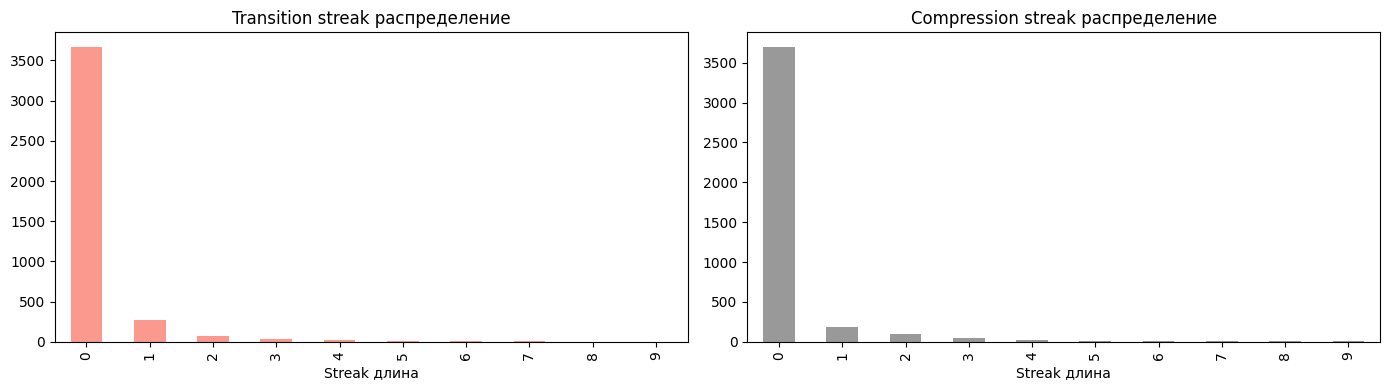

In [ ]:
#42 Transition/Compression
# длится 1-2 дня в норме
# Если > 2 дней подряд → это уже другой сигнал — затяжная неопределённость

es_days['transition_streak'] = 0
streak = 0
for i, group in enumerate(es_days['cluster_group']):
    if group == 'Transition':
        streak += 1
    else:
        streak = 0
    es_days.iloc[i, es_days.columns.get_loc('transition_streak')] = streak

# Три категории
# streak == 1 → нормальный переход, ждём завтра
# streak == 2 → подтверждённый переход, торгуем следующий день осторожно  
# streak >= 3 → затяжная неопределённость → не торгуем или шортим

log.info('Transition streak распределение:\n%s',
         es_days['transition_streak'].value_counts().sort_index().head(15).to_string())

log.info('WR после streak >= 3:\n%s',
         es_days[es_days['transition_streak'] >= 3].groupby('open_location')
         .apply(lambda x: pd.Series({
             'win_rate': (x['close_px'] > x['open_px']).mean() * 100,
             'count': len(x)
         }), include_groups=False)
         .sort_values('win_rate', ascending=False).to_string())

# ── Compression streak + валидация + sticky regime ────────

# Compression streak
es_days['compression_streak'] = 0
streak_c = 0
for i, group in enumerate(es_days['cluster_group']):
    if group == 'Compression':
        streak_c += 1
    else:
        streak_c = 0
    es_days.iloc[i, es_days.columns.get_loc('compression_streak')] = streak_c

log.info('Compression streak распределение:\n%s',
         es_days['compression_streak'].value_counts().sort_index().head(15).to_string())

# WR после compression streak
for streak_val in [1, 2, 3]:
    subset = es_days[es_days['compression_streak'] == streak_val]
    if len(subset) < 10:
        continue
    wr = (subset['close_px'] > subset['open_px']).mean() * 100
    log.info('Compression streak=%d: WR=%.1f%%  n=%d', streak_val, wr, len(subset))

log.info('WR после compression streak >= 3:\n%s',
         es_days[es_days['compression_streak'] >= 3].groupby('open_location')
         .apply(lambda x: pd.Series({
             'win_rate': (x['close_px'] > x['open_px']).mean() * 100,
             'count': len(x)
         }), include_groups=False)
         .sort_values('win_rate', ascending=False).to_string())

# ── Что следует за Compression ────────────────────────────
comp_exits = es_days[
    (es_days['cluster_group'].shift(1) == 'Compression') &
    (es_days['cluster_group'] != 'Compression')
].copy()

log.info('\nПосле Compression — следующий режим:\n%s',
         comp_exits['cluster_group'].value_counts().to_string())

comp_exit_wr = (comp_exits.groupby(['cluster_group', 'open_location'])
    .apply(lambda x: pd.Series({
        'win_rate': (x['close_px'] > x['open_px']).mean() * 100,
        'count':    len(x),
    }), include_groups=False)
    .query('count >= 8')
    .sort_values('win_rate', ascending=False))

log.info('WR после выхода из Compression:\n%s',
         comp_exit_wr.head(15).to_string())

# ── Oil/Commodity Driven без 2010-2011 ────────────────────
commodity_clean = es_days[
    (es_days['cluster_group'] == 'Commodity_Driven') &
    (es_days.index >= '2012-01-01')
].copy()

log.info('\nCommodity Driven 2012-2026: %d дней', len(commodity_clean))
log.info('По годам:\n%s',
         commodity_clean.index.year.value_counts().sort_index().to_string())
log.info('Средние features:\n%s',
         commodity_clean[GMM_FEATURES].mean().round(3).to_string())
log.info('Win rate по open_location:\n%s',
         commodity_clean.groupby('open_location')
         .apply(lambda x: pd.Series({
             'win_rate': (x['close_px'] > x['open_px']).mean() * 100,
             'count': len(x)
         }), include_groups=False)
         .sort_values('win_rate', ascending=False).to_string())

# Средняя длительность Commodity Driven 2012+
dur_commodity = []
current = None
count = 0
for date, group in es_days[es_days.index >= '2012-01-01']['cluster_group'].items():
    if group == 'Commodity_Driven':
        count += 1
    else:
        if count > 0:
            dur_commodity.append(count)
        count = 0
if count > 0:
    dur_commodity.append(count)

if dur_commodity:
    log.info('Commodity Driven 2012+ длительность: mean=%.1f  median=%.1f  max=%d',
             np.mean(dur_commodity), np.median(dur_commodity), max(dur_commodity))

# ── Sticky Regime — Compression + Transition вместе ───────
es_days['comp_trans_streak'] = 0
streak_ct = 0
for i, group in enumerate(es_days['cluster_group']):
    if group in ['Compression', 'Transition']:
        streak_ct += 1
    else:
        streak_ct = 0
    es_days.iloc[i, es_days.columns.get_loc('comp_trans_streak')] = streak_ct

log.info('\nComp+Trans sticky streak распределение:\n%s',
         es_days['comp_trans_streak'].value_counts().sort_index().head(20).to_string())

# WR после выхода из sticky zone (streak >= 3)
sticky_exits = es_days[
    (es_days['comp_trans_streak'].shift(1) >= 3) &
    (es_days['comp_trans_streak'] == 0)
].copy()

log.info('Выходы из sticky zone (streak>=3): %d', len(sticky_exits))
log.info('Следующий режим после sticky:\n%s',
         sticky_exits['cluster_group'].value_counts().to_string())

sticky_wr = (sticky_exits.groupby(['cluster_group', 'open_location'])
    .apply(lambda x: pd.Series({
        'win_rate': (x['close_px'] > x['open_px']).mean() * 100,
        'count':    len(x),
    }), include_groups=False)
    .query('count >= 5')
    .sort_values('win_rate', ascending=False))

log.info('WR после выхода из sticky zone:\n%s',
         sticky_wr.head(20).to_string())

# Средняя длина sticky zone
sticky_durations = []
current_streak = 0
for val in es_days['comp_trans_streak']:
    if val > 0:
        current_streak = val
    elif current_streak > 0:
        sticky_durations.append(current_streak)
        current_streak = 0

if sticky_durations:
    log.info('Sticky zone длительность: mean=%.1f  median=%.1f  max=%d',
             np.mean(sticky_durations),
             np.median(sticky_durations),
             max(sticky_durations))

# Визуализация streak
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

es_days['transition_streak'].value_counts().sort_index().head(10).plot(
    kind='bar', ax=axes[0], color='salmon', alpha=0.8)
axes[0].set_title('Transition streak распределение')
axes[0].set_xlabel('Streak длина')

es_days['compression_streak'].value_counts().sort_index().head(10).plot(
    kind='bar', ax=axes[1], color='gray', alpha=0.8)
axes[1].set_title('Compression streak распределение')
axes[1].set_xlabel('Streak длина')

plt.tight_layout()
plt.savefig('/tmp/streak_analysis.png', dpi=150, bbox_inches='tight')
plt.show()



15:37:36  INFO      Streak колонки добавлены: ['streak_stable_bull', 'streak_tradeable_risk', 'streak_risk_long', 'streak_expansion', 'streak_bear_elevated', 'streak_crisis', 'streak_transition', 'streak_compression', 'streak_commodity_driven']
15:37:36  INFO      
=== Stable_Bull ===
15:37:36  INFO      Streak распределение:
streak_stable_bull
0    3248
1      84
2      71
3      59
4      55
5      51
6      47
7      45
8      38
9      36
15:37:36  INFO        Streak=1: WR=58.3%  n=84
15:37:36  INFO        Streak=2: WR=59.2%  n=71
15:37:36  INFO        Streak=3: WR=61.0%  n=59
15:37:36  INFO        Streak=5: WR=62.7%  n=51
15:37:36  INFO        Streak=7: WR=64.4%  n=45
15:37:36  INFO        Streak=10: WR=48.5%  n=33
15:37:36  INFO      Выходы (после streak>=3): 59
15:37:36  INFO      Следующий режим:
cluster_group
Transition          39
Commodity_Driven    10
Crisis               5
Risk_Long            2
Compression          2
15:37:36  INFO      WR после выхода:
                  

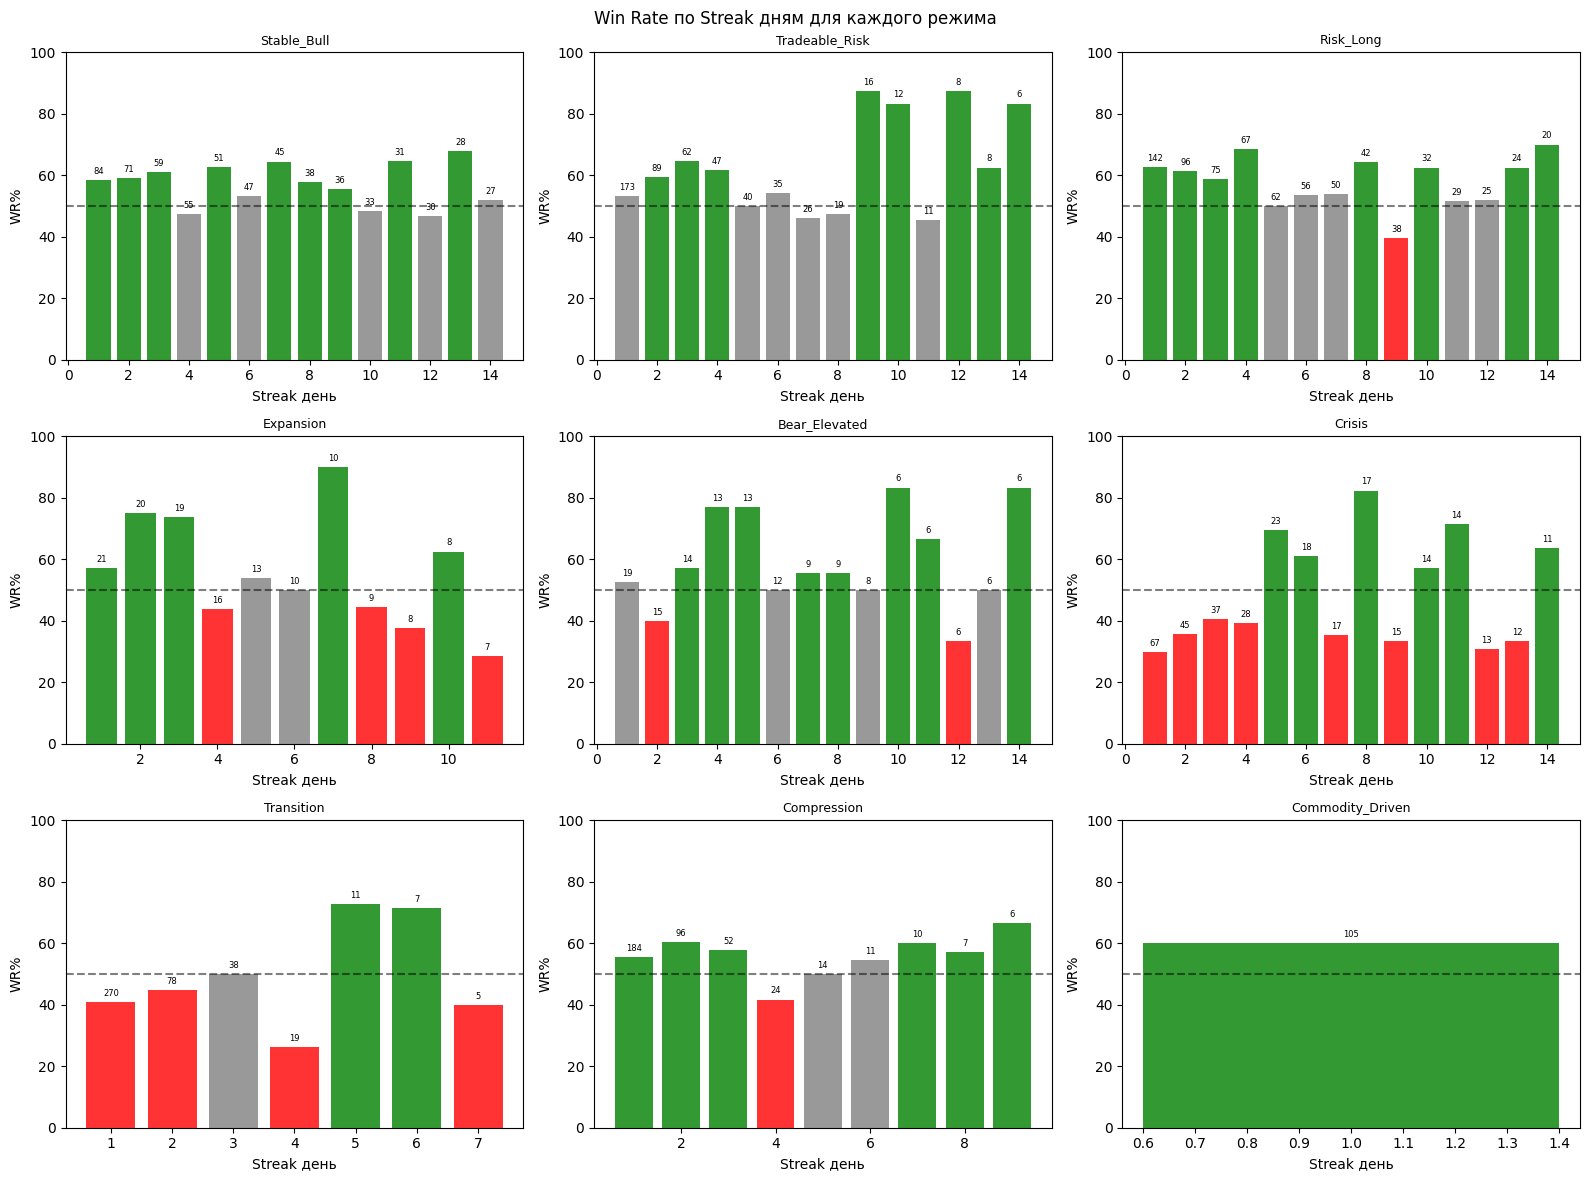

In [ ]:
#43 ── Universal Streak Analysis ─────────────────────────────

REGIMES = [
    'Stable_Bull', 'Tradeable_Risk', 'Risk_Long', 'Expansion',
    'Bear_Elevated', 'Crisis', 'Transition', 'Compression',
    'Commodity_Driven'
]

# Считаем streak для каждого режима
for regime in REGIMES:
    col = f'streak_{regime.lower()}'
    es_days[col] = 0
    streak = 0
    for i, group in enumerate(es_days['cluster_group']):
        if group == regime:
            streak += 1
        else:
            streak = 0
        es_days.iloc[i, es_days.columns.get_loc(col)] = streak

log.info('Streak колонки добавлены: %s',
         [f'streak_{r.lower()}' for r in REGIMES])

# ── Анализ каждого режима ─────────────────────────────────
streak_stats = {}

for regime in REGIMES:
    col = f'streak_{regime.lower()}'
    log.info('\n=== %s ===', regime)

    # Распределение streak
    dist = es_days[col].value_counts().sort_index()
    log.info('Streak распределение:\n%s', dist.head(10).to_string())

    # WR по streak уровням
    for streak_val in [1, 2, 3, 5, 7, 10]:
        subset = es_days[es_days[col] == streak_val]
        if len(subset) < 5:
            continue
        wr = (subset['close_px'] > subset['open_px']).mean() * 100
        log.info('  Streak=%d: WR=%.1f%%  n=%d', streak_val, wr, len(subset))

    # Что происходит ПОСЛЕ выхода из режима
    exits = es_days[
        (es_days[col].shift(1) >= 3) &
        (es_days[col] == 0)
    ].copy()

    if len(exits) > 0:
        log.info('Выходы (после streak>=3): %d', len(exits))
        log.info('Следующий режим:\n%s',
                 exits['cluster_group'].value_counts().head(5).to_string())

        exit_wr = (exits.groupby(['cluster_group', 'open_location'])
            .apply(lambda x: pd.Series({
                'win_rate': (x['close_px'] > x['open_px']).mean() * 100,
                'count':    len(x),
            }), include_groups=False)
            .query('count >= 5')
            .sort_values('win_rate', ascending=False))

        if len(exit_wr) > 0:
            log.info('WR после выхода:\n%s', exit_wr.head(8).to_string())

    # Оптимальный порог streak для торговли
    wrs = []
    for s in range(1, 15):
        sub = es_days[es_days[col] == s]
        if len(sub) < 10:
            break
        wr = (sub['close_px'] > sub['open_px']).mean() * 100
        wrs.append((s, wr, len(sub)))

    if wrs:
        best = max(wrs, key=lambda x: x[1])
        streak_stats[regime] = {
            'best_streak': best[0],
            'best_wr': best[1],
            'best_n': best[2]
        }
        log.info('Оптимальный streak: day=%d  WR=%.1f%%  n=%d',
                 best[0], best[1], best[2])

# ── Сводная таблица ───────────────────────────────────────
summary = pd.DataFrame(streak_stats).T
log.info('\n=== СВОДНАЯ ТАБЛИЦА ОПТИМАЛЬНЫХ STREAK ===\n%s',
         summary.to_string())

# ── Визуализация WR по streak для каждого режима ──────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, regime in enumerate(REGIMES):
    col = f'streak_{regime.lower()}'
    ax = axes[i]

    wrs, ns, streaks = [], [], []
    for s in range(1, 15):
        sub = es_days[es_days[col] == s]
        if len(sub) < 5:
            break
        wr = (sub['close_px'] > sub['open_px']).mean() * 100
        wrs.append(wr)
        ns.append(len(sub))
        streaks.append(s)

    if streaks:
        colors = ['green' if w > 55 else 'red' if w < 45 else 'gray' for w in wrs]
        ax.bar(streaks, wrs, color=colors, alpha=0.8)
        ax.axhline(50, color='black', linestyle='--', alpha=0.5)
        ax.set_title(f'{regime}', fontsize=9)
        ax.set_xlabel('Streak день')
        ax.set_ylabel('WR%')
        ax.set_ylim(0, 100)

        # Аннотируем n
        for s, w, n in zip(streaks, wrs, ns):
            ax.text(s, w + 2, str(n), ha='center', fontsize=6)

plt.suptitle('Win Rate по Streak дням для каждого режима', fontsize=12)
plt.tight_layout()
plt.savefig('/tmp/streak_all_regimes.png', dpi=150, bbox_inches='tight')
plt.show()

15:37:36  INFO      OOS Win rate субкластер × open_location:
                                        win_rate   avg_ret  count  total_ret
sub_cluster_full open_location                                              
1.0              inside_va_below_poc   72.727273  0.106321   66.0   7.017163
9.0_0            outside_range_above   72.413793  0.094167   29.0   2.730834
3.0_1            outside_range_below   68.421053  0.276717   19.0   5.257629
0.0              inside_va_below_poc   68.181818  0.214521   22.0   4.719460
                 outside_range_above   67.857143  0.026533   56.0   1.485853
4.0              outside_va_above_poc  65.517241  0.257090   29.0   7.455618
9.0_1            outside_range_above   64.705882  0.126551   34.0   4.302740
1.0              inside_va_above_poc   64.000000  0.119858   75.0   8.989384
8.0              outside_range_below   63.636364  0.307849   22.0   6.772671
1.0              outside_va_below_poc  62.790698  0.126808   43.0   5.452727
9.0_1          

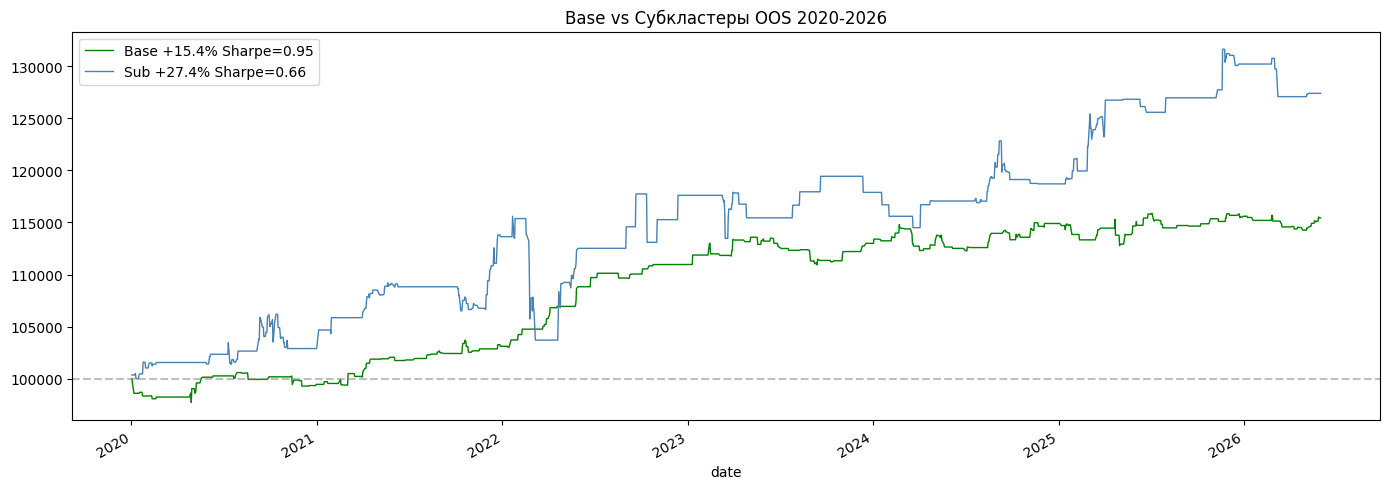

In [ ]:
#37 ── Бэктест субкластеров ──────────────────────────────────
OOS_START = '2020-01-01'

# Джойним sub_cluster_full к bt_df
bt_sub = es_days_bt.copy()
# убираем join — gmm_oos уже есть
bt_sub['sub_cluster_full'] = es_days['sub_cluster_full'].reindex(bt_sub.index)

bt_sub = bt_sub[bt_sub.index >= OOS_START].copy()
bt_sub = bt_sub.dropna(subset=['gmm_oos', 'open_px', 'close_px',
                                'direction', 'sub_cluster_full'])

bt_sub['raw_ret'] = (bt_sub['close_px'] - bt_sub['open_px']) / bt_sub['open_px']

# Все комбинации sub_cluster_full × open_location
sub_wr = (bt_sub.groupby(['sub_cluster_full', 'open_location'])
          .apply(lambda x: pd.Series({
              'win_rate': (x['close_px'] > x['open_px']).mean() * 100,
              'avg_ret':  x['raw_ret'].mean() * 100,
              'count':    len(x),
              'total_ret':x['raw_ret'].sum() * 100,
          }), include_groups=False)
          .query('count >= 15')
          .sort_values('win_rate', ascending=False))

log.info('OOS Win rate субкластер × open_location:\n%s',
         sub_wr.head(25).to_string())
log.info('Антисигналы:\n%s',
         sub_wr.tail(15).to_string())

# Топ лонг сигналы из субкластеров
LONG_SIGNALS_SUB = [
    ('outside_range_above', '9.0_0'),
    ('outside_range_above', '9.0_1'),
    ('outside_range_above', '8.0'),
    ('outside_range_above', '3.0_1'),
    ('outside_va_above_poc', '9.0_0'),
    ('inside_va_above_poc', '8.0'),
]

SHORT_SIGNALS_SUB = [
    ('outside_range_below', '12.0_1'),
    ('inside_va_below_poc', '12.0_1'),
    ('outside_range_above', '12.0_0'),
    ('outside_range_above', '12.0_1'),
]

high_conf_sub = bt_sub['regime_confidence'] >= CONFIDENCE_THRESHOLD

long_sub  = pd.Series(False, index=bt_sub.index)
short_sub = pd.Series(False, index=bt_sub.index)

for loc, cluster in LONG_SIGNALS_SUB:
    long_sub |= ((bt_sub['open_location'] == loc) &
                 (bt_sub['sub_cluster_full'] == cluster) &
                 high_conf_sub)

for loc, cluster in SHORT_SIGNALS_SUB:
    short_sub |= ((bt_sub['open_location'] == loc) &
                  (bt_sub['sub_cluster_full'] == cluster) &
                  high_conf_sub)

long_t  = bt_sub[long_sub].copy()
short_t = bt_sub[short_sub].copy()

long_t['pnl']  = (long_t['close_px']  - long_t['open_px'])  / long_t['open_px']
short_t['pnl'] = (short_t['open_px']  - short_t['close_px']) / short_t['open_px']

long_wr_sub  = (long_t['close_px'] > long_t['open_px']).mean() * 100
short_wr_sub = (short_t['close_px'] < short_t['open_px']).mean() * 100

log.info('=== SUB ЛОНГ === WR=%.1f%%  n=%d  avg=%.3f%%',
         long_wr_sub, len(long_t), long_t['pnl'].mean()*100)
log.info('=== SUB ШОРТ === WR=%.1f%%  n=%d  avg=%.3f%%',
         short_wr_sub, len(short_t), short_t['pnl'].mean()*100)

# Equity curve
bt_sub['strat_ret_sub'] = 0.0
bt_sub.loc[long_sub,  'strat_ret_sub'] = long_t['pnl']
bt_sub.loc[short_sub, 'strat_ret_sub'] = short_t['pnl']

cum_sub  = (1 + bt_sub['strat_ret_sub']).cumprod() * 100_000
cum_base = (1 + bt_df['strat_ret']).cumprod() * 100_000

tot_sub = (cum_sub.iloc[-1] / 100_000 - 1) * 100
act_sub = bt_sub['strat_ret_sub'][bt_sub['strat_ret_sub'] != 0]
sh_sub  = bt_sub['strat_ret_sub'].mean() / bt_sub['strat_ret_sub'].std() * np.sqrt(252) if bt_sub['strat_ret_sub'].std() > 0 else 0
dd_sub  = ((cum_sub / cum_sub.cummax()) - 1).min() * 100

log.info('=== SUB КОМБО === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%',
         tot_sub, sh_sub, dd_sub)
log.info('=== BASE      === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%',
         c_tot, c_sh, c_dd)

# График
fig, ax = plt.subplots(figsize=(14, 5))
cum_base.plot(ax=ax, color='green', linewidth=1, label=f'Base {c_tot:+.1f}% Sharpe={c_sh:.2f}')
cum_sub.plot(ax=ax,  color='steelblue', linewidth=1, label=f'Sub {tot_sub:+.1f}% Sharpe={sh_sub:.2f}')
ax.axhline(100_000, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Base vs Субкластеры OOS 2020-2026')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/sub_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#38 ── Поиск экстремальных антисигналов ─────────────────────

# Все комбинации с WR < 40% и достаточной выборкой
extreme_anti = (bt_sub.groupby(['sub_cluster_full', 'open_location'])
    .apply(lambda x: pd.Series({
        'win_rate':  (x['close_px'] > x['open_px']).mean() * 100,
        'short_wr':  (x['close_px'] < x['open_px']).mean() * 100,
        'avg_ret':   x['raw_ret'].mean() * 100,
        'total_ret': x['raw_ret'].sum() * 100,
        'count':     len(x),
        'sharpe':    (x['raw_ret'].mean() / x['raw_ret'].std() * np.sqrt(252)
                      if x['raw_ret'].std() > 0 else 0),
    }), include_groups=False)
    .query('count >= 15')
    .sort_values('win_rate'))

log.info('Все антисигналы (WR < 50%%, n>=15):\n%s',
         extreme_anti[extreme_anti['win_rate'] < 50].to_string())

# full_df — полный период 2010-2026 для тройных комбо (восстановлено)
full_df = es_days.copy()
full_df['raw_ret'] = (full_df['close_px'] - full_df['open_px']) / full_df['open_px']
full_df = full_df.join(test_oos[['gmm_oos']], how='left')
full_df['gmm_unified'] = full_df['gmm_oos'].fillna(full_df['gmm_cluster'])

# Тройные комбо — субкластер × open_location × GMM кластер
# Пересобираем triple с gmm_cluster
triple_full = (full_df.dropna(subset=['sub_cluster_full', 'open_location', 'gmm_cluster'])
    .groupby(['sub_cluster_full', 'open_location', 'gmm_cluster'])
    .apply(lambda x: pd.Series({
        'win_rate':  (x['close_px'] > x['open_px']).mean() * 100,
        'short_wr':  (x['close_px'] < x['open_px']).mean() * 100,
        'avg_ret':   x['raw_ret'].mean() * 100,
        'total_ret': x['raw_ret'].sum() * 100,
        'count':     len(x),
    }), include_groups=False)
    .query('count >= 10')
    .sort_values('win_rate'))

log.info('Экстремальные шорт (WR < 35%%):\n%s',
         triple_full[triple_full['win_rate'] < 35].to_string())

log.info('Экстремальные лонг (WR > 75%%):\n%s',
         triple_full[triple_full['win_rate'] > 75].to_string())

# По surprise direction в антисигнальных кластерах
if 'surprise_dir' in bt_sub.columns:
    anti_surp = (bt_sub[bt_sub['sub_cluster_full'].isin(
        ['12.0_0', '12.0_1', '4.0', '0.0'])]
        .groupby(['sub_cluster_full', 'open_location', 'surprise_dir'])
        .apply(lambda x: pd.Series({
            'win_rate': (x['close_px'] > x['open_px']).mean() * 100,
            'count':    len(x),
        }), include_groups=False)
        .query('count >= 8')
        .sort_values('win_rate'))

    log.info('Антисигналы × surprise:\n%s',
             anti_surp[anti_surp['win_rate'] < 45].to_string())

# Временная статистика — в какие месяцы антисигналы сильнее
bt_sub['month_bt'] = bt_sub.index.month
anti_monthly = (bt_sub[bt_sub['sub_cluster_full'].isin(['12.0_0', '4.0'])]
    .groupby(['sub_cluster_full', 'open_location', 'month_bt'])
    .apply(lambda x: pd.Series({
        'win_rate': (x['close_px'] > x['open_px']).mean() * 100,
        'count':    len(x),
    }), include_groups=False)
    .query('count >= 5')
    .sort_values('win_rate'))

log.info('Антисигналы по месяцам:\n%s',
         anti_monthly[anti_monthly['win_rate'] < 40].to_string())

# ── Лонг антисигналы (инверсия шорт сигналов) ────────────
# Комбинации где short_wr > 60% — торгуем шорт

long_anti = (extreme_anti
    .query('short_wr >= 60 and count >= 15')
    .sort_values('short_wr', ascending=False))

log.info('Лонг антисигналы (short_wr >= 60%%, n>=15):\n%s',
         long_anti.to_string())

# Тройные комбо с высоким short_wr
triple_short = (triple_full
    .query('short_wr >= 65 and count >= 10')
    .sort_values('short_wr', ascending=False))

log.info('Тройные лонг антисигналы (short_wr >= 65%%, n>=10):\n%s',
         triple_short.to_string())

# Добавляем лучшие шорт сигналы в стратегию
SHORT_SIGNALS_ANTI = []
for idx, row in long_anti.iterrows():
    sub, loc = idx
    if row['short_wr'] >= 62 and row['count'] >= 20:
        SHORT_SIGNALS_ANTI.append((loc, sub))
        log.info('  Добавляем шорт: %s × %s  short_wr=%.1f%%  n=%d',
                 loc, sub, row['short_wr'], row['count'])

# Бэктест с лонг антисигналами как шорт
short_anti = pd.Series(False, index=bt_sub.index)
for loc, cluster in SHORT_SIGNALS_ANTI:
    short_anti |= ((bt_sub['open_location'] == loc) &
                   (bt_sub['sub_cluster_full'] == cluster) &
                   high_conf_sub)

short_anti_t = bt_sub[short_anti].copy()
short_anti_t['pnl'] = (short_anti_t['open_px'] - short_anti_t['close_px']) / short_anti_t['open_px']

if len(short_anti_t) > 0:
    sa_wr  = (short_anti_t['close_px'] < short_anti_t['open_px']).mean() * 100
    sa_avg = short_anti_t['pnl'].mean() * 100
    log.info('=== ANTI ШОРТ === WR=%.1f%%  n=%d  avg=%.3f%%',
             sa_wr, len(short_anti_t), sa_avg)

    # Комбо с базовой стратегией
    bt_sub['strat_ret_anti'] = bt_sub['strat_ret_sub'].copy()
    bt_sub.loc[short_anti, 'strat_ret_anti'] = short_anti_t['pnl']

    cum_anti = (1 + bt_sub['strat_ret_anti']).cumprod() * 100_000
    tot_anti = (cum_anti.iloc[-1] / 100_000 - 1) * 100
    act_anti = bt_sub['strat_ret_anti'][bt_sub['strat_ret_anti'] != 0]
    sh_anti  = bt_sub['strat_ret_anti'].mean() / bt_sub['strat_ret_anti'].std() * np.sqrt(252) if bt_sub['strat_ret_anti'].std() > 0 else 0
    dd_anti  = ((cum_anti / cum_anti.cummax()) - 1).min() * 100

    log.info('=== SUB + ANTI === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%',
             tot_anti, sh_anti, dd_anti)

    fig, ax = plt.subplots(figsize=(14, 5))
    cum_sub.plot(ax=ax,  color='steelblue', linewidth=1,
                 label=f'Sub {tot_sub:+.1f}% Sharpe={sh_sub:.2f}')
    cum_anti.plot(ax=ax, color='purple', linewidth=1,
                  label=f'Sub+Anti {tot_anti:+.1f}% Sharpe={sh_anti:.2f}')
    ax.axhline(100_000, color='gray', linestyle='--', alpha=0.5)
    ax.set_title('Sub vs Sub+Anti Shorts')
    ax.legend()
    plt.tight_layout()
    plt.show()



15:37:37  INFO      Все антисигналы (WR < 50%, n>=15):
                                        win_rate   short_wr   avg_ret  total_ret  count    sharpe
sub_cluster_full open_location                                                                   
0.0              outside_va_above_poc  40.000000  60.000000 -0.023833  -0.476651   20.0 -0.752842
4.0              outside_range_below   40.909091  59.090909 -0.074025  -4.885632   66.0 -1.896133
0.0              inside_va_above_poc   41.176471  52.941176 -0.024333  -0.413668   17.0 -0.856265
12.0_0           outside_range_above   42.105263  57.894737 -0.405021  -7.695405   19.0 -5.317097
3.0_1            inside_va_above_poc   42.857143  57.142857 -0.012417  -0.260760   21.0 -0.324838
4.0              inside_va_below_poc   43.243243  54.054054 -0.207545  -7.679166   37.0 -4.398597
12.0_0           outside_va_above_poc  43.478261  56.521739 -0.237822  -5.469907   23.0 -3.586046
9.0_1            inside_va_above_poc   45.000000  55.000000 -0.

In [ ]:
#39 ── Валидация на полном периоде 2010-2026 ─────────────────
# full_df уже построен в #38 (восстановлено); здесь только валидация триплов

# Все тройные комбо — валидация pre-OOS vs OOS
log.info('\n=== Полная валидация тройных комбо ===')
log.info('%-30s %-25s %6s | %8s %6s | %8s %6s | %8s %6s',
         'Субкластер', 'Location', 'GMM',
         'Full_WR', 'Full_n',
         'PreOOS_WR', 'Pre_n',
         'OOS_WR', 'OOS_n')

stable_signals = []

for idx, row in triple_full.iterrows():
    sub, loc, gmm = idx

    mask_pre = (
        (full_df['sub_cluster_full'] == sub) &
        (full_df['open_location'] == loc) &
        (full_df['gmm_cluster'] == gmm) &
        (full_df.index < '2020-01-01')
    )
    mask_oos = (
        (full_df['sub_cluster_full'] == sub) &
        (full_df['open_location'] == loc) &
        (full_df['gmm_cluster'] == gmm) &
        (full_df.index >= '2020-01-01')
    )

    pre = full_df[mask_pre]
    oos = full_df[mask_oos]

    # Пропускаем если нет данных в обоих периодах
    if len(pre) < 5 or len(oos) < 5:
        continue

    wr_pre = (pre['close_px'] > pre['open_px']).mean() * 100
    wr_oos = (oos['close_px'] > oos['open_px']).mean() * 100
    wr_full = row['win_rate']

    # Стабильный шорт — WR < 40% в обоих периодах
    if wr_full < 38 and (wr_pre < 45 or wr_oos < 40) and row['count'] >= 15:
        stable_signals.append({
            'type': 'short',
            'sub': sub, 'loc': loc, 'gmm': gmm,
            'wr_full': wr_full, 'n_full': row['count'],
            'wr_pre': wr_pre, 'n_pre': len(pre),
            'wr_oos': wr_oos, 'n_oos': len(oos),
        })

    # Стабильный лонг — WR > 60% в обоих периодах
    elif wr_full > 62 and (wr_pre > 55 or wr_oos > 60) and row['count'] >= 15:
        stable_signals.append({
            'type': 'long',
            'sub': sub, 'loc': loc, 'gmm': gmm,
            'wr_full': wr_full, 'n_full': row['count'],
            'wr_pre': wr_pre, 'n_pre': len(pre),
            'wr_oos': wr_oos, 'n_oos': len(oos),
        })

stable_df = pd.DataFrame(stable_signals).sort_values('wr_full')
log.info('Стабильные сигналы (совпадают pre-OOS и OOS):\n%s',
         stable_df.to_string())

log.info('Итого стабильных шортов: %d', (stable_df['type'] == 'short').sum())
log.info('Итого стабильных лонгов: %d', (stable_df['type'] == 'long').sum())

# (блок TOP_SIGNALS_FULL удалён — валидация идёт через triple_full)

15:37:37  INFO      
=== Полная валидация тройных комбо ===
15:37:37  INFO      Субкластер                     Location                     GMM |  Full_WR Full_n | PreOOS_WR  Pre_n |   OOS_WR  OOS_n
15:37:37  INFO      Стабильные сигналы (совпадают pre-OOS и OOS):
     type     sub                   loc   gmm    wr_full  n_full     wr_pre  n_pre     wr_oos  n_oos
0   short  12.0_0   outside_range_above  12.0  28.571429    42.0  17.391304     23  42.105263     19
1   short     5.0   outside_range_below   5.0  30.434783    23.0  25.000000     12  36.363636     11
2   short  12.0_1   outside_range_above  12.0  34.782609    23.0  50.000000     10  23.076923     13
3   short     8.0  outside_va_below_poc   8.0  36.666667    30.0  36.842105     19  36.363636     11
4   short  12.0_1   inside_va_below_poc  12.0  37.837838    37.0  31.818182     22  46.666667     15
5    long   3.0_1  outside_va_above_poc   3.0  62.962963    27.0  58.823529     17  70.000000     10
6    long    11.0   inside_v

15:37:37  INFO      === STABLE ЛОНГ === WR=70.3%  n=175  avg=0.113%
15:37:37  INFO      === STABLE ШОРТ === WR=61.0%  n=41  avg=0.270%
15:37:37  INFO      
Детализация лонг сигналов:
15:37:37  INFO        9.0_0 × outside_range_above × 9: WR=72.4%  n=29  avg=0.094%
15:37:37  INFO        8.0 × outside_range_above × 8: WR=59.5%  n=37  avg=0.035%
15:37:37  INFO        9.0_1 × outside_range_below × 9: WR=70.0%  n=10  avg=0.018%
15:37:37  INFO        9.0_1 × outside_va_below_poc × 9: WR=81.8%  n=11  avg=0.237%
15:37:37  INFO        9.0_0 × outside_va_below_poc × 9: WR=83.3%  n=6  avg=0.145%
15:37:37  INFO        11.0 × inside_va_above_poc × 11: WR=90.9%  n=11  avg=0.385%
15:37:37  INFO        3.0_1 × outside_va_above_poc × 3: WR=70.0%  n=10  avg=0.197%
15:37:37  INFO        10.0_2 × inside_va_below_poc × 10: WR=80.0%  n=5  avg=0.891%
15:37:37  INFO        0.0 × outside_range_above × 0: WR=67.9%  n=56  avg=0.027%
15:37:37  INFO      
Детализация шорт сигналов:
15:37:37  INFO        12.0_0 × o

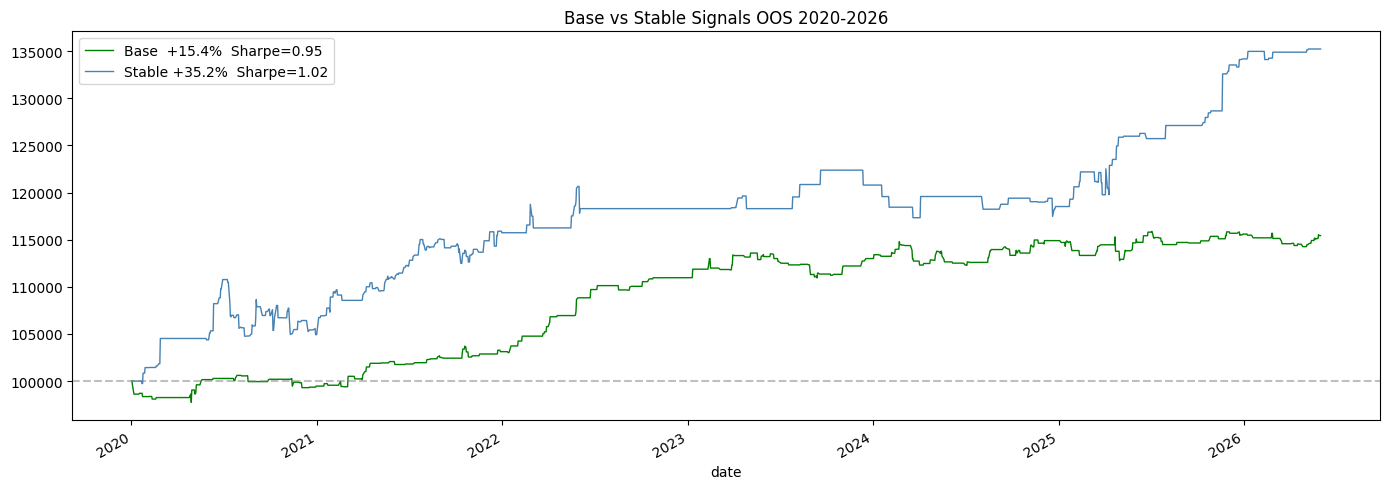

In [ ]:
#40 ── Бэктест стабильных сигналов ───────────────────────────
STABLE_LONG = [
    ('outside_range_above',  '9.0_0',  9),
    ('outside_range_above',  '8.0',    8),
    ('outside_range_below',  '9.0_1',  9),
    ('outside_va_below_poc', '9.0_1',  9),
    ('outside_va_below_poc', '9.0_0',  9),
    ('inside_va_above_poc',  '11.0',  11),
    ('outside_va_above_poc', '3.0_1',  3),
    ('inside_va_below_poc',  '10.0_2',10),
    ('outside_range_above',  '0.0',    0),
]

STABLE_SHORT = [
    ('outside_range_above',  '12.0_0', 12),
    ('outside_range_below',  '5.0',     5),
    ('outside_va_below_poc', '8.0',     8),
]

bt_stable = full_df[full_df.index >= '2020-01-01'].copy()
bt_stable = bt_stable.dropna(subset=['sub_cluster_full', 'open_location',
                                      'gmm_cluster', 'open_px', 'close_px'])

high_conf_st = bt_stable['regime_confidence'] >= CONFIDENCE_THRESHOLD

long_st  = pd.Series(False, index=bt_stable.index)
short_st = pd.Series(False, index=bt_stable.index)

for loc, sub, gmm in STABLE_LONG:
    long_st |= (
        (bt_stable['open_location']    == loc) &
        (bt_stable['sub_cluster_full'] == sub) &
        (bt_stable['gmm_cluster']      == gmm) &
        high_conf_st
    )

for loc, sub, gmm in STABLE_SHORT:
    short_st |= (
        (bt_stable['open_location']    == loc) &
        (bt_stable['sub_cluster_full'] == sub) &
        (bt_stable['gmm_cluster']      == gmm) &
        high_conf_st
    )

long_t_st  = bt_stable[long_st].copy()
short_t_st = bt_stable[short_st].copy()

long_t_st['pnl']  = (long_t_st['close_px']  - long_t_st['open_px'])  / long_t_st['open_px']
short_t_st['pnl'] = (short_t_st['open_px']  - short_t_st['close_px']) / short_t_st['open_px']

long_wr_st  = (long_t_st['close_px']  > long_t_st['open_px']).mean()  * 100
short_wr_st = (short_t_st['close_px'] < short_t_st['open_px']).mean() * 100

log.info('=== STABLE ЛОНГ === WR=%.1f%%  n=%d  avg=%.3f%%',
         long_wr_st, len(long_t_st), long_t_st['pnl'].mean()*100)
log.info('=== STABLE ШОРТ === WR=%.1f%%  n=%d  avg=%.3f%%',
         short_wr_st, len(short_t_st), short_t_st['pnl'].mean()*100)

# Детальная статистика по каждому сигналу
log.info('\nДетализация лонг сигналов:')
for loc, sub, gmm in STABLE_LONG:
    mask = (
        (bt_stable['open_location']    == loc) &
        (bt_stable['sub_cluster_full'] == sub) &
        (bt_stable['gmm_cluster']      == gmm) &
        high_conf_st
    )
    sub_t = bt_stable[mask]
    if len(sub_t) < 3:
        continue
    wr  = (sub_t['close_px'] > sub_t['open_px']).mean() * 100
    avg = ((sub_t['close_px'] - sub_t['open_px']) / sub_t['open_px']).mean() * 100
    log.info('  %s × %s × %d: WR=%.1f%%  n=%d  avg=%.3f%%',
             sub, loc, gmm, wr, len(sub_t), avg)

log.info('\nДетализация шорт сигналов:')
for loc, sub, gmm in STABLE_SHORT:
    mask = (
        (bt_stable['open_location']    == loc) &
        (bt_stable['sub_cluster_full'] == sub) &
        (bt_stable['gmm_cluster']      == gmm) &
        high_conf_st
    )
    sub_t = bt_stable[mask]
    if len(sub_t) < 3:
        continue
    wr  = (sub_t['close_px'] < sub_t['open_px']).mean() * 100
    avg = ((sub_t['open_px'] - sub_t['close_px']) / sub_t['open_px']).mean() * 100
    log.info('  %s × %s × %d: ShortWR=%.1f%%  n=%d  avg=%.3f%%',
             sub, loc, gmm, wr, len(sub_t), avg)

# Equity curve
bt_stable['strat_ret_st'] = 0.0
bt_stable.loc[long_st,  'strat_ret_st'] = long_t_st['pnl']
bt_stable.loc[short_st, 'strat_ret_st'] = short_t_st['pnl']

cum_st   = (1 + bt_stable['strat_ret_st']).cumprod() * 100_000
cum_base = (1 + bt_df['strat_ret']).cumprod() * 100_000

tot_st = (cum_st.iloc[-1] / 100_000 - 1) * 100
act_st = bt_stable['strat_ret_st'][bt_stable['strat_ret_st'] != 0]
sh_st  = bt_stable['strat_ret_st'].mean() / bt_stable['strat_ret_st'].std() * np.sqrt(252) if bt_stable['strat_ret_st'].std() > 0 else 0
dd_st  = ((cum_st / cum_st.cummax()) - 1).min() * 100

log.info('\n=== STABLE КОМБО === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%',
         tot_st, sh_st, dd_st)
log.info('=== BASE        === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%',
         c_tot, c_sh, c_dd)

# График
fig, ax = plt.subplots(figsize=(14, 5))
cum_base.plot(ax=ax, color='green',     linewidth=1,
              label=f'Base  {c_tot:+.1f}%  Sharpe={c_sh:.2f}')
cum_st.plot(ax=ax,   color='steelblue', linewidth=1,
            label=f'Stable {tot_st:+.1f}%  Sharpe={sh_st:.2f}')
ax.axhline(100_000, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Base vs Stable Signals OOS 2020-2026')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/stable_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

15:37:37  INFO      Multiplier распределение:
pos_multiplier
0.3    118
0.4     45
0.5     64
0.6     47
0.7     53
0.8    291
0.9    111
1.0    257
1.1     99
1.2    205
1.3    139
1.5    208
15:37:37  INFO      Средний multiplier: 0.97
15:37:37  INFO      === SIZED ЛОНГ === WR=70.3%  n=175  avg_pnl=0.1251%
15:37:37  INFO      === SIZED ШОРТ === WR=61.0%  n=41  avg_pnl=0.1574%
15:37:37  INFO      === SIZED КОМБО  === Return:31.84%  Sharpe:0.94  MaxDD:-6.06%
15:37:37  INFO      === STABLE КОМБО === Return:35.23%  Sharpe:1.02  MaxDD:-5.43%
15:37:37  INFO      === BASE         === Return:15.43%  Sharpe:0.95  MaxDD:-2.33%
15:37:37  INFO      
Детализация лонг с sizing:
15:37:37  INFO        9.0_0 × outside_range_above × 9: WR=72.4%  n=29  avg_mult=1.08
15:37:37  INFO        8.0 × outside_range_above × 8: WR=59.5%  n=37  avg_mult=1.18
15:37:37  INFO        9.0_1 × outside_range_below × 9: WR=70.0%  n=10  avg_mult=0.91
15:37:37  INFO        9.0_1 × outside_va_below_poc × 9: WR=81.8%  n=11  

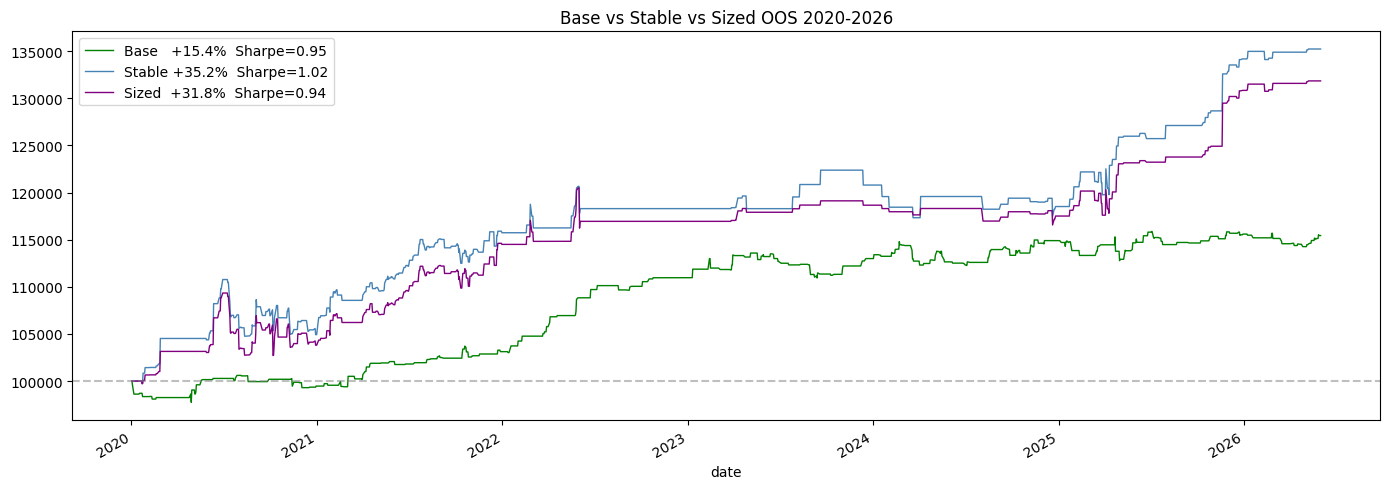

15:37:37  INFO      Long  avg total_mult: 1.06
15:37:37  INFO      Short avg total_mult: 0.73
15:37:37  INFO      === SLOT+STREAK === Return:63.70%  Sharpe:1.57  MaxDD:-5.43%
15:37:37  INFO      === STABLE      === Return:35.23%  Sharpe:1.02  MaxDD:-5.43%
15:37:37  INFO      === BASE        === Return:15.43%  Sharpe:0.95  MaxDD:-2.33%


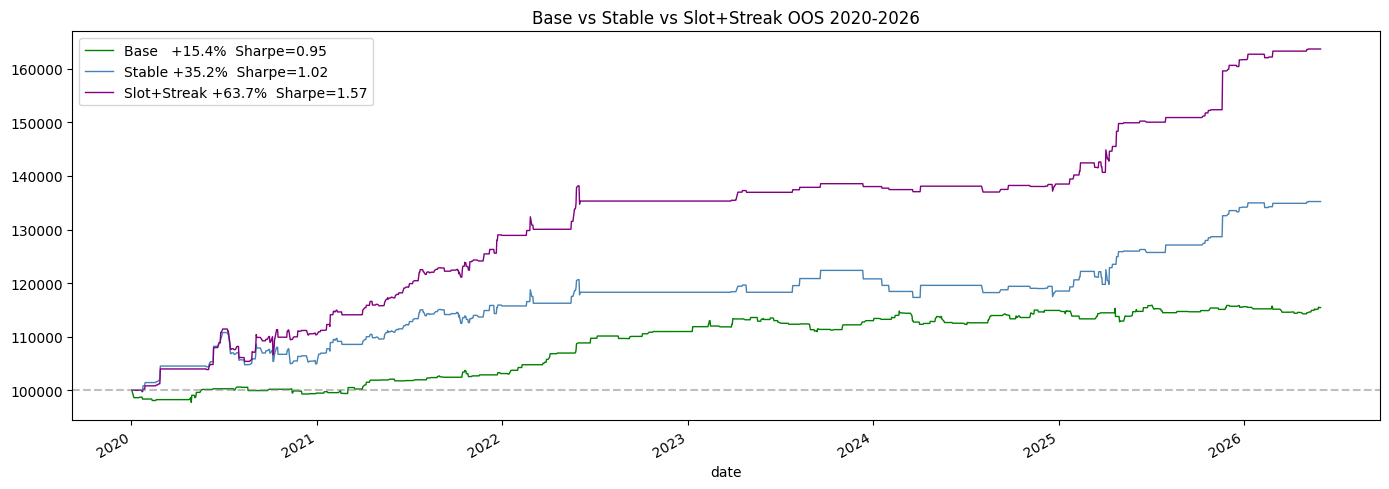

In [ ]:
#44 ── Position Sizing по Streak ─────────────────────────────

# Таблица множителей на основе оптимальных streak
STREAK_MULTIPLIERS = {
    'Stable_Bull': {
        1: 0.8, 2: 0.9, 3: 1.0, 5: 1.1, 7: 1.2, 10: 0.5, 13: 1.3
    },
    'Tradeable_Risk': {
        1: 0.8, 2: 1.0, 3: 1.2, 5: 0.8, 7: 0.6, 9: 1.5, 10: 1.5
    },
    'Risk_Long': {
        1: 1.1, 2: 1.0, 3: 0.9, 5: 0.7, 7: 0.8, 10: 1.0, 14: 1.2
    },
    'Expansion': {
        1: 0.8, 2: 1.2, 3: 1.2, 5: 0.8, 7: 1.5, 8: 0.5
    },
    'Bear_Elevated': {
        1: 0.7, 2: 0.5, 3: 0.8, 4: 1.2, 5: 1.2, 7: 0.8, 10: 1.3
    },
    'Crisis': {
    1: 1.0,  # шортим полным размером
    2: 1.0,  # шортим
    3: 0.8,
    5: 1.2,  # разворот — лонг
    8: 1.5
    },
    'Transition': {
        1: 0.3, 2: 0.4, 3: 0.6, 5: 1.2, 7: 0.4
    },
    'Compression': {
        1: 0.8, 2: 1.0, 3: 0.9, 5: 0.7, 7: 0.8
    },
    'Commodity_Driven': {
        1: 0.9
    },
}

def get_streak_multiplier(group, streak_val):
    """Возвращает множитель для позиции на основе группы и streak."""
    if group not in STREAK_MULTIPLIERS:
        return 1.0
    thresholds = STREAK_MULTIPLIERS[group]
    # Берём ближайший порог снизу
    applicable = {k: v for k, v in thresholds.items() if k <= streak_val}
    if not applicable:
        return 0.5
    return applicable[max(applicable.keys())]

# Добавляем multiplier в bt_stable
bt_stable['streak_group'] = es_days['cluster_group'].reindex(bt_stable.index)
bt_stable['streak_day'] = bt_stable.apply(
    lambda row: es_days.loc[row.name, f'streak_{row["streak_group"].lower()}']
    if pd.notna(row['streak_group']) and
       f'streak_{row["streak_group"].lower()}' in es_days.columns
    else 1,
    axis=1
)
bt_stable['pos_multiplier'] = bt_stable.apply(
    lambda row: get_streak_multiplier(row['streak_group'], row['streak_day']),
    axis=1
)

log.info('Multiplier распределение:\n%s',
         bt_stable['pos_multiplier'].value_counts().sort_index().to_string())
log.info('Средний multiplier: %.2f', bt_stable['pos_multiplier'].mean())

# ── Бэктест с position sizing ─────────────────────────────
long_t_sized  = bt_stable[long_st].copy()
short_t_sized = bt_stable[short_st].copy()

long_t_sized['pnl_base'] = (
    long_t_sized['close_px'] - long_t_sized['open_px']
) / long_t_sized['open_px']

short_t_sized['pnl_base'] = (
    short_t_sized['open_px'] - short_t_sized['close_px']
) / short_t_sized['open_px']

# Применяем multiplier
long_t_sized['pnl'] = (
    long_t_sized['pnl_base'] *
    bt_stable.loc[long_t_sized.index, 'pos_multiplier']
)
short_t_sized['pnl'] = (
    short_t_sized['pnl_base'] *
    bt_stable.loc[short_t_sized.index, 'pos_multiplier']
)

long_wr_sz  = (long_t_sized['close_px'] > long_t_sized['open_px']).mean() * 100
short_wr_sz = (short_t_sized['close_px'] < short_t_sized['open_px']).mean() * 100

log.info('=== SIZED ЛОНГ === WR=%.1f%%  n=%d  avg_pnl=%.4f%%',
         long_wr_sz, len(long_t_sized), long_t_sized['pnl'].mean()*100)
log.info('=== SIZED ШОРТ === WR=%.1f%%  n=%d  avg_pnl=%.4f%%',
         short_wr_sz, len(short_t_sized), short_t_sized['pnl'].mean()*100)

# Equity curve
bt_stable['strat_ret_sized'] = 0.0
bt_stable.loc[long_st,  'strat_ret_sized'] = long_t_sized['pnl']
bt_stable.loc[short_st, 'strat_ret_sized'] = short_t_sized['pnl']

cum_sized = (1 + bt_stable['strat_ret_sized']).cumprod() * 100_000
cum_base  = (1 + bt_df['strat_ret']).cumprod() * 100_000
cum_st_   = (1 + bt_stable['strat_ret_st']).cumprod() * 100_000

tot_sz = (cum_sized.iloc[-1] / 100_000 - 1) * 100
act_sz = bt_stable['strat_ret_sized'][bt_stable['strat_ret_sized'] != 0]
sh_sz  = bt_stable['strat_ret_sized'].mean() / bt_stable['strat_ret_sized'].std() * np.sqrt(252) if bt_stable['strat_ret_sized'].std() > 0 else 0
dd_sz  = ((cum_sized / cum_sized.cummax()) - 1).min() * 100

log.info('=== SIZED КОМБО  === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%',
         tot_sz, sh_sz, dd_sz)
log.info('=== STABLE КОМБО === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%',
         tot_st, sh_st, dd_st)
log.info('=== BASE         === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%',
         c_tot, c_sh, c_dd)

# Детализация по сигналам с multiplier
log.info('\nДетализация лонг с sizing:')
for loc, sub, gmm in STABLE_LONG:
    mask = (
        (bt_stable['open_location']    == loc) &
        (bt_stable['sub_cluster_full'] == sub) &
        (bt_stable['gmm_cluster']      == gmm) &
        high_conf_st
    )
    sub_t = bt_stable[mask]
    if len(sub_t) < 3:
        continue
    wr    = (sub_t['close_px'] > sub_t['open_px']).mean() * 100
    avg_m = sub_t['pos_multiplier'].mean()
    pnl   = (long_t_sized.loc[long_t_sized.index.isin(sub_t.index), 'pnl']
             .mean() * 100 if len(sub_t) > 0 else 0)
    log.info('  %s × %s × %d: WR=%.1f%%  n=%d  avg_mult=%.2f',
             sub, loc, gmm, wr, len(sub_t), avg_m)

# График
fig, ax = plt.subplots(figsize=(14, 5))
cum_base.plot(ax=ax,  color='green',     linewidth=1,
              label=f'Base   {c_tot:+.1f}%  Sharpe={c_sh:.2f}')
cum_st_.plot(ax=ax,   color='steelblue', linewidth=1,
             label=f'Stable {tot_st:+.1f}%  Sharpe={sh_st:.2f}')
cum_sized.plot(ax=ax, color='purple',    linewidth=1,
               label=f'Sized  {tot_sz:+.1f}%  Sharpe={sh_sz:.2f}')
ax.axhline(100_000, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Base vs Stable vs Sized OOS 2020-2026')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/sized_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

# ── High/Low Slot мультипликатор ─────────────────────────
# Добавляем high_slot и low_slot в bt_stable
bt_stable['high_slot'] = es_days['high_slot'].reindex(bt_stable.index)
bt_stable['low_slot']  = es_days['low_slot'].reindex(bt_stable.index)

# Slot multiplier — поздний хай/лой = momentum подтверждение
def get_slot_multiplier(row, direction='long'):
    slot = row['high_slot'] if direction == 'long' else row['low_slot']
    if pd.isna(slot):
        return 1.0
    slot = int(slot)
    if direction == 'long':
        # Хай формируется поздно → momentum вверх → усиливаем лонг
        if slot >= 11:   return 1.3  # 15:00-15:30 ET
        elif slot >= 9:  return 1.1  # 14:00-14:30 ET
        elif slot <= 2:  return 0.7  # 09:30-10:30 ET — ранний хай = разворот
        else:            return 1.0
    else:
        # Лой формируется поздно → momentum вниз → усиливаем шорт
        if slot >= 11:   return 1.3
        elif slot >= 9:  return 1.1
        elif slot <= 2:  return 0.7
        else:            return 1.0

# Применяем slot multiplier поверх streak multiplier
long_t_slot  = bt_stable[long_st].copy()
short_t_slot = bt_stable[short_st].copy()

long_t_slot['pnl_base']  = (long_t_slot['close_px']  - long_t_slot['open_px'])  / long_t_slot['open_px']
short_t_slot['pnl_base'] = (short_t_slot['open_px']  - short_t_slot['close_px']) / short_t_slot['open_px']

long_t_slot['streak_mult'] = bt_stable.loc[long_t_slot.index,  'pos_multiplier']
short_t_slot['streak_mult']= bt_stable.loc[short_t_slot.index, 'pos_multiplier']

long_t_slot['slot_mult']  = long_t_slot.apply(
    lambda r: get_slot_multiplier(r, 'long'), axis=1)
short_t_slot['slot_mult'] = short_t_slot.apply(
    lambda r: get_slot_multiplier(r, 'short'), axis=1)

# Итоговый множитель = streak × slot (с cap 2.0)
long_t_slot['total_mult']  = (long_t_slot['streak_mult']  * long_t_slot['slot_mult']).clip(0, 2.0)
short_t_slot['total_mult'] = (short_t_slot['streak_mult'] * short_t_slot['slot_mult']).clip(0, 2.0)

long_t_slot['pnl']  = long_t_slot['pnl_base']  * long_t_slot['total_mult']
short_t_slot['pnl'] = short_t_slot['pnl_base'] * short_t_slot['total_mult']

log.info('Long  avg total_mult: %.2f', long_t_slot['total_mult'].mean())
log.info('Short avg total_mult: %.2f', short_t_slot['total_mult'].mean())

# Equity curve
bt_stable['strat_ret_slot'] = 0.0
bt_stable.loc[long_st,  'strat_ret_slot'] = long_t_slot['pnl']
bt_stable.loc[short_st, 'strat_ret_slot'] = short_t_slot['pnl']

cum_slot = (1 + bt_stable['strat_ret_slot']).cumprod() * 100_000
tot_slot = (cum_slot.iloc[-1] / 100_000 - 1) * 100
act_slot = bt_stable['strat_ret_slot'][bt_stable['strat_ret_slot'] != 0]
sh_slot  = bt_stable['strat_ret_slot'].mean() / bt_stable['strat_ret_slot'].std() * np.sqrt(252) if bt_stable['strat_ret_slot'].std() > 0 else 0
dd_slot  = ((cum_slot / cum_slot.cummax()) - 1).min() * 100

log.info('=== SLOT+STREAK === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%', tot_slot, sh_slot, dd_slot)
log.info('=== STABLE      === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%', tot_st,   sh_st,   dd_st)
log.info('=== BASE        === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%', c_tot,    c_sh,    c_dd)

# График
fig, ax = plt.subplots(figsize=(14, 5))
cum_base.plot(ax=ax,  color='green',     linewidth=1, label=f'Base   {c_tot:+.1f}%  Sharpe={c_sh:.2f}')
cum_st_.plot(ax=ax,   color='steelblue', linewidth=1, label=f'Stable {tot_st:+.1f}%  Sharpe={sh_st:.2f}')
cum_slot.plot(ax=ax,  color='purple',    linewidth=1, label=f'Slot+Streak {tot_slot:+.1f}%  Sharpe={sh_slot:.2f}')
ax.axhline(100_000, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Base vs Stable vs Slot+Streak OOS 2020-2026')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/slot_streak_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#45 Вероятность позднего хая (slot >= 10) по режиму × open_location
late_high_prob = (es_days.groupby(['cluster_group', 'open_location'])
    .apply(lambda x: pd.Series({
        'late_high_prob': (x['high_slot'] >= 10).mean(),
        'late_low_prob':  (x['low_slot'] >= 10).mean(),
        'early_high_prob':(x['high_slot'] <= 2).mean(),
        'early_low_prob': (x['low_slot'] <= 2).mean(),
        'mean_high_slot': x['high_slot'].mean(),
        'mean_low_slot':  x['low_slot'].mean(),
        'count': len(x),
    }), include_groups=False)
    .query('count >= 20')
    .sort_values('late_high_prob', ascending=False))

log.info('Вероятность позднего хая по группам:\n%s',
         late_high_prob.to_string())

15:37:37  INFO      Вероятность позднего хая по группам:
                                       late_high_prob  late_low_prob  early_high_prob  early_low_prob  mean_high_slot  mean_low_slot  count
cluster_group    open_location                                                                                                             
Crisis           outside_va_above_poc        0.465116       0.186047         0.255814        0.511628        6.930233       4.325581   43.0
Bear_Elevated    inside_va_above_poc         0.413793       0.206897         0.310345        0.482759        6.344828       4.344828   29.0
                 inside_va_below_poc         0.407407       0.185185         0.185185        0.518519        7.555556       3.777778   27.0
                 outside_range_above         0.395349       0.232558         0.255814        0.558140        6.860465       3.976744   43.0
Stable_Bull      outside_range_above         0.394850       0.180258         0.351931        0.476395  

15:37:37  INFO      Long  avg total_mult: 1.25  slot_mult: 1.21
15:37:37  INFO      Short avg total_mult: 0.90  slot_mult: 1.20
15:37:37  INFO      === PRED SLOT+STREAK === Return:43.77%  Sharpe:1.01  MaxDD:-6.60%
15:37:37  INFO      === STABLE           === Return:35.23%  Sharpe:1.02  MaxDD:-5.43%
15:37:37  INFO      === BASE             === Return:15.43%  Sharpe:0.95  MaxDD:-2.33%
15:37:37  INFO      
Детализация лонг с предиктивным sizing:
15:37:37  INFO        9.0_0 × outside_range_above × 9: WR=72.4%  n=29  avg_mult=1.30  slot_mult=1.20
15:37:37  INFO        8.0 × outside_range_above × 8: WR=59.5%  n=37  avg_mult=1.41  slot_mult=1.20
15:37:37  INFO        9.0_1 × outside_range_below × 9: WR=70.0%  n=10  avg_mult=1.09  slot_mult=1.20
15:37:37  INFO        9.0_1 × outside_va_below_poc × 9: WR=81.8%  n=11  avg_mult=1.32  slot_mult=1.40
15:37:37  INFO        9.0_0 × outside_va_below_poc × 9: WR=83.3%  n=6  avg_mult=1.46  slot_mult=1.20
15:37:37  INFO        11.0 × inside_va_above_poc 

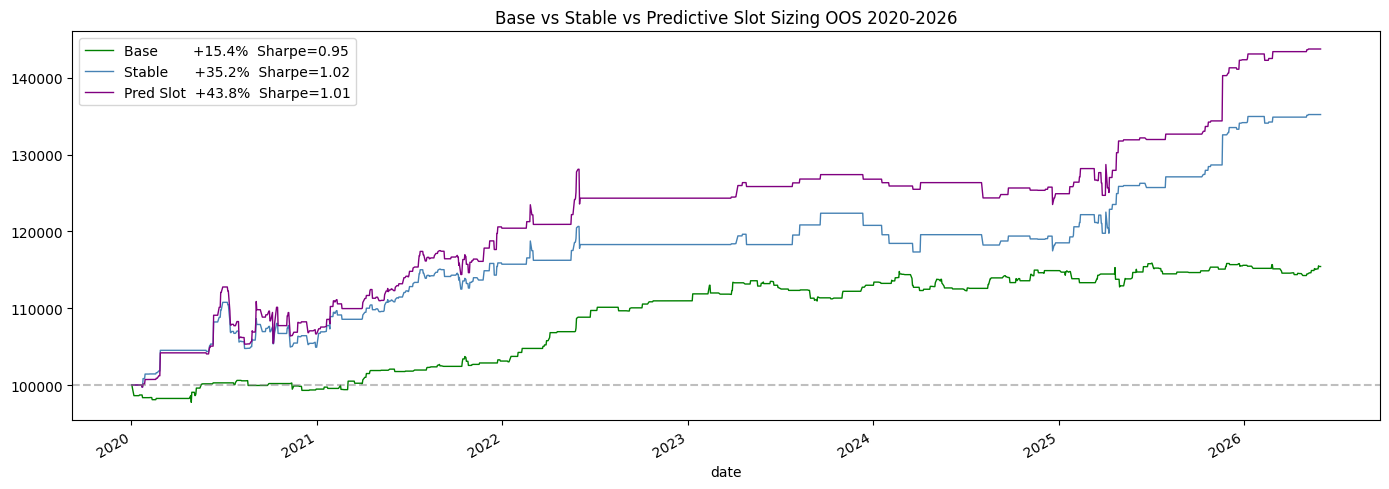

15:37:37  INFO      Short avg total_mult: 0.99  streak: 0.81  slot: 1.31
15:37:37  INFO      
Детализация шорт с новым sizing:
15:37:37  INFO        12.0_0 × outside_range_above × 12: ShortWR=57.9%  n=19  avg_mult=0.58  slot=1.50
15:37:37  INFO        5.0 × outside_range_below × 5: ShortWR=63.6%  n=11  avg_mult=1.49  slot=1.30
15:37:37  INFO        8.0 × outside_va_below_poc × 8: ShortWR=63.6%  n=11  avg_mult=1.19  slot=1.00
15:37:37  INFO      === UPDATED PRED === Return:46.52%  Sharpe:1.01  MaxDD:-6.60%
15:37:37  INFO      === STABLE       === Return:35.23%  Sharpe:1.02  MaxDD:-5.43%


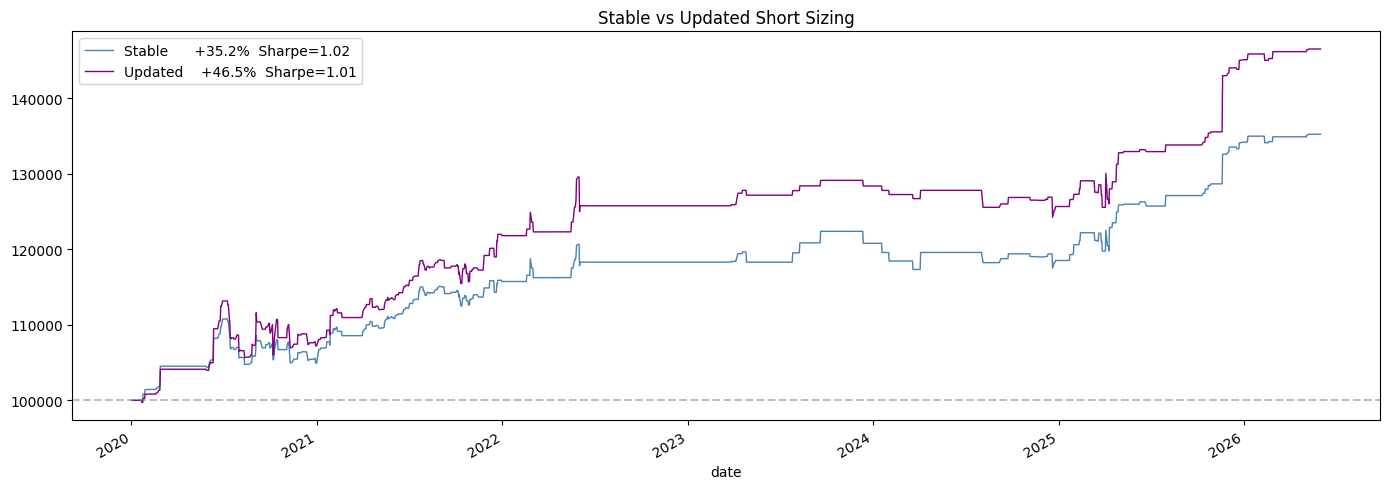

In [ ]:
#46 ── Предиктивный slot multiplier ─────────────────────────

# Таблица вероятностей на основе группы × open_location
slot_prob_table = (es_days.groupby(['cluster_group', 'open_location'])
    .apply(lambda x: pd.Series({
        'late_high_prob':  (x['high_slot'] >= 10).mean(),
        'early_low_prob':  (x['low_slot']  <= 2).mean(),
        'early_high_prob': (x['high_slot'] <= 2).mean(),
        'late_low_prob':   (x['low_slot']  >= 10).mean(),
        'count': len(x),
    }), include_groups=False)
    .query('count >= 20'))

def get_predictive_slot_mult(group, loc, direction='long'):
    """
    Предиктивный multiplier на основе вероятности
    формирования экстремума — известен на открытии.
    """
    key = (group, loc)
    if key not in slot_prob_table.index:
        return 1.0

    row = slot_prob_table.loc[key]

    if direction == 'long':
        # Поздний хай → momentum → усиливаем
        if row['late_high_prob'] >= 0.42:   return 1.4
        elif row['late_high_prob'] >= 0.37: return 1.2
        # Ранний лой → лонг от лоя весь день
        if row['early_low_prob'] >= 0.55:   return 1.4
        elif row['early_low_prob'] >= 0.50: return 1.2
        # Ранний хай → разворот → уменьшаем
        if row['early_high_prob'] >= 0.50:  return 0.6
        elif row['early_high_prob'] >= 0.42:return 0.8
        return 1.0

    else:  # short
        # Поздний лой → momentum вниз → усиливаем шорт
        if row['late_low_prob'] >= 0.40:    return 1.4
        elif row['late_low_prob'] >= 0.33:  return 1.2
        # Ранний хай → разворот вниз → усиливаем шорт
        if row['early_high_prob'] >= 0.45:  return 1.3
        # Ранний лой → разворот вверх → уменьшаем шорт
        if row['early_low_prob'] >= 0.55:   return 0.6
        return 1.0

# Применяем к сигналам
long_t_pred  = bt_stable[long_st].copy()
short_t_pred = bt_stable[short_st].copy()

long_t_pred['pnl_base']  = (long_t_pred['close_px']  - long_t_pred['open_px'])  / long_t_pred['open_px']
short_t_pred['pnl_base'] = (short_t_pred['open_px']  - short_t_pred['close_px']) / short_t_pred['open_px']

long_t_pred['streak_mult'] = bt_stable.loc[long_t_pred.index,  'pos_multiplier']
short_t_pred['streak_mult']= bt_stable.loc[short_t_pred.index, 'pos_multiplier']

long_t_pred['slot_mult'] = long_t_pred.apply(
    lambda r: get_predictive_slot_mult(
        r.get('streak_group', bt_stable.loc[r.name, 'streak_group']),
        r['open_location'], 'long'), axis=1)

short_t_pred['slot_mult'] = short_t_pred.apply(
    lambda r: get_predictive_slot_mult(
        r.get('streak_group', bt_stable.loc[r.name, 'streak_group']),
        r['open_location'], 'short'), axis=1)

long_t_pred['total_mult']  = (long_t_pred['streak_mult']  * long_t_pred['slot_mult']).clip(0, 2.0)
short_t_pred['total_mult'] = (short_t_pred['streak_mult'] * short_t_pred['slot_mult']).clip(0, 2.0)

long_t_pred['pnl']  = long_t_pred['pnl_base']  * long_t_pred['total_mult']
short_t_pred['pnl'] = short_t_pred['pnl_base'] * short_t_pred['total_mult']

log.info('Long  avg total_mult: %.2f  slot_mult: %.2f',
         long_t_pred['total_mult'].mean(), long_t_pred['slot_mult'].mean())
log.info('Short avg total_mult: %.2f  slot_mult: %.2f',
         short_t_pred['total_mult'].mean(), short_t_pred['slot_mult'].mean())

# Equity curve
bt_stable['strat_ret_pred'] = 0.0
bt_stable.loc[long_st,  'strat_ret_pred'] = long_t_pred['pnl']
bt_stable.loc[short_st, 'strat_ret_pred'] = short_t_pred['pnl']

cum_pred = (1 + bt_stable['strat_ret_pred']).cumprod() * 100_000
tot_pred = (cum_pred.iloc[-1] / 100_000 - 1) * 100
act_pred = bt_stable['strat_ret_pred'][bt_stable['strat_ret_pred'] != 0]
sh_pred  = bt_stable['strat_ret_pred'].mean() / bt_stable['strat_ret_pred'].std() * np.sqrt(252) if bt_stable['strat_ret_pred'].std() > 0 else 0
dd_pred  = ((cum_pred / cum_pred.cummax()) - 1).min() * 100

log.info('=== PRED SLOT+STREAK === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%',
         tot_pred, sh_pred, dd_pred)
log.info('=== STABLE           === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%',
         tot_st,   sh_st,   dd_st)
log.info('=== BASE             === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%',
         c_tot,    c_sh,    c_dd)

# Детализация по сигналам
log.info('\nДетализация лонг с предиктивным sizing:')
for loc, sub, gmm in STABLE_LONG:
    mask = (
        (bt_stable['open_location']    == loc) &
        (bt_stable['sub_cluster_full'] == sub) &
        (bt_stable['gmm_cluster']      == gmm) &
        high_conf_st
    )
    sub_t = long_t_pred[long_t_pred.index.isin(bt_stable[mask].index)]
    if len(sub_t) < 3:
        continue
    log.info('  %s × %s × %d: WR=%.1f%%  n=%d  avg_mult=%.2f  slot_mult=%.2f',
             sub, loc, gmm,
             (bt_stable.loc[mask, 'close_px'] > bt_stable.loc[mask, 'open_px']).mean()*100,
             len(sub_t),
             sub_t['total_mult'].mean(),
             sub_t['slot_mult'].mean())

# График
fig, ax = plt.subplots(figsize=(14, 5))
cum_base.plot(ax=ax, color='green',     linewidth=1,
              label=f'Base        {c_tot:+.1f}%  Sharpe={c_sh:.2f}')
cum_st_.plot(ax=ax,  color='steelblue', linewidth=1,
             label=f'Stable      {tot_st:+.1f}%  Sharpe={sh_st:.2f}')
cum_pred.plot(ax=ax, color='purple',    linewidth=1,
              label=f'Pred Slot  {tot_pred:+.1f}%  Sharpe={sh_pred:.2f}')
ax.axhline(100_000, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Base vs Stable vs Predictive Slot Sizing OOS 2020-2026')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/pred_slot_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Обновлённая шорт логика ───────────────────────────────

# 1. Исправляем Crisis multiplier
STREAK_MULTIPLIERS['Crisis'] = {
    1: 1.2,   # шортим агрессивно — первые дни самые сильные
    2: 1.2,
    3: 1.0,
    4: 0.8,
    5: 1.3,   # разворот → лонг
    6: 1.3,
    7: 0.8,
    8: 1.5,   # второй импульс лонг
}

# 2. Обновляем шорт slot логику
def get_predictive_slot_mult_short(group, loc):
    key = (group, loc)
    if key not in slot_prob_table.index:
        return 1.0

    row = slot_prob_table.loc[key]

    # Ранний хай → разворот вниз → усиливаем шорт
    if row['early_high_prob'] >= 0.50:   return 1.5
    elif row['early_high_prob'] >= 0.43: return 1.3

    # Поздний лой → momentum вниз → усиливаем шорт
    if row['late_low_prob'] >= 0.38:     return 1.3
    elif row['late_low_prob'] >= 0.32:   return 1.1

    # Ранний лой → разворот вверх → уменьшаем шорт
    if row['early_low_prob'] >= 0.55:    return 0.5
    elif row['early_low_prob'] >= 0.48:  return 0.7

    # Поздний хай → momentum вверх → плохо для шорта
    if row['late_high_prob'] >= 0.42:    return 0.6

    return 1.0

# Пересчитываем шорт
short_t_pred['slot_mult'] = short_t_pred.apply(
    lambda r: get_predictive_slot_mult_short(
        bt_stable.loc[r.name, 'streak_group'],
        r['open_location']), axis=1)

# Пересчитываем streak_mult для шорта с обновлённым Crisis
short_t_pred['streak_mult'] = short_t_pred.apply(
    lambda r: get_streak_multiplier(
        bt_stable.loc[r.name, 'streak_group'],
        bt_stable.loc[r.name, 'streak_day']), axis=1)

short_t_pred['total_mult'] = (
    short_t_pred['streak_mult'] * short_t_pred['slot_mult']
).clip(0, 2.0)

short_t_pred['pnl'] = short_t_pred['pnl_base'] * short_t_pred['total_mult']

log.info('Short avg total_mult: %.2f  streak: %.2f  slot: %.2f',
         short_t_pred['total_mult'].mean(),
         short_t_pred['streak_mult'].mean(),
         short_t_pred['slot_mult'].mean())

# Детализация шорт сигналов
log.info('\nДетализация шорт с новым sizing:')
for loc, sub, gmm in STABLE_SHORT:
    mask = (
        (bt_stable['open_location']    == loc) &
        (bt_stable['sub_cluster_full'] == sub) &
        (bt_stable['gmm_cluster']      == gmm) &
        high_conf_st
    )
    sub_t = short_t_pred[short_t_pred.index.isin(bt_stable[mask].index)]
    if len(sub_t) < 3:
        continue
    short_wr = (bt_stable.loc[mask, 'close_px'] < bt_stable.loc[mask, 'open_px']).mean()*100
    log.info('  %s × %s × %d: ShortWR=%.1f%%  n=%d  avg_mult=%.2f  slot=%.2f',
             sub, loc, gmm, short_wr, len(sub_t),
             sub_t['total_mult'].mean(),
             sub_t['slot_mult'].mean())

# Пересчитываем equity curve
bt_stable['strat_ret_pred'] = 0.0
bt_stable.loc[long_st,  'strat_ret_pred'] = long_t_pred['pnl']
bt_stable.loc[short_st, 'strat_ret_pred'] = short_t_pred['pnl']

cum_pred = (1 + bt_stable['strat_ret_pred']).cumprod() * 100_000
tot_pred = (cum_pred.iloc[-1] / 100_000 - 1) * 100
act_pred = bt_stable['strat_ret_pred'][bt_stable['strat_ret_pred'] != 0]
sh_pred  = bt_stable['strat_ret_pred'].mean() / bt_stable['strat_ret_pred'].std() * np.sqrt(252) if bt_stable['strat_ret_pred'].std() > 0 else 0
dd_pred  = ((cum_pred / cum_pred.cummax()) - 1).min() * 100

log.info('=== UPDATED PRED === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%',
         tot_pred, sh_pred, dd_pred)
log.info('=== STABLE       === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%',
         tot_st, sh_st, dd_st)

fig, ax = plt.subplots(figsize=(14, 5))
cum_st_.plot(ax=ax,  color='steelblue', linewidth=1,
             label=f'Stable      {tot_st:+.1f}%  Sharpe={sh_st:.2f}')
cum_pred.plot(ax=ax, color='purple',    linewidth=1,
              label=f'Updated    {tot_pred:+.1f}%  Sharpe={sh_pred:.2f}')
ax.axhline(100_000, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Stable vs Updated Short Sizing')
ax.legend()
plt.tight_layout()
plt.show()

15:37:37  INFO      Short avg total_mult: 0.99  streak: 0.81  slot: 1.31
15:37:37  INFO      
Детализация шорт с новым sizing:
15:37:37  INFO        12.0_0 × outside_range_above × 12: ShortWR=57.9%  n=19  avg_mult=0.58  slot=1.50
15:37:37  INFO        5.0 × outside_range_below × 5: ShortWR=63.6%  n=11  avg_mult=1.49  slot=1.30
15:37:37  INFO        8.0 × outside_va_below_poc × 8: ShortWR=63.6%  n=11  avg_mult=1.19  slot=1.00
15:37:37  INFO      === UPDATED PRED === Return:46.52%  Sharpe:1.01  MaxDD:-6.60%
15:37:37  INFO      === STABLE       === Return:35.23%  Sharpe:1.02  MaxDD:-5.43%


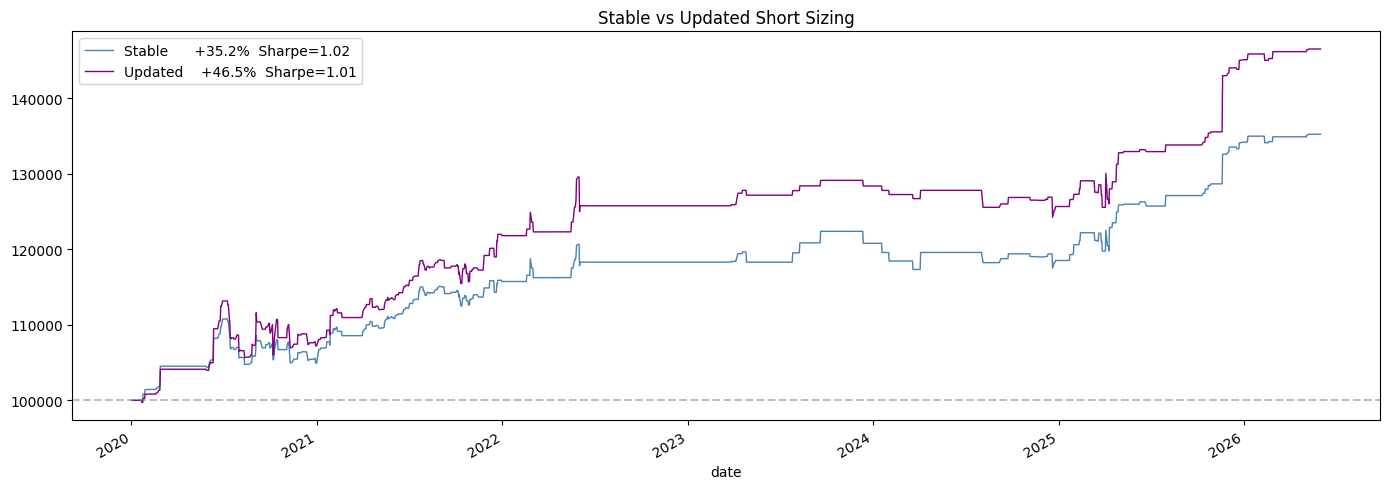

In [ ]:
#47 ── Обновлённая шорт логика ───────────────────────────────

# 1. Исправляем Crisis multiplier
STREAK_MULTIPLIERS['Crisis'] = {
    1: 1.2,   # шортим агрессивно — первые дни самые сильные
    2: 1.2,
    3: 1.0,
    4: 0.8,
    5: 1.3,   # разворот → лонг
    6: 1.3,
    7: 0.8,
    8: 1.5,   # второй импульс лонг
}

# 2. Обновляем шорт slot логику
def get_predictive_slot_mult_short(group, loc):
    key = (group, loc)
    if key not in slot_prob_table.index:
        return 1.0

    row = slot_prob_table.loc[key]

    # Ранний хай → разворот вниз → усиливаем шорт
    if row['early_high_prob'] >= 0.50:   return 1.5
    elif row['early_high_prob'] >= 0.43: return 1.3

    # Поздний лой → momentum вниз → усиливаем шорт
    if row['late_low_prob'] >= 0.38:     return 1.3
    elif row['late_low_prob'] >= 0.32:   return 1.1

    # Ранний лой → разворот вверх → уменьшаем шорт
    if row['early_low_prob'] >= 0.55:    return 0.5
    elif row['early_low_prob'] >= 0.48:  return 0.7

    # Поздний хай → momentum вверх → плохо для шорта
    if row['late_high_prob'] >= 0.42:    return 0.6

    return 1.0

# Пересчитываем шорт
short_t_pred['slot_mult'] = short_t_pred.apply(
    lambda r: get_predictive_slot_mult_short(
        bt_stable.loc[r.name, 'streak_group'],
        r['open_location']), axis=1)

# Пересчитываем streak_mult для шорта с обновлённым Crisis
short_t_pred['streak_mult'] = short_t_pred.apply(
    lambda r: get_streak_multiplier(
        bt_stable.loc[r.name, 'streak_group'],
        bt_stable.loc[r.name, 'streak_day']), axis=1)

short_t_pred['total_mult'] = (
    short_t_pred['streak_mult'] * short_t_pred['slot_mult']
).clip(0, 2.0)

short_t_pred['pnl'] = short_t_pred['pnl_base'] * short_t_pred['total_mult']

log.info('Short avg total_mult: %.2f  streak: %.2f  slot: %.2f',
         short_t_pred['total_mult'].mean(),
         short_t_pred['streak_mult'].mean(),
         short_t_pred['slot_mult'].mean())

# Детализация шорт сигналов
log.info('\nДетализация шорт с новым sizing:')
for loc, sub, gmm in STABLE_SHORT:
    mask = (
        (bt_stable['open_location']    == loc) &
        (bt_stable['sub_cluster_full'] == sub) &
        (bt_stable['gmm_cluster']      == gmm) &
        high_conf_st
    )
    sub_t = short_t_pred[short_t_pred.index.isin(bt_stable[mask].index)]
    if len(sub_t) < 3:
        continue
    short_wr = (bt_stable.loc[mask, 'close_px'] < bt_stable.loc[mask, 'open_px']).mean()*100
    log.info('  %s × %s × %d: ShortWR=%.1f%%  n=%d  avg_mult=%.2f  slot=%.2f',
             sub, loc, gmm, short_wr, len(sub_t),
             sub_t['total_mult'].mean(),
             sub_t['slot_mult'].mean())

# Пересчитываем equity curve
bt_stable['strat_ret_pred'] = 0.0
bt_stable.loc[long_st,  'strat_ret_pred'] = long_t_pred['pnl']
bt_stable.loc[short_st, 'strat_ret_pred'] = short_t_pred['pnl']

cum_pred = (1 + bt_stable['strat_ret_pred']).cumprod() * 100_000
tot_pred = (cum_pred.iloc[-1] / 100_000 - 1) * 100
act_pred = bt_stable['strat_ret_pred'][bt_stable['strat_ret_pred'] != 0]
sh_pred  = bt_stable['strat_ret_pred'].mean() / bt_stable['strat_ret_pred'].std() * np.sqrt(252) if bt_stable['strat_ret_pred'].std() > 0 else 0
dd_pred  = ((cum_pred / cum_pred.cummax()) - 1).min() * 100

log.info('=== UPDATED PRED === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%',
         tot_pred, sh_pred, dd_pred)
log.info('=== STABLE       === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%',
         tot_st, sh_st, dd_st)

fig, ax = plt.subplots(figsize=(14, 5))
cum_st_.plot(ax=ax,  color='steelblue', linewidth=1,
             label=f'Stable      {tot_st:+.1f}%  Sharpe={sh_st:.2f}')
cum_pred.plot(ax=ax, color='purple',    linewidth=1,
              label=f'Updated    {tot_pred:+.1f}%  Sharpe={sh_pred:.2f}')
ax.axhline(100_000, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Stable vs Updated Short Sizing')
ax.legend()
plt.tight_layout()
plt.show()

15:37:38  INFO      Event days in bt_df: 738
15:37:38  INFO      FOMC days: 50
15:37:38  INFO      NFP days: 75
15:37:38  INFO      Event filter: пропущено 9 сигналов, добавлено 35 NFP лонгов
15:37:38  INFO      === FILTERED ЛОНГ === WR=67.3%  n=208  avg=0.164%
15:37:38  INFO      === FILTERED ШОРТ === WR=26.4%  n=72  avg=-0.110%
15:37:38  INFO      === FILTERED КОМБО === Return:29.39%  Sharpe:1.17  MaxDD:-4.88%
15:37:38  INFO      === BASE КОМБО    === Return:15.43%  Sharpe:0.95  MaxDD:-2.33%


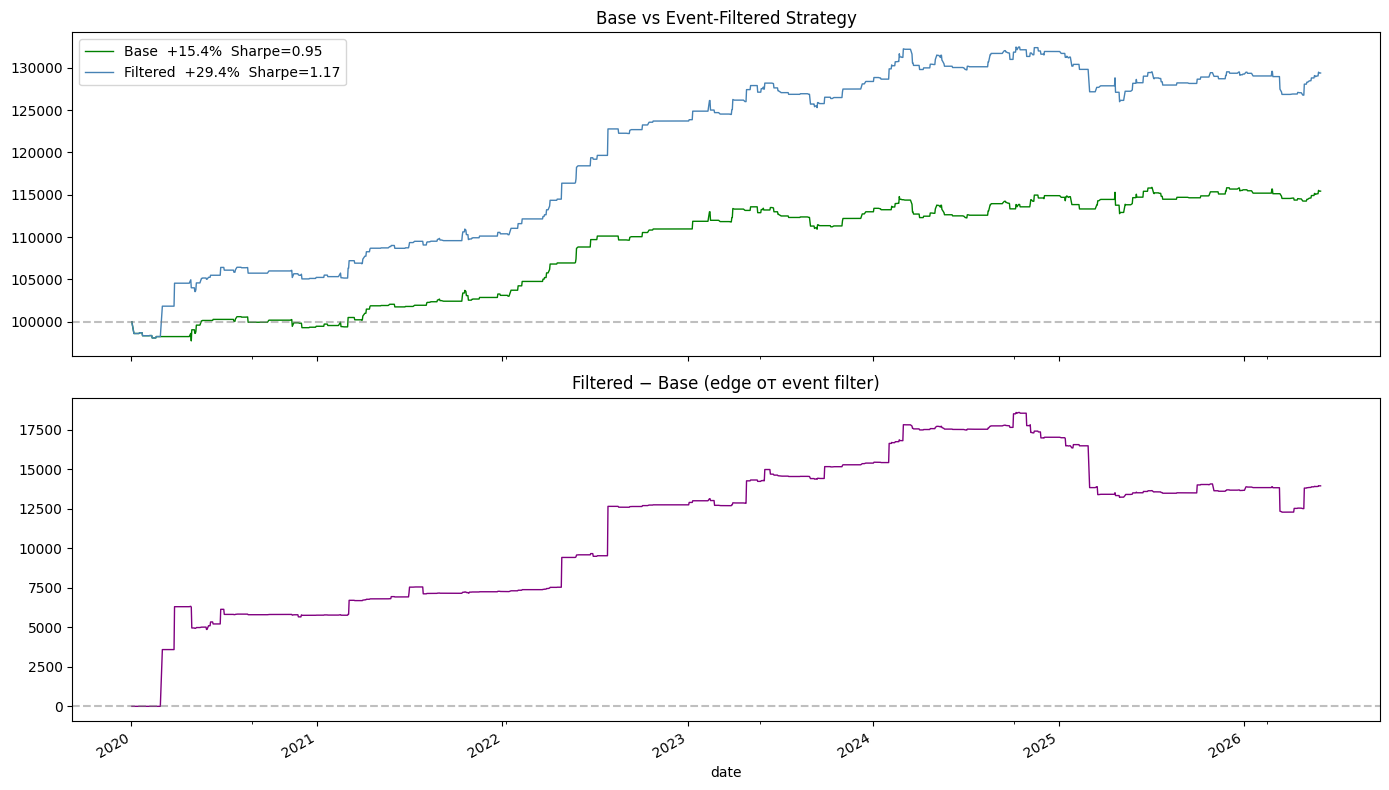

15:37:38  INFO      
=== СТАТИСТИКА В ДНИ СОБЫТИЙ (OOS 2020-2026) ===
15:37:38  INFO      NFP: n=75  WR=57.3%  | pos_surprise WR=85.7%(n=14)  neg_surprise WR=49.2%(n=59)
15:37:38  INFO        → наши сигналы: лонг WR=100.0%(n=11)  шорт WR=0.0%(n=0)
15:37:38  INFO      CPI: n=65  WR=47.7%  | pos_surprise WR=50.0%(n=28)  neg_surprise WR=45.7%(n=35)
15:37:38  INFO        → наши сигналы: лонг WR=57.1%(n=7)  шорт WR=33.3%(n=3)
15:37:38  INFO      FOMC: n=50  WR=48.0%  | pos_surprise WR=100.0%(n=1)  neg_surprise WR=0.0%(n=1)
15:37:38  INFO        → наши сигналы: лонг WR=100.0%(n=3)  шорт WR=100.0%(n=1)
15:37:38  INFO      GDP: n=74  WR=52.7%  | pos_surprise WR=38.7%(n=31)  neg_surprise WR=62.8%(n=43)
15:37:38  INFO        → наши сигналы: лонг WR=71.4%(n=7)  шорт WR=50.0%(n=2)
15:37:38  INFO      PCE: n=64  WR=54.7%  | pos_surprise WR=60.0%(n=20)  neg_surprise WR=52.3%(n=44)
15:37:38  INFO        → наши сигналы: лонг WR=57.1%(n=7)  шорт WR=0.0%(n=0)
15:37:38  INFO      Retail_Sales: n=58  WR=5

In [ ]:
#50 ── Rule-based Event Filter ───────────────────────────────
def apply_event_filter(bt_df, long_entries, short_entries):
    long_filtered  = long_entries.copy()
    short_filtered = short_entries.copy()

    for date, row in bt_df.iterrows():
        if not row.get('event_day', 0):
            continue

        evt  = row.get('event_type', None)
        surp = row.get('surprise_dir', 0)

        # FOMC → всегда пропускаем
        if evt == 'FOMC':
            long_filtered[date]  = False
            short_filtered[date] = False

        # CPI negative surprise → пропускаем лонг
        elif evt == 'CPI' and surp == -1:
            long_filtered[date] = False

        # NFP positive surprise → форсируем лонг если есть любой сигнал
        elif evt == 'NFP' and surp == 1:
            if row.get('open_location') in ['outside_range_above',
                                             'outside_va_above_poc',
                                             'inside_va_above_poc']:
                long_filtered[date] = True

        # ISM Services negative → пропускаем шорт
        elif evt == 'ISM_Services' and surp == -1:
            short_filtered[date] = False

        # GDP negative surprise → форсируем лонг
        elif evt == 'GDP' and surp == -1:
            if row.get('open_location') in ['outside_range_above',
                                     'outside_va_above_poc',
                                     'inside_va_above_poc']:
                long_filtered[date] = True

        # ISM_Mfg negative surprise → форсируем лонг
        elif evt == 'ISM_Mfg' and surp == -1:
            if row.get('open_location') in ['outside_range_above',
                                     'outside_va_above_poc']:
                long_filtered[date] = True

    return long_filtered, short_filtered

# Джойним event флаги
event_cols = ['event_day', 'event_type', 'surprise_dir', 
              'event_nfp', 'event_cpi', 'event_fomc',
              'event_gdp', 'event_pce', 'event_retail_sales', 'event_ism_mfg']

for col in event_cols:
    if col in es_days.columns:
        bt_df[col] = es_days[col].reindex(bt_df.index)

bt_df['event_day']    = bt_df['event_day'].fillna(0).astype(int)
bt_df['surprise_dir'] = bt_df['surprise_dir'].fillna(0)
bt_df['event_type']   = bt_df['event_type'].fillna('')

log.info('Event days in bt_df: %d', bt_df['event_day'].sum())
log.info('FOMC days: %d', (bt_df['event_type'] == 'FOMC').sum())
log.info('NFP days: %d',  (bt_df['event_type'] == 'NFP').sum())

long_filtered, short_filtered = apply_event_filter(
    bt_df, long_entries, short_entries)

# Статистика фильтра
skipped = ((long_entries & ~long_filtered) |
           (short_entries & ~short_filtered)).sum()
added   = (~long_entries & long_filtered).sum()
log.info('Event filter: пропущено %d сигналов, добавлено %d NFP лонгов',
         skipped, added)

# Бэктест с фильтром
long_trades_f  = bt_df[long_filtered].copy()
short_trades_f = bt_df[short_filtered].copy()

long_trades_f['pnl_pct']  = (long_trades_f['close_px'] - long_trades_f['open_px']) / long_trades_f['open_px']
short_trades_f['pnl_pct'] = (short_trades_f['open_px'] - short_trades_f['close_px']) / short_trades_f['open_px']

long_wr_f  = (long_trades_f['close_px'] > long_trades_f['open_px']).mean() * 100
short_wr_f = (short_trades_f['close_px'] < short_trades_f['open_px']).mean() * 100

log.info('=== FILTERED ЛОНГ === WR=%.1f%%  n=%d  avg=%.3f%%',
         long_wr_f, len(long_trades_f),
         long_trades_f['pnl_pct'].mean()*100)
log.info('=== FILTERED ШОРТ === WR=%.1f%%  n=%d  avg=%.3f%%',
         short_wr_f, len(short_trades_f),
         short_trades_f['pnl_pct'].mean()*100)

bt_df['strat_ret_f'] = 0.0
bt_df.loc[long_filtered,  'strat_ret_f'] = long_trades_f['pnl_pct']
bt_df.loc[short_filtered, 'strat_ret_f'] = short_trades_f['pnl_pct']

cum_f   = (1 + bt_df['strat_ret_f']).cumprod() * 100_000
tot_f   = (cum_f.iloc[-1] / 100_000 - 1) * 100
act_f   = bt_df['strat_ret_f'][bt_df['strat_ret_f'] != 0]
sh_f    = bt_df['strat_ret_f'].mean() / bt_df['strat_ret_f'].std() * np.sqrt(252) if bt_df['strat_ret_f'].std() > 0 else 0
dd_f    = ((cum_f / cum_f.cummax()) - 1).min() * 100

log.info('=== FILTERED КОМБО === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%',
         tot_f, sh_f, dd_f)
log.info('=== BASE КОМБО    === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%',
         c_tot, c_sh, c_dd)

# График сравнение
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

cum_comb.plot(ax=axes[0], color='green', linewidth=1,
              label=f'Base  {c_tot:+.1f}%  Sharpe={c_sh:.2f}')
cum_f.plot(ax=axes[0], color='steelblue', linewidth=1,
           label=f'Filtered  {tot_f:+.1f}%  Sharpe={sh_f:.2f}')
axes[0].axhline(100_000, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Base vs Event-Filtered Strategy')
axes[0].legend()

# Разница
diff = cum_f - cum_comb
diff.plot(ax=axes[1], color='purple', linewidth=1)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Filtered − Base (edge от event filter)')

plt.tight_layout()
plt.savefig('/tmp/event_filter.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Статистика по макро событиям в день релиза ───────────
log.info('\n=== СТАТИСТИКА В ДНИ СОБЫТИЙ (OOS 2020-2026) ===')

for evt in ['NFP', 'CPI', 'FOMC', 'GDP', 'PCE', 
            'Retail_Sales', 'ISM_Mfg', 'PPI']:
    sub = bt_df[bt_df['event_type'] == evt]
    if len(sub) < 5:
        continue

    # Общий win rate
    wr_all = (sub['close_px'] > sub['open_px']).mean() * 100

    # По surprise direction
    pos = sub[sub['surprise_dir'] == 1]
    neg = sub[sub['surprise_dir'] == -1]
    wr_pos = (pos['close_px'] > pos['open_px']).mean() * 100 if len(pos) > 0 else 0
    wr_neg = (neg['close_px'] > neg['open_px']).mean() * 100 if len(neg) > 0 else 0

    # Наши сигналы в эти дни
    our_long  = bt_df[long_entries & (bt_df['event_type'] == evt)]
    our_short = bt_df[short_entries & (bt_df['event_type'] == evt)]
    our_long_wr  = (our_long['close_px'] > our_long['open_px']).mean() * 100 if len(our_long) > 0 else 0
    our_short_wr = (our_short['close_px'] < our_short['open_px']).mean() * 100 if len(our_short) > 0 else 0

    log.info('%s: n=%d  WR=%.1f%%  | pos_surprise WR=%.1f%%(n=%d)  neg_surprise WR=%.1f%%(n=%d)',
             evt, len(sub), wr_all, wr_pos, len(pos), wr_neg, len(neg))
    if len(our_long) > 0 or len(our_short) > 0:
        log.info('  → наши сигналы: лонг WR=%.1f%%(n=%d)  шорт WR=%.1f%%(n=%d)',
                 our_long_wr, len(our_long), our_short_wr, len(our_short))

# По open_location в дни событий
log.info('\nWin rate по open_location в дни событий:')
ev_loc = (bt_df[bt_df['event_day'] == 1]
          .groupby('open_location')
          .apply(lambda x: pd.Series({
              'wr': (x['close_px'] > x['open_px']).mean() * 100,
              'n':  len(x)
          }), include_groups=False)
          .sort_values('wr', ascending=False))
log.info('\n%s', ev_loc.to_string())

# По GMM кластер в дни событий
log.info('\nWin rate GMM × event_type (топ):')
gmm_ev = (bt_df[bt_df['event_day'] == 1]
          .groupby(['gmm_oos', 'event_type'])
          .apply(lambda x: pd.Series({
              'wr': (x['close_px'] > x['open_px']).mean() * 100,
              'n':  len(x)
          }), include_groups=False)
          .query('n >= 8')
          .sort_values('wr', ascending=False))
log.info('\n%s', gmm_ev.head(20).to_string())


15:37:38  INFO      2+1 Walk-Forward результаты:
       period  n_train  n_test  long_n  short_n  long_wr  short_wr  long_ret  short_ret
0   2013-2014      495     247       0        0      0.0       0.0      0.00       0.00
1   2014-2015      494     233      24        0     37.5       0.0     -2.72       0.00
2   2015-2016      480     248       0        0      0.0       0.0      0.00       0.00
3   2016-2017      481     244      22        2     36.4     100.0     -2.16       0.53
4   2017-2018      492     247       1        5      0.0      60.0     -0.26       0.50
5   2018-2019      491     246       7        0     71.4       0.0      0.98       0.00
6   2019-2020      493     252       0        0      0.0       0.0      0.00       0.00
7   2020-2021      498     250      50       20     50.0      45.0     -5.01      -0.43
8   2021-2022      502     252      59        3     59.3     100.0      0.75       2.21
9   2022-2023      502     256      16        0     75.0       0.0     

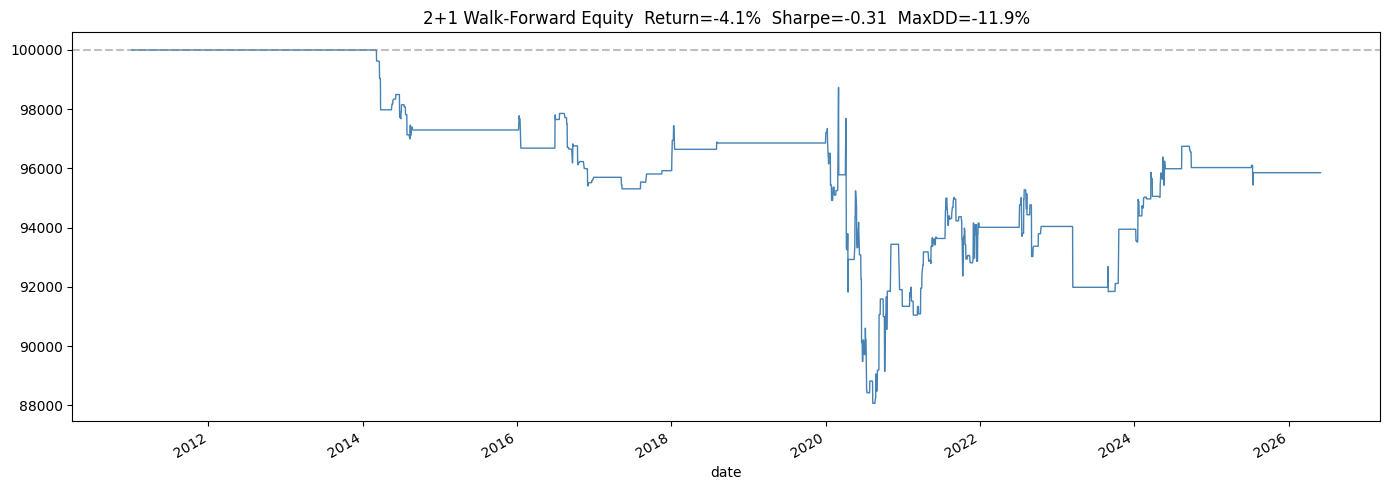

In [ ]:
#51 ── 2+1 Walk-Forward Бэктест ──────────────────────────────
from sklearn.preprocessing import RobustScaler
from sklearn.mixture import GaussianMixture

TRAIN_YEARS = 2
TEST_YEARS  = 1

wf_bt = es_days_bt.dropna(subset=GMM_FEATURES + ['direction', 'open_location',
                                                    'open_px', 'close_px']).copy()
wf_bt['direction_correct'] = (
    ((wf_bt['direction'] == 'long')  & (wf_bt['close_px'] > wf_bt['open_px'])) |
    ((wf_bt['direction'] == 'short') & (wf_bt['close_px'] < wf_bt['open_px']))
)

start_year = wf_bt.index.year.min() + TRAIN_YEARS
end_year   = wf_bt.index.year.max()

windows_results = []
all_trades      = []

year = start_year
while year <= end_year:
    train_start = pd.Timestamp(f'{year - TRAIN_YEARS}-01-01')
    train_end   = pd.Timestamp(f'{year}-01-01')
    test_start  = pd.Timestamp(f'{year}-01-01')
    test_end    = pd.Timestamp(f'{year + TEST_YEARS}-01-01')

    train = wf_bt[(wf_bt.index >= train_start) & (wf_bt.index < train_end)]
    test  = wf_bt[(wf_bt.index >= test_start)  & (wf_bt.index < test_end)]

    if len(train) < 200 or len(test) < 30:
        year += TEST_YEARS
        continue

    # Обучаем GMM на train
    scaler_wf = RobustScaler()
    X_train   = scaler_wf.fit_transform(train[GMM_FEATURES])
    X_test    = scaler_wf.transform(test[GMM_FEATURES])

    gmm_wf = GaussianMixture(n_components=13, covariance_type='full',
                              random_state=42, n_init=5, reg_covar=1e-6)
    gmm_wf.fit(X_train)

    test = test.copy()
    test['gmm_wf']    = gmm_wf.predict(X_test)
    test['conf_wf']   = gmm_wf.predict_proba(X_test).max(axis=1)

    high_conf_wf = test['conf_wf'] >= CONFIDENCE_THRESHOLD

    # Лонг сигналы
    long_mask = pd.Series(False, index=test.index)
    for loc, cluster in SIGNALS['long']:
        long_mask |= (test['open_location'] == loc) & \
                     (test['gmm_wf'] == cluster) & high_conf_wf

    # Шорт антисигналы
    short_mask = pd.Series(False, index=test.index)
    for loc, cluster in SIGNALS['short']:
        short_mask |= (test['open_location'] == loc) & \
                      (test['gmm_wf'] == cluster) & high_conf_wf

    long_trades_wf  = test[long_mask].copy()
    short_trades_wf = test[short_mask].copy()

    long_trades_wf['pnl_pct']  = (long_trades_wf['close_px'] - long_trades_wf['open_px']) / long_trades_wf['open_px']
    short_trades_wf['pnl_pct'] = (short_trades_wf['open_px'] - short_trades_wf['close_px']) / short_trades_wf['open_px']
    long_trades_wf['side']  = 'long'
    short_trades_wf['side'] = 'short'

    all_trades.append(long_trades_wf)
    all_trades.append(short_trades_wf)

    # Метрики окна
    l_wr  = (long_trades_wf['close_px'] > long_trades_wf['open_px']).mean() * 100 if len(long_trades_wf) > 0 else 0
    s_wr  = (short_trades_wf['close_px'] < short_trades_wf['open_px']).mean() * 100 if len(short_trades_wf) > 0 else 0
    l_ret = long_trades_wf['pnl_pct'].sum() * 100
    s_ret = short_trades_wf['pnl_pct'].sum() * 100

    windows_results.append({
        'period':    f'{year}-{year+TEST_YEARS}',
        'n_train':   len(train),
        'n_test':    len(test),
        'long_n':    len(long_trades_wf),
        'short_n':   len(short_trades_wf),
        'long_wr':   round(l_wr, 1),
        'short_wr':  round(s_wr, 1),
        'long_ret':  round(l_ret, 2),
        'short_ret': round(s_ret, 2),
    })

    year += TEST_YEARS

wf_windows = pd.DataFrame(windows_results)
log.info('2+1 Walk-Forward результаты:\n%s', wf_windows.to_string())

# ── Агрегированные метрики ────────────────────────────────
all_trades_df = pd.concat(all_trades).sort_index()

long_all  = all_trades_df[all_trades_df['side'] == 'long']
short_all = all_trades_df[all_trades_df['side'] == 'short']

cum = (1 + all_trades_df['pnl_pct'].reindex(
    wf_bt.index, fill_value=0)).cumprod() * 100_000

total = (cum.iloc[-1] / 100_000 - 1) * 100
act   = all_trades_df['pnl_pct']
sh    = act.mean() / act.std() * np.sqrt(252) if act.std() > 0 else 0
dd    = ((cum / cum.cummax()) - 1).min() * 100

log.info('=== ИТОГО 2+1 ===')
log.info('Лонг:  WR=%.1f%%  n=%d  avg=%.3f%%',
         (long_all['close_px'] > long_all['open_px']).mean()*100,
         len(long_all), long_all['pnl_pct'].mean()*100)
log.info('Шорт:  WR=%.1f%%  n=%d  avg=%.3f%%',
         (short_all['close_px'] < short_all['open_px']).mean()*100,
         len(short_all), short_all['pnl_pct'].mean()*100)
log.info('Total Return: %.2f%%  Sharpe: %.2f  MaxDD: %.2f%%', total, sh, dd)

# График
fig, ax = plt.subplots(figsize=(14, 5))
cum.plot(ax=ax, color='steelblue', linewidth=1)
ax.axhline(100_000, color='gray', linestyle='--', alpha=0.5)
ax.set_title(f'2+1 Walk-Forward Equity  Return={total:+.1f}%  Sharpe={sh:.2f}  MaxDD={dd:.1f}%')
plt.tight_layout()
plt.savefig('/tmp/wf_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

15:37:40  INFO      Фиксированная модель обучена на 2212 днях
15:37:40  INFO      2+1 Fixed Model:
       period  long_n  short_n  long_wr  short_wr  long_ret  short_ret
0   2013-2014      32       11     46.9      63.6     -3.08       2.55
1   2014-2015      36       12     55.6      25.0      2.94      -1.25
2   2015-2016      24       18     66.7      50.0      5.72      -0.96
3   2016-2017      24       18     54.2      38.9      1.22      -2.01
4   2017-2018      12       10     50.0      60.0      1.64      -0.35
5   2018-2019      32       11     62.5      18.2      3.95      -2.73
6   2019-2020      37        2     54.1      50.0      0.11       0.46
7   2020-2021      21        9     71.4      33.3      2.68      -3.18
8   2021-2022      22       12     86.4      41.7      3.43       0.80
9   2022-2023      19        5     94.7      40.0      6.33       0.85
10  2023-2024      27       12     55.6      16.7      4.05      -2.58
11  2024-2025      33       19     45.5      21.1

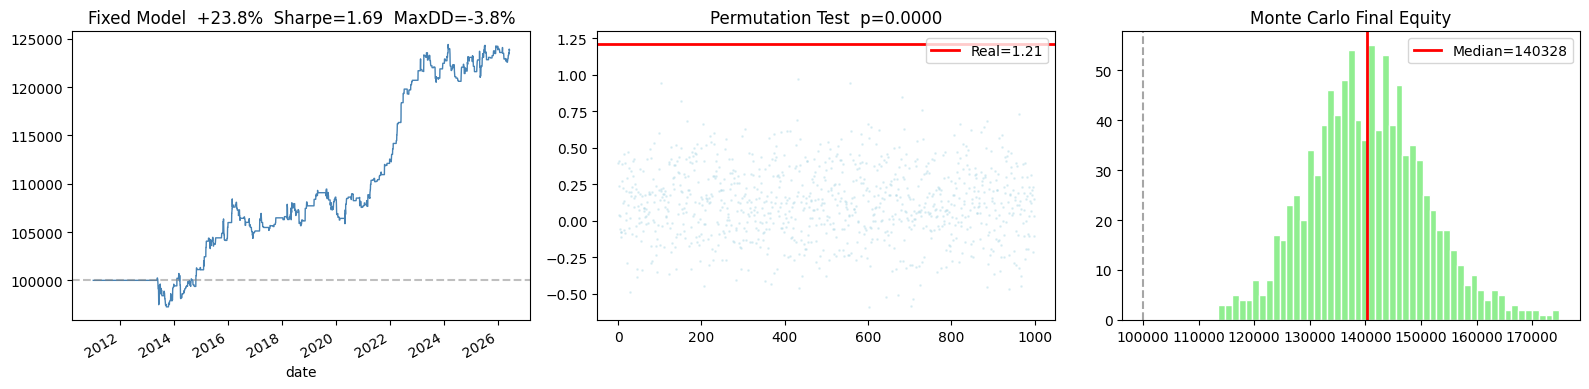

15:37:40  INFO      Bootstrap WR:     61.2% [56.3% — 66.1%]
15:37:40  INFO      Bootstrap Return: 34.50% [18.91% — 46.87%]
15:37:40  INFO      Bootstrap Sharpe: 4.02 [2.21 — 5.63]
15:37:40  INFO      P(WR > 50%): 100.0%
15:37:40  INFO      P(Return > 0%): 100.0%
15:37:40  INFO      Permutation WR: real=61.2%  random median=54.9%  p-value=0.0040


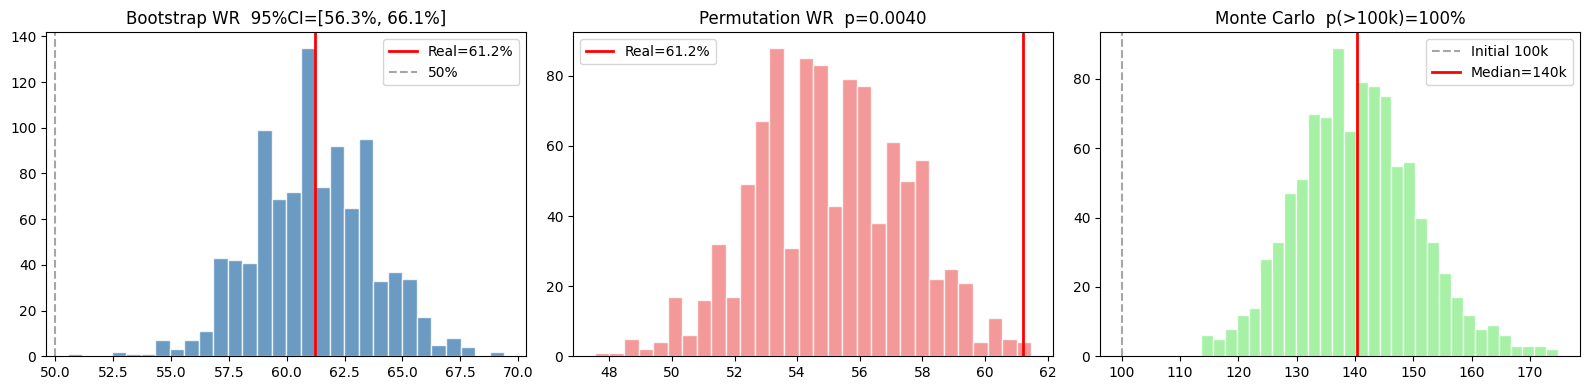

In [ ]:
#52 ── 2+1 Walk-Forward с фиксированной моделью ─────────────
from sklearn.preprocessing import RobustScaler
from sklearn.mixture import GaussianMixture

TRAIN_END_FIXED = '2020-01-01'
N_PERMS = 1000                              # перестановки (восстановлено)

# Обучаем модель один раз на 2010-2020
train_fixed = wf_bt[wf_bt.index < TRAIN_END_FIXED]
scaler_fixed = RobustScaler()
X_train_fixed = scaler_fixed.fit_transform(train_fixed[GMM_FEATURES])

gmm_fixed = GaussianMixture(n_components=13, covariance_type='full',
                             random_state=42, n_init=10, reg_covar=1e-6)
gmm_fixed.fit(X_train_fixed)
log.info('Фиксированная модель обучена на %d днях', len(train_fixed))

# Применяем фиксированную модель ко всем данным
X_all = scaler_fixed.transform(wf_bt[GMM_FEATURES])
wf_bt['gmm_fixed'] = gmm_fixed.predict(X_all)
wf_bt['conf_fixed'] = gmm_fixed.predict_proba(X_all).max(axis=1)

# 2+1 окна с фиксированной моделью
windows_fixed = []
all_trades_fixed = []

year = wf_bt.index.year.min() + TRAIN_YEARS
while year <= wf_bt.index.year.max():
    test_start = pd.Timestamp(f'{year}-01-01')
    test_end   = pd.Timestamp(f'{year + TEST_YEARS}-01-01')
    test = wf_bt[(wf_bt.index >= test_start) & (wf_bt.index < test_end)].copy()

    if len(test) < 30:
        year += TEST_YEARS
        continue

    high_conf_f = test['conf_fixed'] >= CONFIDENCE_THRESHOLD

    long_mask = pd.Series(False, index=test.index)
    short_mask = pd.Series(False, index=test.index)

    for loc, cluster in SIGNALS['long']:
        long_mask  |= (test['open_location'] == loc) & (test['gmm_fixed'] == cluster) & high_conf_f
    for loc, cluster in SIGNALS['short']:
        short_mask |= (test['open_location'] == loc) & (test['gmm_fixed'] == cluster) & high_conf_f

    lt = test[long_mask].copy()
    st = test[short_mask].copy()

    lt['pnl_pct'] = (lt['close_px'] - lt['open_px']) / lt['open_px']
    st['pnl_pct'] = (st['open_px'] - st['close_px']) / st['open_px']
    lt['side'] = 'long'
    st['side'] = 'short'

    all_trades_fixed.extend([lt, st])

    l_wr = (lt['close_px'] > lt['open_px']).mean() * 100 if len(lt) > 0 else 0
    s_wr = (st['close_px'] < st['open_px']).mean() * 100 if len(st) > 0 else 0

    windows_fixed.append({
        'period':   f'{year}-{year+TEST_YEARS}',
        'long_n':   len(lt), 'short_n': len(st),
        'long_wr':  round(l_wr, 1), 'short_wr': round(s_wr, 1),
        'long_ret': round(lt['pnl_pct'].sum()*100, 2),
        'short_ret':round(st['pnl_pct'].sum()*100, 2),
    })
    year += TEST_YEARS

wf_fixed_df = pd.DataFrame(windows_fixed)
log.info('2+1 Fixed Model:\n%s', wf_fixed_df.to_string())

trades_fixed = pd.concat(all_trades_fixed).sort_index()
long_f  = trades_fixed[trades_fixed['side'] == 'long']
real_rets = long_f['pnl_pct'].values       # для Monte Carlo (восстановлено)
short_f = trades_fixed[trades_fixed['side'] == 'short']

ret_series = trades_fixed['pnl_pct'].reindex(wf_bt.index, fill_value=0)
cum_f = (1 + ret_series).cumprod() * 100_000
tot_f = (cum_f.iloc[-1] / 100_000 - 1) * 100
sh_f  = ret_series[ret_series != 0].mean() / ret_series[ret_series != 0].std() * np.sqrt(252)
dd_f  = ((cum_f / cum_f.cummax()) - 1).min() * 100

log.info('=== FIXED MODEL ===')
log.info('Лонг: WR=%.1f%%  n=%d', (long_f['close_px']>long_f['open_px']).mean()*100, len(long_f))
log.info('Шорт: WR=%.1f%%  n=%d', (short_f['close_px']<short_f['open_px']).mean()*100, len(short_f))
log.info('Total: %.2f%%  Sharpe: %.2f  MaxDD: %.2f%%', tot_f, sh_f, dd_f)

# Permutation: тот же n дней, выбранных СЛУЧАЙНО из всех торговых дней (корректный null).
# (старый тест переставлял саму серию — Sharpe инвариантен к порядку, тест был пустым)
N_YEARS_FIXED = (wf_bt.index.max() - wf_bt.index.min()).days / 365.25
all_daily_u  = ((wf_bt['close_px'] - wf_bt['open_px']) / wf_bt['open_px']).values
real_long    = long_f['pnl_pct'].values
ANN_FIXED    = np.sqrt(len(real_long) / N_YEARS_FIXED)   # аннуализация по числу сделок/год
real_sharpe  = real_long.mean() / real_long.std() * ANN_FIXED

perm_sharpes = []
for _ in range(N_PERMS):
    samp = all_daily_u[np.random.choice(len(all_daily_u), size=len(real_long), replace=False)]
    perm_sharpes.append(samp.mean() / samp.std() * ANN_FIXED)
perm_sharpes = np.array(perm_sharpes)
p_value = (perm_sharpes >= real_sharpe).mean()

log.info('Permutation Sharpe (случайные дни): real=%.3f  p=%.4f  (%d/%d случайных лучше)',
         real_sharpe, p_value, int((perm_sharpes >= real_sharpe).sum()), N_PERMS)

# ── Monte Carlo ───────────────────────────────────────────
N_SIM = 1000
mc_finals = []

for _ in range(N_SIM):
    sampled = np.random.choice(real_rets, size=len(real_rets), replace=True)
    mc_finals.append((1 + sampled).prod() * 100_000)

mc_finals = np.array(mc_finals)
log.info('Monte Carlo (n=%d): median=%.0f  p5=%.0f  p95=%.0f  p(>100k)=%.1f%%',
         N_SIM,
         np.median(mc_finals),
         np.percentile(mc_finals, 5),
         np.percentile(mc_finals, 95),
         (mc_finals > 100_000).mean() * 100)

# Графики
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Equity curve
cum_f.plot(ax=axes[0], color='steelblue', linewidth=1)
axes[0].axhline(100_000, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title(f'Fixed Model  {tot_f:+.1f}%  Sharpe={sh_f:.2f}  MaxDD={dd_f:.1f}%')

# Permutation distribution
axes[1].scatter(range(len(perm_sharpes)), perm_sharpes, 
                s=1, alpha=0.3, color='lightblue')
axes[1].axhline(real_sharpe, color='red', linewidth=2, label=f'Real={real_sharpe:.2f}')
axes[1].set_title(f'Permutation Test  p={p_value:.4f}')
axes[1].legend()

# Monte Carlo distribution
axes[2].hist(mc_finals, bins=50, color='lightgreen', edgecolor='white')
axes[2].axvline(100_000, color='gray', linestyle='--', alpha=0.7)
axes[2].axvline(np.median(mc_finals), color='red', linewidth=2,
                label=f'Median={np.median(mc_finals):.0f}')
axes[2].set_title('Monte Carlo Final Equity')
axes[2].legend()

plt.tight_layout()
plt.savefig('/tmp/wf_fixed_stats.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Bootstrap Resampling ──────────────────────────────────
N_BOOT = 1000

# Bootstrap на лонг trades
boot_wrs    = []
boot_rets   = []
boot_sharpes = []

for _ in range(N_BOOT):
    sample = np.random.choice(long_f['pnl_pct'].values,
                               size=len(long_f), replace=True)
    boot_wrs.append((sample > 0).mean() * 100)
    boot_rets.append(sample.sum() * 100)
    boot_sharpes.append(sample.mean() / sample.std() * np.sqrt(252)
                        if sample.std() > 0 else 0)

boot_wrs     = np.array(boot_wrs)
boot_rets    = np.array(boot_rets)
boot_sharpes = np.array(boot_sharpes)

log.info('Bootstrap WR:     %.1f%% [%.1f%% — %.1f%%]',
         np.median(boot_wrs),
         np.percentile(boot_wrs, 2.5),
         np.percentile(boot_wrs, 97.5))
log.info('Bootstrap Return: %.2f%% [%.2f%% — %.2f%%]',
         np.median(boot_rets),
         np.percentile(boot_rets, 2.5),
         np.percentile(boot_rets, 97.5))
log.info('Bootstrap Sharpe: %.2f [%.2f — %.2f]',
         np.median(boot_sharpes),
         np.percentile(boot_sharpes, 2.5),
         np.percentile(boot_sharpes, 97.5))
log.info('P(WR > 50%%): %.1f%%', (boot_wrs > 50).mean() * 100)
log.info('P(Return > 0%%): %.1f%%', (boot_rets > 0).mean() * 100)

# ── Правильный Permutation Test ───────────────────────────
# Случайно выбираем те же n дней из всего test периода
all_test_rets = wf_bt[wf_bt.index >= '2013-01-01']['pnl_pct_raw'] \
    if 'pnl_pct_raw' in wf_bt.columns else None

# Считаем raw returns всех торговых дней
wf_bt['raw_ret'] = (wf_bt['close_px'] - wf_bt['open_px']) / wf_bt['open_px']
all_daily = wf_bt['raw_ret'].values
n_trades  = len(long_f)

perm_wrs = []
for _ in range(N_BOOT):
    rand_idx = np.random.choice(len(all_daily), size=n_trades, replace=False)
    rand_sample = all_daily[rand_idx]
    perm_wrs.append((rand_sample > 0).mean() * 100)

perm_wrs = np.array(perm_wrs)
real_wr  = (long_f['close_px'] > long_f['open_px']).mean() * 100
p_val_wr = (perm_wrs >= real_wr).mean()

log.info('Permutation WR: real=%.1f%%  random median=%.1f%%  p-value=%.4f',
         real_wr, np.median(perm_wrs), p_val_wr)

# Графики
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(boot_wrs, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(real_wr, color='red', linewidth=2, label=f'Real={real_wr:.1f}%')
axes[0].axvline(50, color='gray', linestyle='--', alpha=0.7, label='50%')
axes[0].set_title(f'Bootstrap WR  95%CI=[{np.percentile(boot_wrs,2.5):.1f}%, {np.percentile(boot_wrs,97.5):.1f}%]')
axes[0].legend()

axes[1].hist(perm_wrs, bins=30, color='lightcoral', edgecolor='white', alpha=0.8)
axes[1].axvline(real_wr, color='red', linewidth=2, label=f'Real={real_wr:.1f}%')
axes[1].set_title(f'Permutation WR  p={p_val_wr:.4f}')
axes[1].legend()

axes[2].hist(mc_finals / 1000, bins=30, color='lightgreen', edgecolor='white', alpha=0.8)
axes[2].axvline(100, color='gray', linestyle='--', alpha=0.7, label='Initial 100k')
axes[2].axvline(np.median(mc_finals)/1000, color='red', linewidth=2,
                label=f'Median={np.median(mc_finals)/1000:.0f}k')
axes[2].set_title(f'Monte Carlo  p(>100k)=100%')
axes[2].legend()

plt.tight_layout()
plt.savefig('/tmp/bootstrap_perm_mc.png', dpi=150, bbox_inches='tight')
plt.show()

15:37:42  INFO      Объективный 2+1 бэктест:
       period   n  our_wr  our_ret  random_wr  bh_wr  bh_ret  dir_wr  edge
0   2013-2014  32    46.9    -3.08       57.6   57.5   11.61    54.4 -10.8
1   2014-2015  36    55.6     2.94       56.8   56.2    5.46    44.2  -1.3
2   2015-2016  24    66.7     5.72       50.4   51.6    3.13    61.4  16.3
3   2016-2017  24    54.2     1.22       56.0   55.7   15.09    50.0  -1.8
4   2017-2018  12    50.0     1.64       59.2   59.9   10.95    56.4  -9.2
5   2018-2019  32    62.5     3.95       52.7   52.8  -11.40    54.7   9.8
6   2019-2020  37    54.1     0.11       55.8   55.6   12.28    60.0  -1.8
7   2020-2021  21    71.4     2.68       56.3   55.6   -3.56    58.0  15.1
8   2021-2022  22    86.4     3.43       57.7   57.1    4.94    63.2  28.7
9   2022-2023  19    94.7     6.33       53.3   53.5   -2.76    64.5  41.4
10  2023-2024  27    55.6     4.05       56.6   56.8   19.85    54.5  -1.0
11  2024-2025  33    45.5     1.75       53.3   52.9   

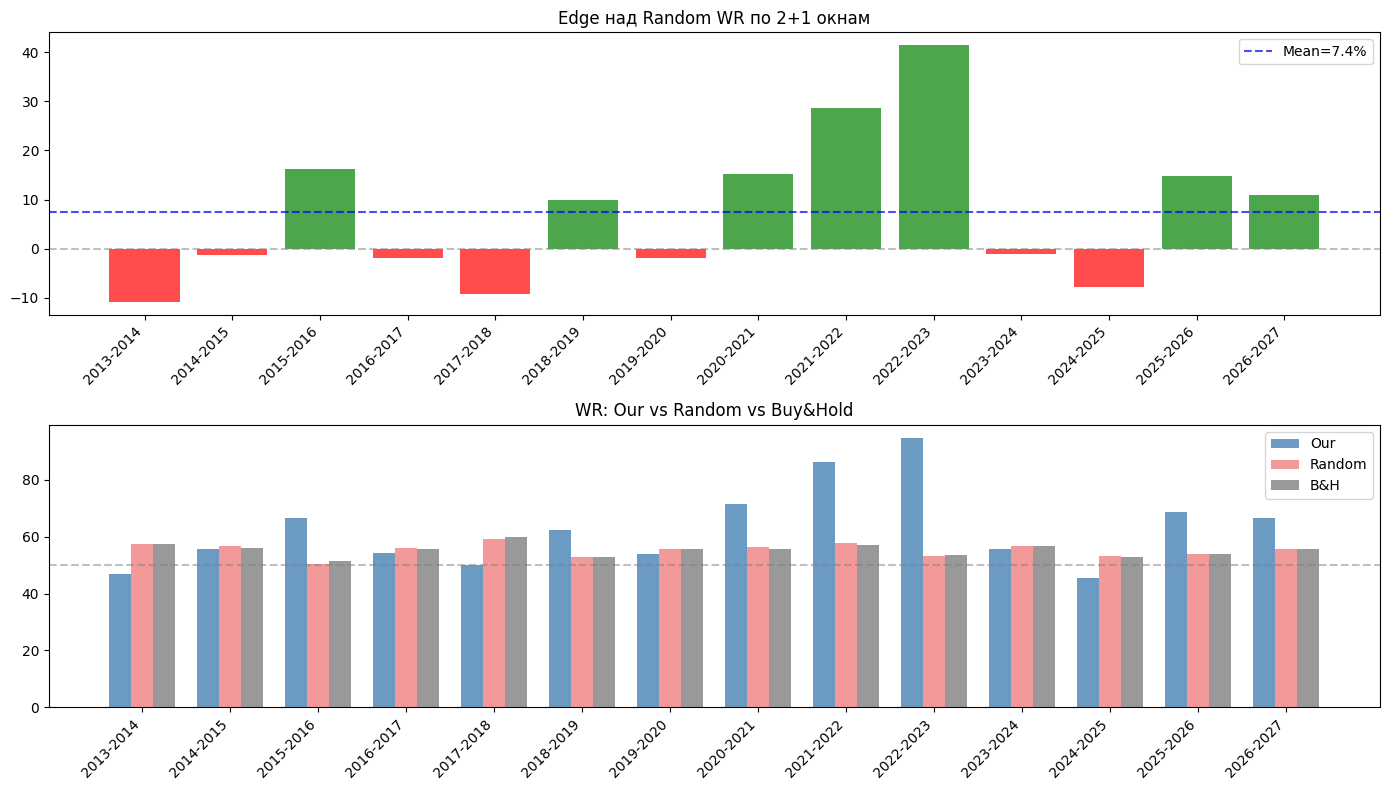

15:37:42  INFO      Объективный бэктест по периодам:
          period  our_n  our_wr  our_ret  random_wr  bh_wr  bh_ret  dir_wr  edge
0  Bear/Volatile     21    71.4     2.68       54.3   55.4   -4.13    58.0  17.1
1      Bull 2021     26    80.8     2.82       57.9   57.4    5.08    63.2  22.9
2      Bear 2022     20    95.0     6.51       53.0   53.5   -2.76    64.5  42.0
3      Bull 2023     28    57.1     4.28       56.5   56.8   19.85    54.5   0.7
4     Mixed 2024     37    48.6     2.92       53.3   53.1    3.40    50.0  -4.6
5     Mixed 2025     34    67.6     2.21       53.9   54.3    1.95    54.1  13.8
15:37:42  INFO      
Средний edge над random: 15.3%
15:37:42  INFO      Периодов с positive edge: 5/6


In [ ]:
#53 ── Объективный бэктест ───────────────────────────────────
# Сравниваем нашу стратегию с:
# 1. Random entry - случайный выбор тех же n дней
# 2. Buy every day - всегда в рынке
# 3. Direction-only - торгуем direction без кластера

periods = [
    ('Bear/Volatile',  '2020-01-01', '2020-12-31'),
    ('Bull 2021',      '2021-01-01', '2021-12-31'),
    ('Bear 2022',      '2022-01-01', '2022-12-31'),
    ('Bull 2023',      '2023-01-01', '2023-12-31'),
    ('Mixed 2024',     '2024-01-01', '2024-12-31'),
    ('Mixed 2025',     '2025-01-01', '2025-12-31'),
]

results = []

for name, start, end in periods:
    period_df = bt_df[(bt_df.index >= start) & (bt_df.index < end)]
    if len(period_df) < 20:
        continue

    # Наша стратегия
    our_long = period_df[long_entries.reindex(period_df.index, fill_value=False)]
    our_wr   = (our_long['close_px'] > our_long['open_px']).mean() * 100 if len(our_long) > 0 else 0
    our_ret  = ((our_long['close_px'] - our_long['open_px']) / our_long['open_px']).sum() * 100

    # Random entry — случайный выбор того же числа дней
    n = len(our_long)
    rand_wrs = []
    for _ in range(500):
        rand = period_df.sample(n=max(n, 1), replace=False)
        rand_wrs.append((rand['close_px'] > rand['open_px']).mean() * 100)
    rand_wr = np.mean(rand_wrs)

    # Buy every day
    bh_wr  = (period_df['close_px'] > period_df['open_px']).mean() * 100
    bh_ret = ((period_df['close_px'] - period_df['open_px']) / period_df['open_px']).sum() * 100

    # Direction only (без кластера)
    dir_mask = period_df['open_location'].isin(
        [loc for loc, _ in SIGNALS['long']])
    dir_trades = period_df[dir_mask]
    dir_wr = (dir_trades['close_px'] > dir_trades['open_px']).mean() * 100 if len(dir_trades) > 0 else 0

    results.append({
        'period':   name,
        'our_n':    n,
        'our_wr':   round(our_wr, 1),
        'our_ret':  round(our_ret, 2),
        'random_wr':round(rand_wr, 1),
        'bh_wr':    round(bh_wr, 1),
        'bh_ret':   round(bh_ret, 2),
        'dir_wr':   round(dir_wr, 1),
        'edge':     round(our_wr - rand_wr, 1),
    })

# ── Объективный 2+1 бэктест ───────────────────────────────
obj_results = []

year = wf_bt.index.year.min() + TRAIN_YEARS
while year <= wf_bt.index.year.max():
    test_start = pd.Timestamp(f'{year}-01-01')
    test_end   = pd.Timestamp(f'{year + TEST_YEARS}-01-01')
    test = wf_bt[(wf_bt.index >= test_start) & (wf_bt.index < test_end)].copy()

    if len(test) < 20:
        year += TEST_YEARS
        continue

    high_conf_f = test['conf_fixed'] >= CONFIDENCE_THRESHOLD

    long_mask = pd.Series(False, index=test.index)
    for loc, cluster in SIGNALS['long']:
        long_mask |= (test['open_location'] == loc) & \
                     (test['gmm_fixed'] == cluster) & high_conf_f

    our_long = test[long_mask]
    n = len(our_long)

    if n == 0:
        year += TEST_YEARS
        continue

    our_wr  = (our_long['close_px'] > our_long['open_px']).mean() * 100
    our_ret = ((our_long['close_px'] - our_long['open_px']) / our_long['open_px']).sum() * 100

    # Random entry — те же n дней случайно
    rand_wrs = []
    for _ in range(500):
        rand = test.sample(n=min(n, len(test)), replace=False)
        rand_wrs.append((rand['close_px'] > rand['open_px']).mean() * 100)
    rand_wr = np.mean(rand_wrs)

    # Buy every day
    bh_wr  = (test['close_px'] > test['open_px']).mean() * 100
    bh_ret = ((test['close_px'] - test['open_px']) / test['open_px']).sum() * 100

    # Direction only без кластера
    dir_mask = test['open_location'].isin([loc for loc, _ in SIGNALS['long']])
    dir_trades = test[dir_mask]
    dir_wr = (dir_trades['close_px'] > dir_trades['open_px']).mean() * 100 \
             if len(dir_trades) > 0 else 0

    obj_results.append({
        'period':    f'{year}-{year+TEST_YEARS}',
        'n':         n,
        'our_wr':    round(our_wr, 1),
        'our_ret':   round(our_ret, 2),
        'random_wr': round(rand_wr, 1),
        'bh_wr':     round(bh_wr, 1),
        'bh_ret':    round(bh_ret, 2),
        'dir_wr':    round(dir_wr, 1),
        'edge':      round(our_wr - rand_wr, 1),
    })

    year += TEST_YEARS

obj_df = pd.DataFrame(obj_results)
log.info('Объективный 2+1 бэктест:\n%s', obj_df.to_string())
log.info('Средний edge: %.1f%%', obj_df['edge'].mean())
log.info('Positive edge: %d/%d окон', (obj_df['edge'] > 0).sum(), len(obj_df))
log.info('Edge > 10%%: %d/%d окон', (obj_df['edge'] > 10).sum(), len(obj_df))

# Визуализация
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Edge по периодам
colors = ['green' if e > 0 else 'red' for e in obj_df['edge']]
axes[0].bar(obj_df['period'], obj_df['edge'], color=colors, alpha=0.7)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(obj_df['edge'].mean(), color='blue', linestyle='--',
                alpha=0.7, label=f'Mean={obj_df["edge"].mean():.1f}%')
axes[0].set_title('Edge над Random WR по 2+1 окнам')
axes[0].set_xticklabels(obj_df['period'], rotation=45, ha='right')
axes[0].legend()

# WR сравнение
x = np.arange(len(obj_df))
w = 0.25
axes[1].bar(x - w, obj_df['our_wr'],    width=w, label='Our',    color='steelblue', alpha=0.8)
axes[1].bar(x,     obj_df['random_wr'], width=w, label='Random', color='lightcoral', alpha=0.8)
axes[1].bar(x + w, obj_df['bh_wr'],     width=w, label='B&H',    color='gray', alpha=0.8)
axes[1].axhline(50, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(obj_df['period'], rotation=45, ha='right')
axes[1].set_title('WR: Our vs Random vs Buy&Hold')
axes[1].legend()

plt.tight_layout()
plt.savefig('/tmp/objective_wf.png', dpi=150, bbox_inches='tight')
plt.show()

res_df = pd.DataFrame(results)
log.info('Объективный бэктест по периодам:\n%s', res_df.to_string())
log.info('\nСредний edge над random: %.1f%%', res_df['edge'].mean())
log.info('Периодов с positive edge: %d/%d', (res_df['edge'] > 0).sum(), len(res_df))



15:37:44  INFO      Распределение хая по слотам:
high_slot
09:30    936
10:00    379
10:30    204
11:00    208
11:30    140
12:00    136
12:30    173
13:00    179
13:30    209
14:00    225
14:30    457
15:00    285
15:30    574
15:37:44  INFO      Распределение лоя по слотам:
low_slot
09:30    1259
10:00     391
10:30     258
11:00     227
11:30     196
12:00     168
12:30     158
13:00     199
13:30     174
14:00     212
14:30     303
15:00     213
15:30     347
/var/folders/3v/smgxjmwd4sd1yrfyqrw28s940000gp/T/ipykernel_12673/102425348.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
15:37:44  INFO      Win rate по high_slot × open_location:
                          

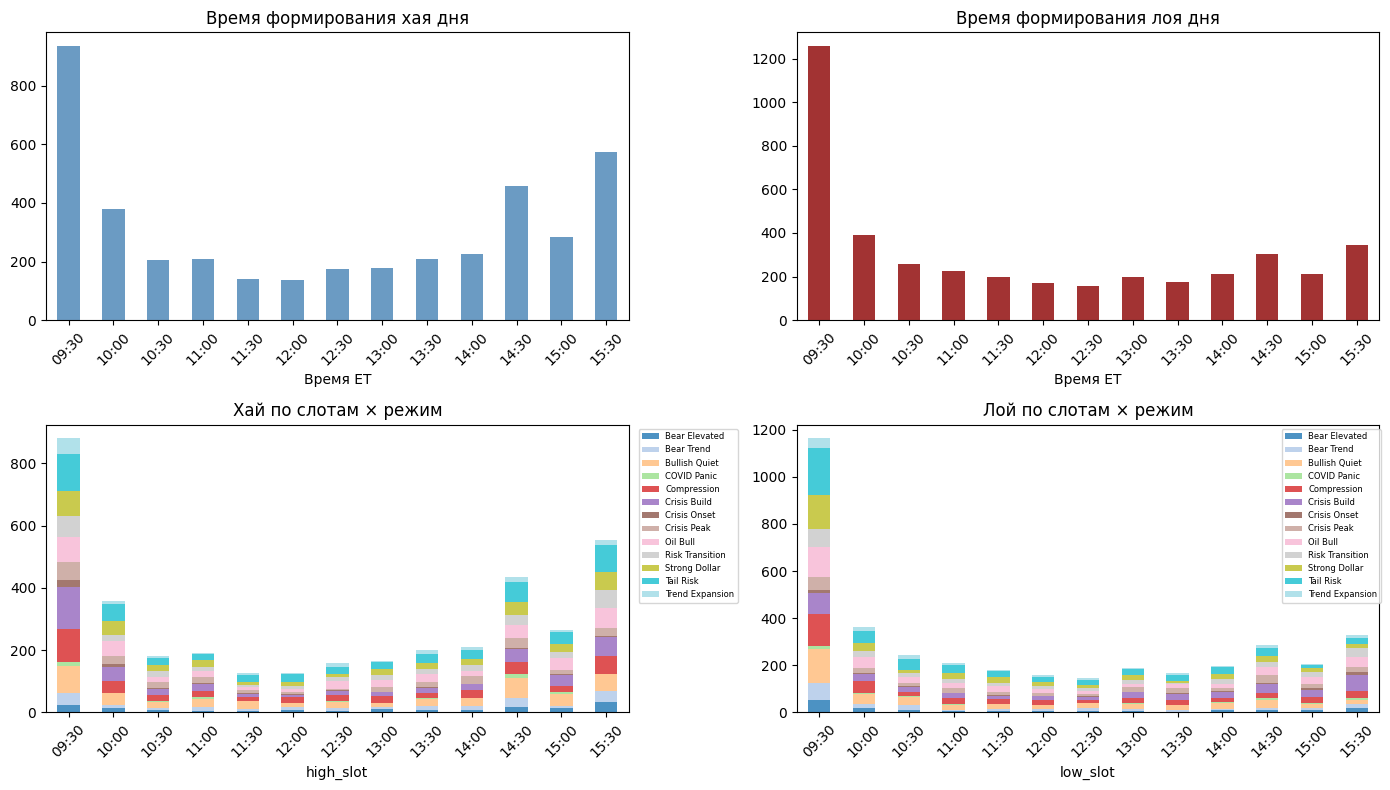

15:37:45  INFO      ES RTH index timezone: None
15:37:45  INFO      Первые timestamps: [Timestamp('2010-06-07 14:30:00'), Timestamp('2010-06-07 14:31:00'), Timestamp('2010-06-07 14:32:00'), Timestamp('2010-06-07 14:33:00'), Timestamp('2010-06-07 14:34:00')]
15:37:45  INFO      RTH диапазон часов: [14, 15, 16, 17, 18, 19, 20]
15:37:45  INFO      Средний слот формирования High по GMM кластерам:
             mean_slot  count
gmm_cluster                  
0.0                6.3    202
1.0                6.0    439
2.0                6.0    418
3.0                5.3    410
4.0                5.4    277
5.0                3.5     57
6.0                5.7    382
7.0                5.4     52
8.0                6.1    300
9.0                5.8    558
10.0               6.7    161
11.0               5.0    155
12.0               5.1    438
15:37:45  INFO      Средний слот формирования Low по GMM кластерам:
             mean_slot  count
gmm_cluster                  
0.0                3.9    

In [ ]:
#54 ── High/Low Slot анализ ──────────────────────────────────
# Делим RTH сессию на слоты по 30 минут
# RTH: 09:30 — 16:00 ET = 13 слотов по 30 минут

def get_time_slot(ts, slot_minutes=30):
    # RTH start = 14:30 UTC
    rth_start = ts.replace(hour=14, minute=30, second=0)
    delta = (ts - rth_start).total_seconds() / 60
    return int(delta // slot_minutes)

slot_labels = {
    0:  '09:30', 1:  '10:00', 2:  '10:30', 3:  '11:00',
    4:  '11:30', 5:  '12:00', 6:  '12:30', 7:  '13:00',
    8:  '13:30', 9:  '14:00', 10: '14:30', 11: '15:00',
    12: '15:30'
}

# Считаем когда формируется хай и лой каждого дня
es_rth['date'] = es_rth.index.date
es_rth['slot'] = es_rth.index.map(
    lambda ts: get_time_slot(pd.Timestamp(ts)))

# Фильтруем только RTH слоты 0-12
es_rth_clean = es_rth[(es_rth['slot'] >= 0) & (es_rth['slot'] <= 12)]

# Находим время формирования хая и лоя
daily_high = es_rth_clean.groupby('date')['high'].transform('max')
daily_low  = es_rth_clean.groupby('date')['low'].transform('min')

high_slots = es_rth_clean[es_rth_clean['high'] == daily_high].groupby('date')['slot'].first()
low_slots  = es_rth_clean[es_rth_clean['low']  == daily_low ].groupby('date')['slot'].first()

high_slots.index = pd.to_datetime(high_slots.index)
low_slots.index  = pd.to_datetime(low_slots.index)

# Добавляем в es_days
es_days['high_slot'] = high_slots.reindex(es_days.index)
es_days['low_slot']  = low_slots.reindex(es_days.index)

# Slot labels
slot_labels = {
    0:  '09:30', 1:  '10:00', 2:  '10:30', 3:  '11:00',
    4:  '11:30', 5:  '12:00', 6:  '12:30', 7:  '13:00',
    8:  '13:30', 9:  '14:00', 10: '14:30', 11: '15:00',
    12: '15:30'
}

# Распределение
high_dist = es_days['high_slot'].value_counts().sort_index()
low_dist  = es_days['low_slot'].value_counts().sort_index()

log.info('Распределение хая по слотам:\n%s',
         high_dist.rename(slot_labels).to_string())
log.info('Распределение лоя по слотам:\n%s',
         low_dist.rename(slot_labels).to_string())

# Win rate по high_slot × open_location
hl_wr = (es_days.groupby(['high_slot', 'open_location'])
         .apply(lambda x: pd.Series({
             'win_rate': (x['close_px'] > x['open_px']).mean() * 100,
             'count': len(x)
         }))
         .query('count >= 20')
         .sort_values('win_rate', ascending=False))

log.info('Win rate по high_slot × open_location:\n%s', hl_wr.head(20).to_string())

# По GMM кластерам
hl_gmm = (es_days.groupby(['high_slot', 'gmm_cluster'])
          .apply(lambda x: pd.Series({
              'win_rate': (x['close_px'] > x['open_px']).mean() * 100,
              'count': len(x)
          }))
          .query('count >= 20')
          .sort_values('win_rate', ascending=False))

log.info('Win rate по high_slot × GMM кластер:\n%s', hl_gmm.head(20).to_string())

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# High slot distribution
high_dist_labeled = high_dist.rename(slot_labels)
high_dist_labeled.plot(kind='bar', ax=axes[0,0], color='steelblue', alpha=0.8)
axes[0,0].set_title('Время формирования хая дня')
axes[0,0].set_xlabel('Время ET')
axes[0,0].tick_params(axis='x', rotation=45)

# Low slot distribution
low_dist_labeled = low_dist.rename(slot_labels)
low_dist_labeled.plot(kind='bar', ax=axes[0,1], color='darkred', alpha=0.8)
axes[0,1].set_title('Время формирования лоя дня')
axes[0,1].set_xlabel('Время ET')
axes[0,1].tick_params(axis='x', rotation=45)

# High slot по режимам
hl_regime = es_days.groupby(['high_slot', 'regime_label'])['high_slot'].count().unstack(fill_value=0)
hl_regime.rename(index=slot_labels).plot(kind='bar', stacked=True, ax=axes[1,0],
                                           colormap='tab20', alpha=0.8)
axes[1,0].set_title('Хай по слотам × режим')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(fontsize=6, bbox_to_anchor=(1.01, 1))

# Low slot по режимам
ll_regime = es_days.groupby(['low_slot', 'regime_label'])['low_slot'].count().unstack(fill_value=0)
ll_regime.rename(index=slot_labels).plot(kind='bar', stacked=True, ax=axes[1,1],
                                          colormap='tab20', alpha=0.8)
axes[1,1].set_title('Лой по слотам × режим')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend(fontsize=6, bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig('/tmp/high_low_slots.png', dpi=150, bbox_inches='tight')
plt.show()

# Проверяем timezone
log.info('ES RTH index timezone: %s', es_rth.index.tzinfo)
log.info('Первые timestamps: %s', es_rth.index[:5].tolist())
log.info('RTH диапазон часов: %s', es_rth.index.hour.unique().tolist())

#62 ── High/Low slot анализ ──────────────────────────────────
df_slots = es_days.dropna(subset=['gmm_cluster', 'high_slot', 'low_slot']).copy()

log.info('Средний слот формирования High по GMM кластерам:\n%s',
    df_slots.groupby('gmm_cluster')['high_slot']
            .agg(mean_slot=lambda x: round(x.mean(), 1), count='count')
            .to_string())

log.info('Средний слот формирования Low по GMM кластерам:\n%s',
    df_slots.groupby('gmm_cluster')['low_slot']
            .agg(mean_slot=lambda x: round(x.mean(), 1), count='count')
            .to_string())

log.info('High slot по open_location × GMM:\n%s',
    df_slots.groupby(['open_location', 'gmm_cluster'])['high_slot']
            .mean().round(1).unstack().to_string())

log.info('Low slot по open_location × GMM:\n%s',
    df_slots.groupby(['open_location', 'gmm_cluster'])['low_slot']
            .mean().round(1).unstack().to_string())

# Процент дней где high формируется в первые 2 слота (первый час после IB)
df_slots['early_high'] = df_slots['high_slot'] <= 3
df_slots['early_low']  = df_slots['low_slot']  <= 3

log.info('Early high (слот ≤3) по GMM:\n%s',
    df_slots.groupby('gmm_cluster')['early_high']
            .agg(pct=lambda x: round(x.mean()*100, 1), count='count')
            .to_string())

log.info('Early low (слот ≤3) по GMM:\n%s',
    df_slots.groupby('gmm_cluster')['early_low']
            .agg(pct=lambda x: round(x.mean()*100, 1), count='count')
            .to_string())
log.info('Early high по open_location × GMM:\n%s',
    df_slots.groupby(['open_location', 'gmm_cluster'])['early_high']
            .agg(pct=lambda x: round(x.mean()*100, 1), count='count')
            .unstack('gmm_cluster')['pct'].to_string())

log.info('Early low по open_location × GMM:\n%s',
    df_slots.groupby(['open_location', 'gmm_cluster'])['early_low']
            .agg(pct=lambda x: round(x.mean()*100, 1), count='count')
            .unstack('gmm_cluster')['pct'].to_string())

15:37:45  INFO      Long  avg total_mult: 1.06
15:37:45  INFO      Short avg total_mult: 0.73
15:37:45  INFO      === SLOT+STREAK === Return:63.70%  Sharpe:1.57  MaxDD:-5.43%
15:37:45  INFO      === STABLE      === Return:35.23%  Sharpe:1.02  MaxDD:-5.43%
15:37:45  INFO      === BASE        === Return:15.43%  Sharpe:0.95  MaxDD:-2.33%


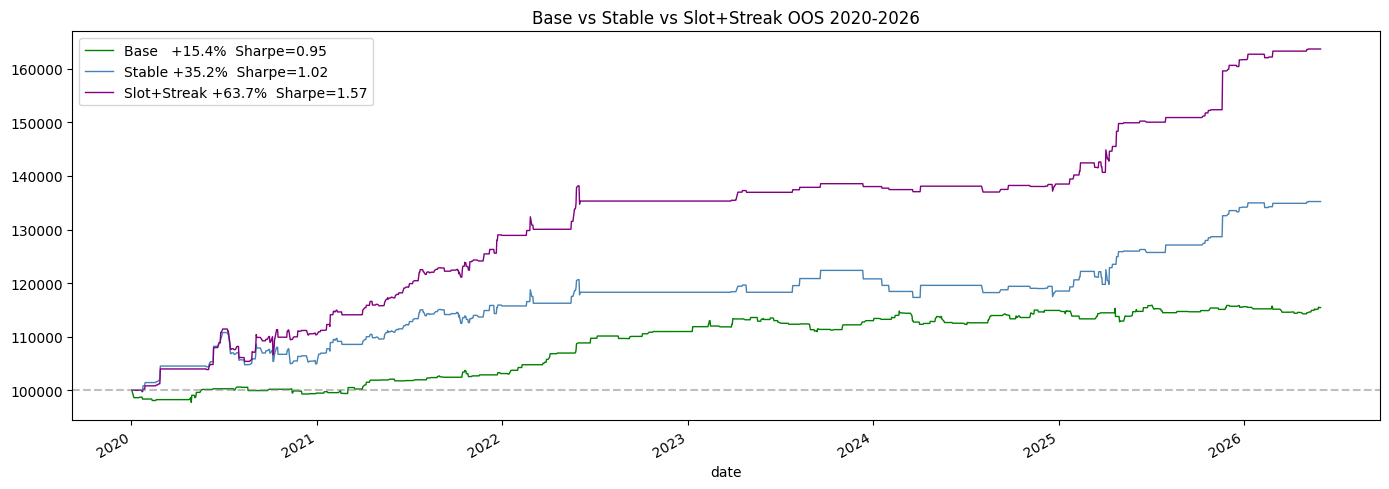

In [ ]:
#48 ── High/Low Slot мультипликатор ─────────────────────────
# Добавляем high_slot и low_slot в bt_stable
bt_stable['high_slot'] = es_days['high_slot'].reindex(bt_stable.index)
bt_stable['low_slot']  = es_days['low_slot'].reindex(bt_stable.index)

# Slot multiplier — поздний хай/лой = momentum подтверждение
def get_slot_multiplier(row, direction='long'):
    slot = row['high_slot'] if direction == 'long' else row['low_slot']
    if pd.isna(slot):
        return 1.0
    slot = int(slot)
    if direction == 'long':
        # Хай формируется поздно → momentum вверх → усиливаем лонг
        if slot >= 11:   return 1.3  # 15:00-15:30 ET
        elif slot >= 9:  return 1.1  # 14:00-14:30 ET
        elif slot <= 2:  return 0.7  # 09:30-10:30 ET — ранний хай = разворот
        else:            return 1.0
    else:
        # Лой формируется поздно → momentum вниз → усиливаем шорт
        if slot >= 11:   return 1.3
        elif slot >= 9:  return 1.1
        elif slot <= 2:  return 0.7
        else:            return 1.0

# Применяем slot multiplier поверх streak multiplier
long_t_slot  = bt_stable[long_st].copy()
short_t_slot = bt_stable[short_st].copy()

long_t_slot['pnl_base']  = (long_t_slot['close_px']  - long_t_slot['open_px'])  / long_t_slot['open_px']
short_t_slot['pnl_base'] = (short_t_slot['open_px']  - short_t_slot['close_px']) / short_t_slot['open_px']

long_t_slot['streak_mult'] = bt_stable.loc[long_t_slot.index,  'pos_multiplier']
short_t_slot['streak_mult']= bt_stable.loc[short_t_slot.index, 'pos_multiplier']

long_t_slot['slot_mult']  = long_t_slot.apply(
    lambda r: get_slot_multiplier(r, 'long'), axis=1)
short_t_slot['slot_mult'] = short_t_slot.apply(
    lambda r: get_slot_multiplier(r, 'short'), axis=1)

# Итоговый множитель = streak × slot (с cap 2.0)
long_t_slot['total_mult']  = (long_t_slot['streak_mult']  * long_t_slot['slot_mult']).clip(0, 2.0)
short_t_slot['total_mult'] = (short_t_slot['streak_mult'] * short_t_slot['slot_mult']).clip(0, 2.0)

long_t_slot['pnl']  = long_t_slot['pnl_base']  * long_t_slot['total_mult']
short_t_slot['pnl'] = short_t_slot['pnl_base'] * short_t_slot['total_mult']

log.info('Long  avg total_mult: %.2f', long_t_slot['total_mult'].mean())
log.info('Short avg total_mult: %.2f', short_t_slot['total_mult'].mean())

# Equity curve
bt_stable['strat_ret_slot'] = 0.0
bt_stable.loc[long_st,  'strat_ret_slot'] = long_t_slot['pnl']
bt_stable.loc[short_st, 'strat_ret_slot'] = short_t_slot['pnl']

cum_slot = (1 + bt_stable['strat_ret_slot']).cumprod() * 100_000
tot_slot = (cum_slot.iloc[-1] / 100_000 - 1) * 100
act_slot = bt_stable['strat_ret_slot'][bt_stable['strat_ret_slot'] != 0]
sh_slot  = bt_stable['strat_ret_slot'].mean() / bt_stable['strat_ret_slot'].std() * np.sqrt(252) if bt_stable['strat_ret_slot'].std() > 0 else 0
dd_slot  = ((cum_slot / cum_slot.cummax()) - 1).min() * 100

log.info('=== SLOT+STREAK === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%', tot_slot, sh_slot, dd_slot)
log.info('=== STABLE      === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%', tot_st,   sh_st,   dd_st)
log.info('=== BASE        === Return:%.2f%%  Sharpe:%.2f  MaxDD:%.2f%%', c_tot,    c_sh,    c_dd)

# График
fig, ax = plt.subplots(figsize=(14, 5))
cum_base.plot(ax=ax,  color='green',     linewidth=1, label=f'Base   {c_tot:+.1f}%  Sharpe={c_sh:.2f}')
cum_st_.plot(ax=ax,   color='steelblue', linewidth=1, label=f'Stable {tot_st:+.1f}%  Sharpe={sh_st:.2f}')
cum_slot.plot(ax=ax,  color='purple',    linewidth=1, label=f'Slot+Streak {tot_slot:+.1f}%  Sharpe={sh_slot:.2f}')
ax.axhline(100_000, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Base vs Stable vs Slot+Streak OOS 2020-2026')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/slot_streak_backtest.png', dpi=150, bbox_inches='tight')
plt.show()